# Lección 8.3 · Ensamblaje con SPAdes y evaluación con QUAST

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-08-ensamblaje/8.3_spades_quast.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 8 — Ensamblaje y anotación de genomas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 6.2 (control de calidad de lecturas), 6.3 (cobertura y Poisson), 7.2 (mapeo; operones *rrn* e IS de REL606), 8.1 (espectros de $k$-mers) y 8.2 (grafos de De Bruijn) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** con la fórmula de Poisson por qué ningún valor único de $k$ sirve para todo el genoma
   (ecuación de los $k$-mers ausentes) y **comprobarlo** con lecturas reales submuestreadas.
2. **Describir** las etapas de SPAdes (corrección de errores, grafo multi-$k$, simplificación, resolución de
   repeticiones con pares, *scaffolds*) y **ejecutarlo** en Colab sobre lecturas reales del clon de Lenski.
3. **Calcular desde cero** N50, L50, NG50, N90 y auN, **dibujar** curvas N$x$ y **reconocer** cómo un error de
   ensamblaje o un simple filtro de longitud inflan el N50.
4. **Estimar** el tamaño de un hueco entre dos *contigs* a partir de pares de lecturas ($\widehat g=\mu-a-b$).
5. **Evaluar la exactitud** con QUAST (errores de ensamblaje, fracción del genoma, desajustes) y **reproducir** sus
   cifras con un alineador de $k$-mers propio escrito en NumPy.
6. **Diagnosticar** por qué se rompe un ensamblaje real: operones de rRNA, elementos IS y, sorpresa, **inserciones
   nuevas** del clon que la referencia no tiene; y **elegir** la referencia correcta para QUAST.
7. **Medir** completitud y exactitud **sin referencia**: la idea de BUSCO y la QV de Merqury calculada con los
   $k$-mers de las propias lecturas.

## 🗺️ Mapa de la clase

1. El rompecabezas sin la foto de la caja: los tres ejes de un ensamblaje
2. 🧪 Los datos: 250 kb del clon de Lenski y su espectro de $k$-mers
3. Un solo $k$ no basta: $k$-mers ausentes (teoría y datos reales)
4. Cómo trabaja SPAdes
5. 🧪 SPAdes en vivo sobre lecturas reales (🔍 interactivo)
6. Lecturas largas: el regreso del solapamiento
7. Métricas de contigüidad: N50, NG50, L50, auN y curvas N$x$ (🎬 animación, 🔍 interactivo)
8. Andamiaje: ordenar *contigs* con pares de lecturas
9. Exactitud con QUAST y con nuestro propio alineador (🎬 animación)
10. 🧪 El genoma completo del clon: dónde se rompe un ensamblaje real (🔍 interactivo)
11. Completitud y exactitud sin referencia: BUSCO y Merqury
12. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, time, shutil, tarfile, tempfile, subprocess, warnings
warnings.filterwarnings("ignore", message="The figure layout has changed")
from collections import Counter, defaultdict
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, timeout=120):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia del repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    with urllib.request.urlopen(f"{RAW}/data/{name}", timeout=timeout) as r:
        return r.read()

WORK = "/content/leccion83" if IN_COLAB else tempfile.mkdtemp(prefix="leccion83_")
os.makedirs(WORK, exist_ok=True)          # aquí trabajan SPAdes y QUAST (fuera de la carpeta del curso)

def course_file(name):
    """Deja una copia local (en WORK) de un archivo del curso y devuelve su ruta, para las herramientas externas."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    dest = os.path.join(WORK, name)
    if not os.path.exists(dest):
        open(dest, "wb").write(course_bytes(name))
    return dest

def read_fasta(data):
    """FASTA (bytes, comprimido o no) → diccionario {nombre: secuencia en mayúsculas}."""
    text = gzip.decompress(data).decode() if data[:2] == b"\x1f\x8b" else data.decode()
    recs, name, buf = {}, None, []
    for line in text.splitlines():
        if line.startswith(">"):
            if name:
                recs[name] = "".join(buf)
            name, buf = line[1:].split()[0], []
        else:
            buf.append(line.strip().upper())
    if name:
        recs[name] = "".join(buf)
    return recs

# ---- k-mers en NumPy: cada base ocupa 2 bits (A=0, C=1, G=2, T=3; N=4 invalida el k-mer) ----
LUT = np.full(256, 4, np.uint8)
for i_, c_ in enumerate(b"ACGT"):
    LUT[c_] = i_
HASH_P = np.uint64(0x9E3779B97F4A7C15)       # multiplicador impar para k > 32 (no cabe en 64 bits)

def to_codes(seq):
    """Cadena de ADN → vector uint8 con 0..3 (y 4 para cualquier otra letra)."""
    return LUT[np.frombuffer(seq.encode(), np.uint8)]

def kmer_codes(A, k):
    """k-mers CANÓNICOS de una matriz (lecturas × posiciones) o de un vector (una secuencia).
    Devuelve (código, está_en_sentido_directo, válido). Con k ≤ 32 el código es exacto (2 bits por base);
    con k > 32 es un hash de 64 bits (colisiones con probabilidad ~1e-19, despreciables aquí)."""
    A = np.atleast_2d(A)
    m = A.shape[1] - k + 1
    B = np.where(A > 3, 0, A).astype(np.uint64)
    f = np.zeros((A.shape[0], m), np.uint64)
    r = np.zeros_like(f)
    with np.errstate(over="ignore"):
        if k <= 32:
            for j in range(k):
                f = (f << np.uint64(2)) | B[:, j:j + m]
                r |= (np.uint64(3) - B[:, j:j + m]) << np.uint64(2 * j)
        else:
            pw = np.uint64(1)
            for j in range(k):
                f = f * HASH_P + B[:, j:j + m] + np.uint64(1)
                r = r + (np.uint64(4) - B[:, j:j + m]) * pw
                pw = pw * HASH_P
    nbad = np.cumsum(np.pad(A > 3, ((0, 0), (1, 0))), axis=1)
    ok = (nbad[:, k:] - nbad[:, :m]) == 0
    return np.minimum(f, r), f <= r, ok

rng = np.random.default_rng(83)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 8.3 (SPAdes y QUAST trabajarán en una carpeta temporal)")

Entorno listo ✔  |  Colab: False
Listo para la Lección 8.3 (SPAdes y QUAST trabajarán en una carpeta temporal)


## 1. El rompecabezas sin la foto de la caja: los tres ejes de un ensamblaje

Cuando termina un rompecabezas de mil piezas, usted sabe si lo hizo bien porque compara el resultado con la foto de
la caja. Ahora imagine que **no hay caja**. Puede contar cuántos bloques sueltos le quedaron y medir el más grande,
pero eso no le dice si algún bloque está mal armado: dos piezas de cielo azul encajan igual de bien en muchos sitios,
y forzarlas produce un bloque grande y **falso**. Para juzgar su trabajo necesita otras pistas: que no le sobren ni le
falten piezas de los bordes, que ciertas piezas que sabe que existen (la firma del pintor, el sol) aparezcan **una
sola vez**, que los colores de cada unión sean coherentes.

Evaluar un ensamblaje es exactamente eso. En las lecciones 8.1 y 8.2 aprendimos a contar $k$-mers y a construir el
grafo de De Bruijn. Hoy usamos un ensamblador profesional, **SPAdes**, y sobre todo aprendemos a **juzgar** su
resultado en tres ejes que nunca deben mirarse por separado:

| Eje | Pregunta | Métricas de hoy |
|---|---|---|
| **Contigüidad** | ¿En cuántos trozos quedó el genoma y de qué tamaño? | N50, NG50, L50, auN, curvas N$x$ |
| **Exactitud** | ¿Los trozos son correctos, base a base y en su orden? | errores de ensamblaje (QUAST), NGA50, desajustes, QV |
| **Completitud** | ¿Está todo el genoma? ¿Algo aparece dos veces? | fracción del genoma, BUSCO, completitud por $k$-mers |

**El caso de hoy.** Seguimos con el clon de *E. coli* B del experimento de evolución a largo plazo de Lenski
(corrida **SRR2584863**), cuyas lecturas limpiamos en la Lección 6.2 y mapeamos contra el ancestro REL606
(NC_012967.1) en el Módulo 7. Ahora hacemos lo que haría un laboratorio que recibe un aislado **sin referencia**
(una bacteria de un brote hospitalario, una cepa ambiental nueva): ensamblarlo *de novo*. Tenemos una ventaja
didáctica enorme: como sí existe la referencia del ancestro, podremos **comprobar** cada afirmación.

## 2. 🧪 Los datos: 250 kb del clon de Lenski y su espectro de $k$-mers

Ensamblar las 1,55 millones de pares de lecturas del clon completo lleva unos 8 minutos con 8 núcleos: demasiado para
una clase en Colab (2 núcleos). Por eso trabajaremos en dos escalas:

* **En vivo:** una **región de 250 kb** del cromosoma (posiciones 3 950 001–4 200 000 de REL606), con **34 000 pares
  reales** de lecturas (2 × 150 pb). Las lecturas se **reclutaron** mapeando todo el experimento contra esa región con
  minimap2 y quedándose con los pares que caían en ella. Esa región contiene **tres** de los siete operones de ARN
  ribosómico (*rrn*) de *E. coli*: un buen banco de pruebas, porque son repeticiones de ~5 kb.
* **Precalculado:** el ensamblaje del **genoma completo** con todas las lecturas (SPAdes 4, `--isolate`,
  $k$ = 21, 33, 55, 77), que analizaremos en la sección 10.

Cargamos las lecturas en una matriz de NumPy (una fila por lectura, una columna por posición), la referencia de la
región y la anotación de REL606.

In [2]:
def read_fastq_seqs(data):
    """Secuencias de un FASTQ comprimido (bytes)."""
    return gzip.decompress(data).decode().split("\n")[1::4]

REG = "REL606_3950k-4200k"
r1 = read_fastq_seqs(course_bytes(f"{REG}_reads_1.fastq.gz"))
r2 = read_fastq_seqs(course_bytes(f"{REG}_reads_2.fastq.gz"))
r1 = [s for s in r1 if s]; r2 = [s for s in r2 if s]
L = len(r1[0])
assert all(len(s) == L for s in r1 + r2), "Todas las lecturas miden lo mismo (150 nt)"
R = to_codes("".join(r1 + r2)).reshape(-1, L)       # filas 0..n-1: lectura 1; filas n..2n-1: su compañera
n_pairs = len(r1)

region = next(iter(read_fasta(course_bytes(f"{REG}.fasta.gz")).values()))
REG_START = 3_950_001                                 # coordenada de REL606 de la primera base de la región
G_reg = len(region)
feat = pd.read_csv(io.BytesIO(course_bytes("NC_012967.1_features.tsv.gz")), sep="\t", comment="#",
                   compression="gzip")
feat["product"] = feat["product"].fillna("")

c_bases = 2 * n_pairs * L / G_reg
print(f"Pares: {n_pairs:,} · longitud {L} nt · bases: {2 * n_pairs * L / 1e6:.1f} Mb")
print(f"Región: {G_reg:,} pb · cobertura nominal c = N·L/G = {c_bases:.1f}×")
print(f"Bases N en las lecturas: {(R == 4).mean():.3%}")

Pares: 34,000 · longitud 150 nt · bases: 10.2 Mb
Región: 250,000 pb · cobertura nominal c = N·L/G = 40.8×
Bases N en las lecturas: 0.071%


### El espectro de 21-mers de la región

Recordemos la Lección 8.1: si cada base del genoma está cubierta por $c$ lecturas, cada $k$-mer del genoma aparece en
promedio

$$
\lambda_k \;=\; \underbrace{c\,\frac{L-k+1}{L}}_{c_k}\,(1-e)^k
$$

veces en las lecturas (ecuación 08-ck del libro), porque de las $L$ posiciones de inicio de una lectura sólo $L-k+1$ dejan espacio para un
$k$-mer completo, y el $k$-mer sólo se cuenta si **ninguna** de sus $k$ bases tiene error (tasa $e$ por base).

| Símbolo | Significado | Valor hoy |
|---|---|---|
| $c$ | cobertura de bases | ≈ 40,8× (nominal) |
| $L$ | longitud de lectura | 150 |
| $k$ | longitud del $k$-mer | 21 |
| $e$ | tasa de error por base | ≈ 0,5 % (Illumina) |
| $c_k$ | cobertura de $k$-mers sin tener en cuenta los errores | ≈ 35,4 |
| $\lambda_k$ | cobertura efectiva de $k$-mers (el pico del espectro) | a medir |

Con los números de hoy: $c_{21} = 40{,}8 \times 130/150 = 35{,}4$ y $(1-0{,}005)^{21} = 0{,}90$, así que esperamos el
pico del espectro cerca de $\lambda_{21}\approx 31{,}8$. ¿Qué dicen los datos?

21-mers en las lecturas: 8,832,354 · distintos: 1,086,346 · vistos una sola vez: 808,993
Valle en m = 8 · pico en m = 29 (esperado ≈ 31.8)
Tasa de error implícita si el pico fuera exactamente λ_k: e ≈ 0.94%


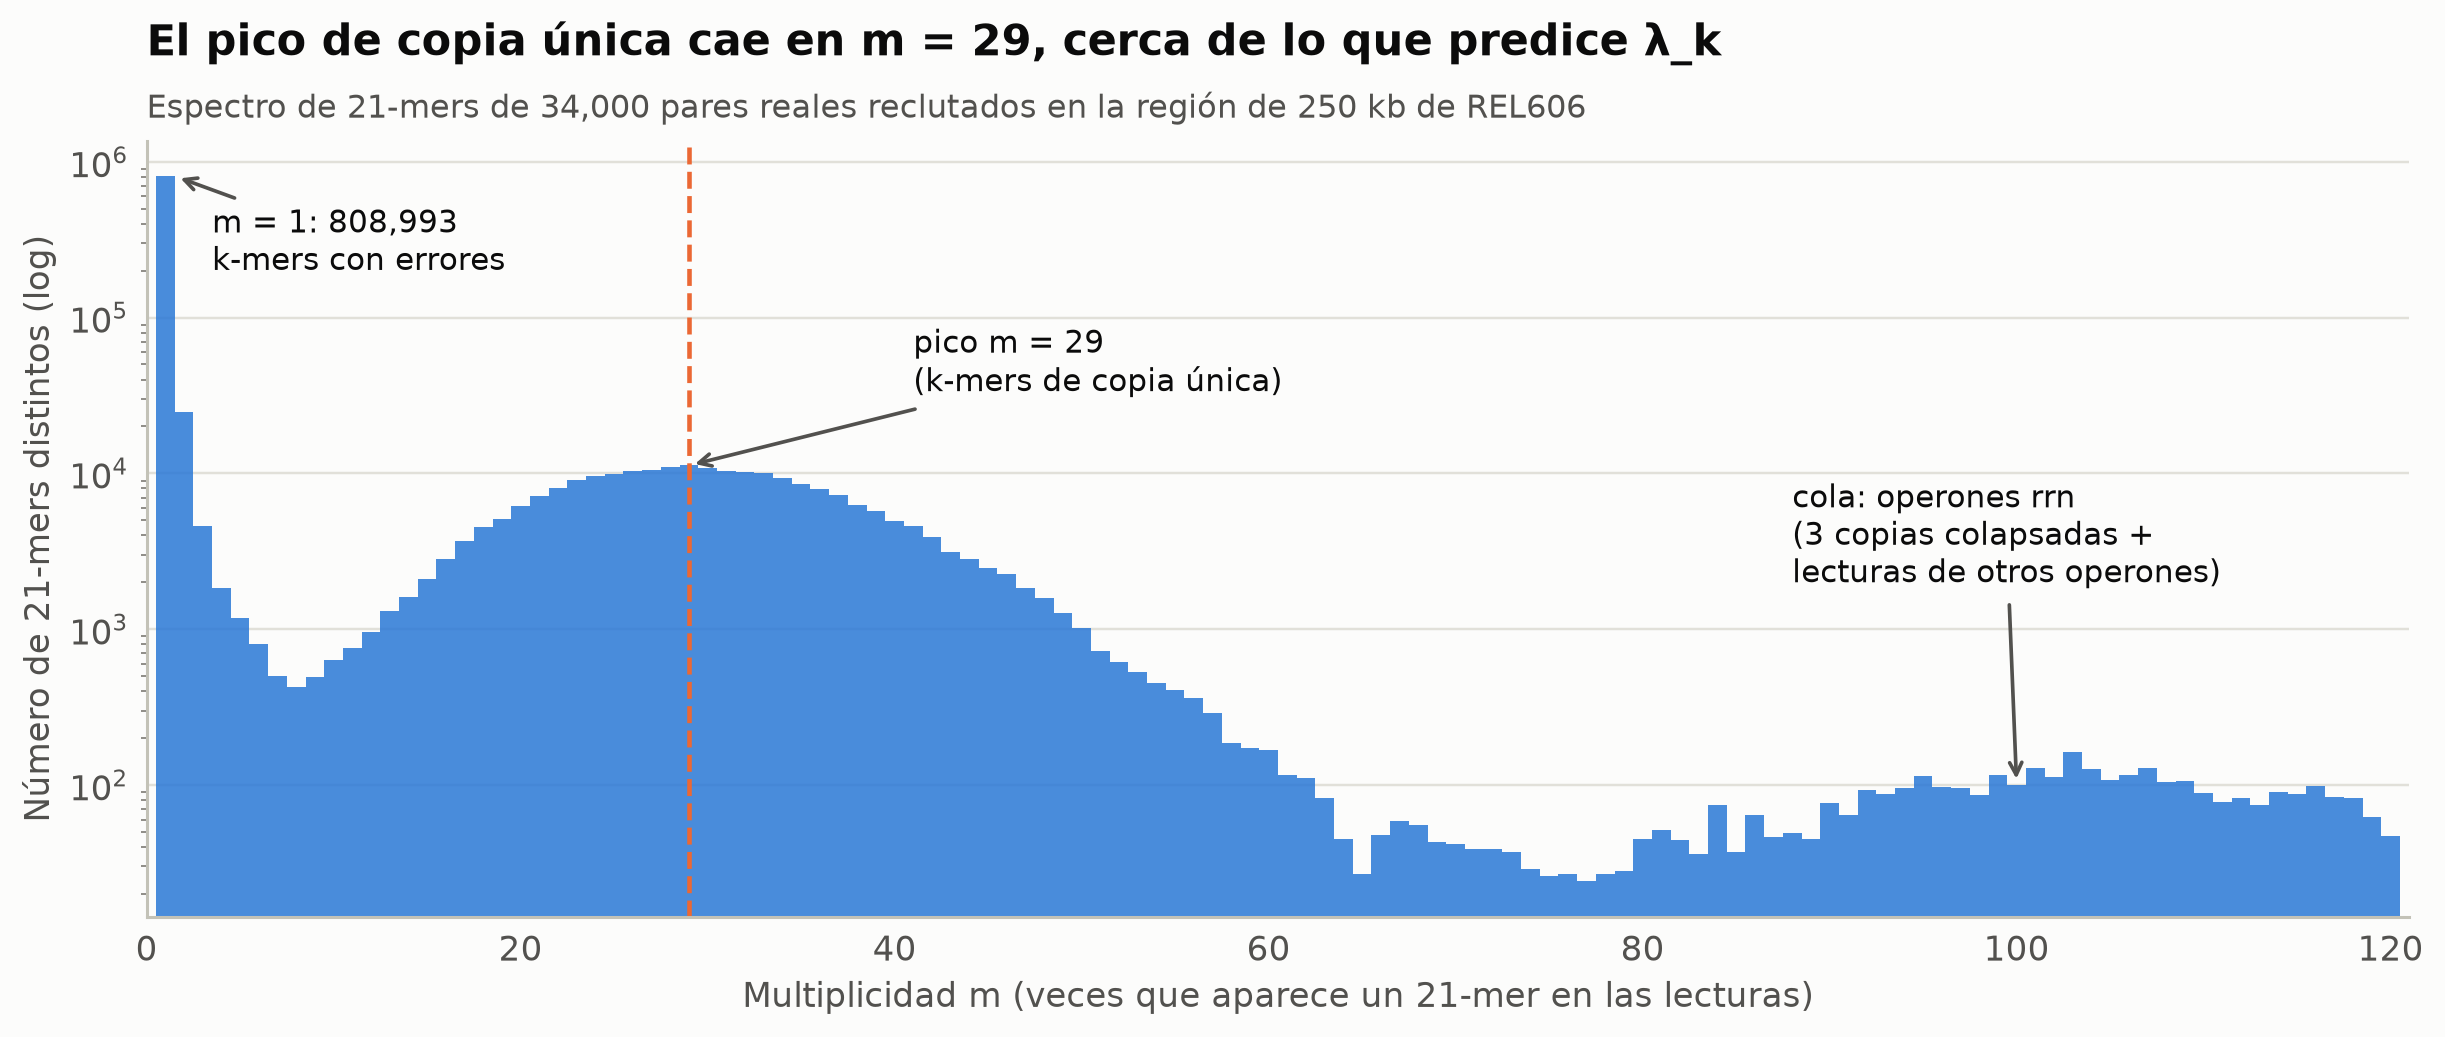

In [3]:
K_SPEC = 21
codes, fw_, ok_ = kmer_codes(R, K_SPEC)
read_kmers, read_counts = np.unique(codes[ok_], return_counts=True)   # k-mers distintos y su multiplicidad
hist = np.bincount(read_counts)
peak = int(np.argmax(hist[5:120]) + 5)
valley = int(np.argmin(hist[2:peak]) + 2)
e_hat = 1 - (peak / (c_bases * (L - K_SPEC + 1) / L)) ** (1 / K_SPEC)
print(f"21-mers en las lecturas: {ok_.sum():,} · distintos: {len(read_kmers):,} · vistos una sola vez: {hist[1]:,}")
print(f"Valle en m = {valley} · pico en m = {peak} (esperado ≈ {c_bases * (L - K_SPEC + 1) / L * 0.995 ** K_SPEC:.1f})")
print(f"Tasa de error implícita si el pico fuera exactamente λ_k: e ≈ {e_hat:.2%}")

fig, ax = plt.subplots(figsize=(11, 4.6))
m = np.arange(1, 121)
ax.bar(m, hist[1:121], width=1.0, color=ec.BLUE, alpha=0.85)
ax.set_yscale("log")
ax.axvline(peak, color=ec.ORANGE, lw=1.5, ls="--")
ax.annotate(f"pico m = {peak}\n(k-mers de copia única)", (peak, hist[peak]), xytext=(peak + 12, hist[peak] * 3),
            fontsize=10, arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
ax.annotate(f"m = 1: {hist[1]:,}\nk-mers con errores", (1.5, hist[1]), xytext=(3.5, hist[1] * 0.25), fontsize=10,
            arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
ax.annotate("cola: operones rrn\n(3 copias colapsadas +\nlecturas de otros operones)", (100, max(hist[100], 1)),
            xytext=(88, 2e3), fontsize=10, arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
ax.set_xlabel("Multiplicidad m (veces que aparece un 21-mer en las lecturas)")
ax.set_ylabel("Número de 21-mers distintos (log)")
ax.set_xlim(0, 121)
ec.title(ax, f"El pico de copia única cae en m = {peak}, cerca de lo que predice λ_k",
         f"Espectro de 21-mers de {n_pairs:,} pares reales reclutados en la región de 250 kb de REL606")
plt.show()

> 🔎 **Qué observamos.** El espectro tiene la forma que conocemos de la Lección 8.1: una montaña de $k$-mers vistos
> **una vez** (errores de secuenciación: una sola base equivocada crea hasta 21 $k$-mers nuevos), un valle, y un pico
> de copia única cerca de $m\approx 30$, un poco por debajo de la predicción ingenua ($\approx 32$). La diferencia es
> razonable: la tasa de error real al final de las lecturas es mayor que 0,5 % (Lección 6.2), y la cobertura nominal
> incluye lecturas que no pertenecen a la región de copia única (la cola de la derecha). Esa cola es una pista de lo
> que veremos en todo el día: las lecturas de los **siete** operones *rrn* del genoma se reclutaron en los **tres**
> de la región, y sus $k$-mers aparecen muchas más veces de lo normal.

## 3. Un solo $k$ no basta

### La intuición

La Lección 8.2 nos dejó un dilema. Un $k$ **grande** resuelve más repeticiones: una repetición de 40 pb deja de ser
ambigua si los nodos del grafo miden 55. Pero un $k$ grande también tiene un costo: cada lectura de 150 pb contiene
$L-k+1$ $k$-mers, que son 130 con $k=21$ pero sólo 24 con $k=127$. Menos $k$-mers por lectura significa que cada
$k$-mer del genoma se observa **menos veces**, y aumenta la probabilidad de que alguno **no se observe nunca**. Y cada
$k$-mer ausente corta el camino del grafo y parte un *contig* en dos.

Piense en una cadena de clips de papel que alguien arma con clips que saca de una caja: si cada clip es pequeño, casi
seguro encuentra el que necesita; si exige clips largos y especiales, alguno faltará y la cadena se interrumpe.

### La ecuación

Por el mismo argumento de Poisson de la Lección 6.3 (el número de lecturas que "cubren" un $k$-mer es aproximadamente
Poisson con media $\lambda_k$), la probabilidad de que un $k$-mer del genoma no aparezca en ninguna lectura es

$$
\Pr(\text{un $k$-mer del genoma no se observa}) \;=\; e^{-\lambda_k},
\qquad
\lambda_k = c\,\frac{L-k+1}{L}\,(1-e)^k .
\tag{ec. 08-ausentes}
$$

| Símbolo | Significado |
|---|---|
| $e^{-\lambda_k}$ | fracción esperada de $k$-mers del genoma que **faltan** en el grafo |
| $\lambda_k$ | cobertura efectiva de $k$-mers (la misma de la sección 2) |
| $c$ | cobertura de bases **local** (¡no la media del genoma!) |
| $L,\ k,\ e$ | longitud de lectura, longitud del $k$-mer, tasa de error por base |

### Un ejemplo a mano

Una región que por sesgo de GC (Lección 6.3) recibe sólo $c=10\times$, con lecturas de 150 pb y 0,5 % de error:

| $k$ | $\frac{L-k+1}{L}$ | $(1-e)^k$ | $\lambda_k$ | $e^{-\lambda_k}$ | $k$-mers ausentes en 5 Mb |
|---|---|---|---|---|---|
| 21 | 130/150 = 0,867 | 0,900 | 7,80 | 0,04 % | ≈ 2 000 |
| 77 | 74/150 = 0,493 | 0,680 | 3,35 | 3,5 % | ≈ 175 000 |
| 127 | 24/150 = 0,160 | 0,530 | 0,85 | 43 % | más de 2 millones |

Con $k=127$ casi la mitad del genoma de esa región desaparece del grafo. La celda reproduce la tabla y la extiende.

In [4]:
def lambda_k(c, k, L=150, e=0.005):
    """Cobertura efectiva de k-mers (ec. 08-ausentes)."""
    return c * (L - k + 1) / L * (1 - e) ** k

def frac_missing(c, k, L=150, e=0.005):
    """Fracción esperada de k-mers del genoma que no aparecen en ninguna lectura: e^{-λ_k}."""
    return np.exp(-lambda_k(c, k, L, e))

rows = []
for c in (5, 10, 30):
    for k in (21, 33, 55, 77, 127):
        p = frac_missing(c, k)
        rows.append(dict(cobertura=f"{c}×", k=k, lambda_k=round(lambda_k(c, k), 2),
                         ausentes=f"{p:.3g}", **{"en 5 Mb": f"{5e6 * p:,.0f}"}))
print(pd.DataFrame(rows).to_string(index=False))

cobertura   k  lambda_k ausentes   en 5 Mb
       5×  21      3.90   0.0202   101,171
       5×  33      3.33   0.0357   178,310
       5×  55      2.43   0.0881   440,645
       5×  77      1.68    0.187   934,833
       5× 127      0.42    0.655 3,274,497
      10×  21      7.80 0.000409     2,047
      10×  33      6.67  0.00127     6,359
      10×  55      4.86  0.00777    38,834
      10×  77      3.35    0.035   174,783
      10× 127      0.85    0.429 2,144,466
      30×  21     23.40 6.86e-11         0
      30×  33     20.00 2.06e-09         0
      30×  55     14.57 4.69e-07         2
      30×  77     10.06 4.27e-05       214
      30× 127      2.54   0.0789   394,473


> 🤔 **Antes de ejecutar, prediga.** En la celda siguiente submuestreamos las lecturas reales a ~5×, ~10× y 40× y
> contamos, para cada $k$ entre 21 y 127, qué fracción de los $k$-mers de la referencia de la región **no aparece**
> en ninguna lectura. ¿Seguirán los puntos reales a las curvas teóricas? ¿Dónde espera que se separen más?

In [5]:
ref_arr = to_codes(region)
k_grid = [21, 33, 55, 77, 99, 127]
cov_levels = {"≈5×": 5, "≈10×": 10, "40×": c_bases}
empirical = {}
t0 = time.perf_counter()
for lab, c in cov_levels.items():
    sel = np.sort(rng.choice(n_pairs, int(round(n_pairs * min(1, c / c_bases))), replace=False))
    Rs = np.vstack([R[sel], R[sel + n_pairs]])             # conservar ambos miembros de cada par
    vals = []
    for k in k_grid:
        rc_, _, rok = kmer_codes(Rs, k)
        seen = np.unique(rc_[rok])
        g_, _, gok = kmer_codes(ref_arr, k)
        g_ = g_[0][gok[0]]
        i_ = np.minimum(np.searchsorted(seen, g_), len(seen) - 1)
        vals.append(np.mean(seen[i_] != g_))
    empirical[lab] = (c, np.array(vals))
print(f"Tiempo: {time.perf_counter() - t0:.1f} s")
print(pd.DataFrame({lab: [f"{v:.4f}" for v in vals] for lab, (c, vals) in empirical.items()},
                   index=[f"k={k}" for k in k_grid]).to_string())

Tiempo: 10.6 s
          ≈5×    ≈10×     40×
k=21   0.0306  0.0021  0.0003
k=33   0.0463  0.0040  0.0005
k=55   0.0906  0.0128  0.0009
k=77   0.1647  0.0369  0.0013
k=99   0.2878  0.1018  0.0027
k=127  0.5656  0.3518  0.0381


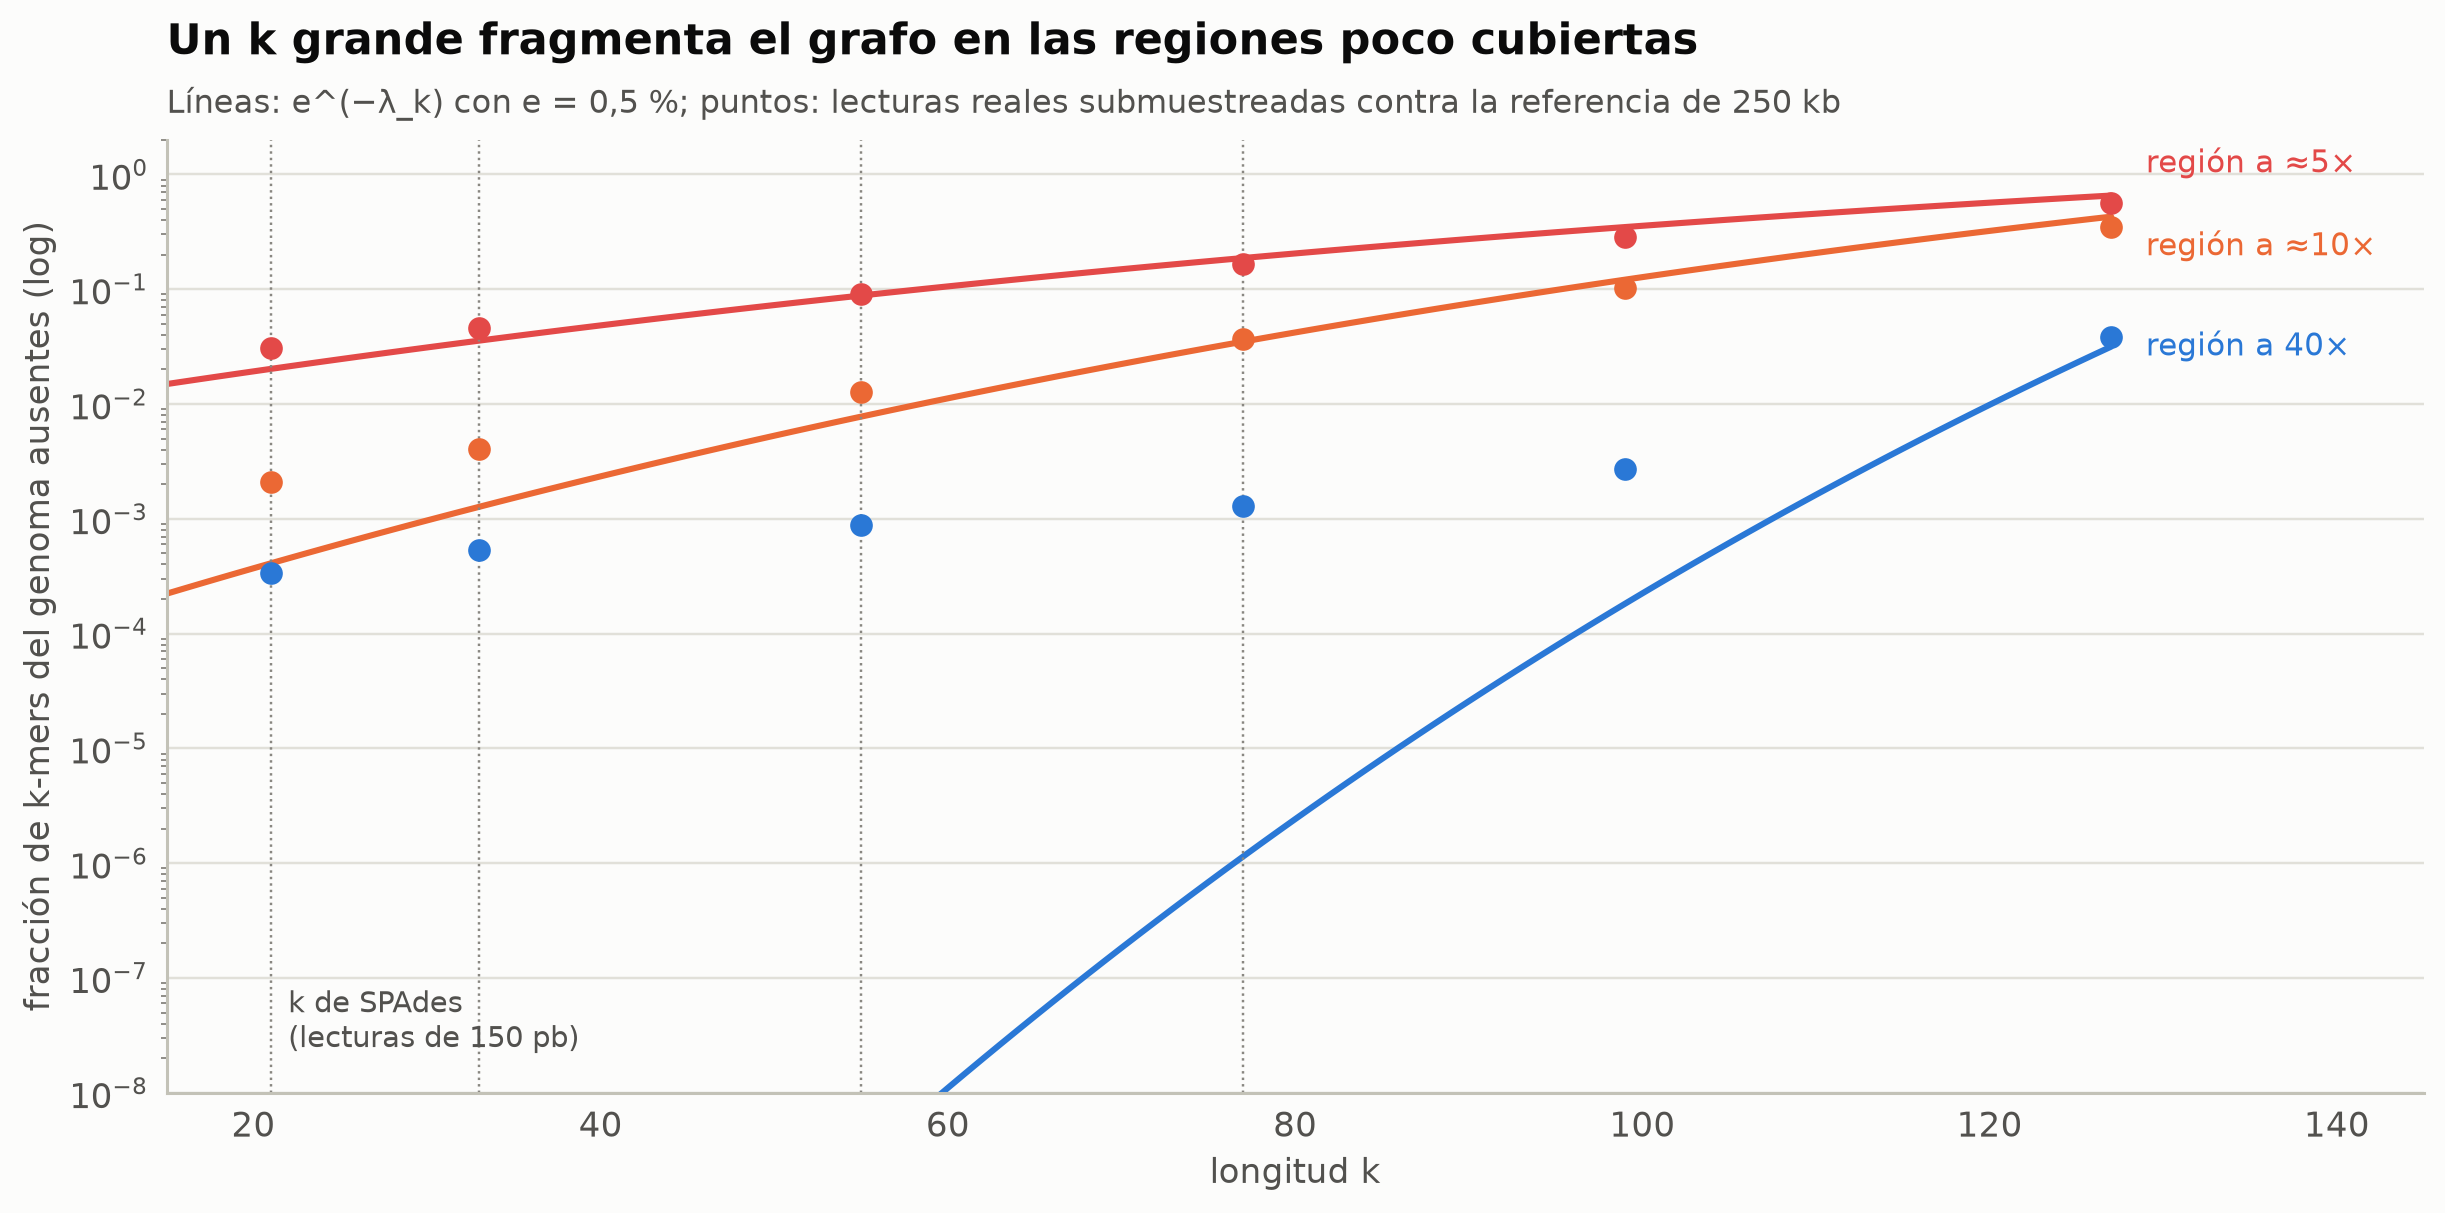

In [6]:
ks = np.arange(15, 128)
fig, ax = plt.subplots(figsize=(11, 5.4))
cols = {"≈5×": ec.RED, "≈10×": ec.ORANGE, "40×": ec.BLUE}
for lab, (c, vals) in empirical.items():
    ax.plot(ks, frac_missing(c, ks), color=cols[lab], lw=2)
    ax.scatter(k_grid, np.maximum(vals, 1e-6), s=55, color=cols[lab], edgecolor="white", zorder=4)
    ax.text(129, frac_missing(c, 127) * {"≈5×": 1.9, "≈10×": 0.55, "40×": 1.0}[lab], f"región a {lab}",
            color=cols[lab], fontsize=10, va="center")
for k in (21, 33, 55, 77):
    ax.axvline(k, color=ec.MUTED, lw=0.8, ls=":")
ax.text(22, 2.5e-8, "k de SPAdes\n(lecturas de 150 pb)", fontsize=9.5, color=ec.INK_2)
ax.set_yscale("log"); ax.set_ylim(1e-8, 2); ax.set_xlim(15, 145)
ax.set_xlabel("longitud k"); ax.set_ylabel("fracción de k-mers del genoma ausentes (log)")
ec.title(ax, "Un k grande fragmenta el grafo en las regiones poco cubiertas",
         "Líneas: e^(−λ_k) con e = 0,5 %; puntos: lecturas reales submuestreadas contra la referencia de 250 kb")
plt.show()

> 🔎 **Qué observamos.** Las curvas teóricas y los puntos reales cuentan la misma historia: con 40× casi no falta
> nada hasta $k\approx 100$, pero a 5× un $k$ de 77 ya pierde **casi uno de cada cinco** $k$-mers (0,187) y uno de 127 más de la
> mitad. Los datos reales pierden algo **más** que la teoría con $k$ pequeño (a 40× la teoría predice cero, y
> observamos ~0,03 %): allí faltan los $k$-mers que atraviesan los **sitios donde el clon difiere del ancestro**
> (mutaciones e inserciones, que veremos en la sección 9) y los bordes de la región. Y pierden algo **menos** con
> $k$ muy grande, porque la cobertura no es uniforme (los pares se solapan y hay regiones más cubiertas) y la tasa de
> error real no es exactamente 0,5 %.
>
> La conclusión práctica es la de SPAdes: usar **varios** $k$ a la vez. Los pequeños mantienen conectadas las regiones
> pobres; los grandes separan las repeticiones en las regiones ricas.

> ✅ **Compruebe su comprensión.** Un genoma humano secuenciado a 30× con lecturas de 150 pb tiene regiones ricas en
> GC que reciben sólo 5×. ¿Qué pasa con esas regiones si se ensambla sólo con $k=99$? *(Pierden ~35 % de sus
> $k$-mers: el grafo queda lleno de cortes justo allí, y el ensamblaje subrepresenta las regiones ricas en GC.)*

## 4. Cómo trabaja SPAdes

**SPAdes** (Bankevich *et al.*, 2012) nació para un caso extremo: ensamblar genomas bacterianos amplificados a partir
de **una sola célula**. En esos datos la cobertura varía en órdenes de magnitud a lo largo del genoma (unas regiones a
1000×, otras a 2×) y abundan los errores y las lecturas quiméricas. Con una variación así, la sección 3 nos dice que
**ningún $k$ fijo funciona**. La respuesta de SPAdes fue construir el grafo con **varios** valores de $k$, uno tras
otro. Aunque nació para células individuales, sus autores mostraron que también mejoraba a los ensambladores de la
época (Velvet, SOAPdenovo) en datos convencionales, y hoy es uno de los más usados para bacterias con lecturas cortas
(guía práctica: Prjibelski *et al.*, 2020).

Las etapas, en orden:

1. **Corrección de errores (BayesHammer).** Agrupa $k$-mers que difieren en pocas bases y, dentro de cada grupo,
   decide por un modelo bayesiano cuál es el verdadero; corrige las lecturas antes de ensamblar. Es la versión
   industrial de lo que hicimos en la Lección 8.1: los $k$-mers de multiplicidad 1 que están "a una letra" de un
   $k$-mer frecuente son errores.
2. **Grafo multi-$k$.** Construye el grafo de De Bruijn con un $k$ pequeño (21), que conecta las regiones de baja
   cobertura; extrae sus *contigs* y los **reinyecta como lecturas largas y sin errores** al construir el grafo con el
   siguiente $k$ (33, 55, 77…). Así el grafo con $k$ grande separa repeticiones sin perder las regiones pobres, que
   quedan representadas por los *contigs* del $k$ anterior.
3. **Simplificación.** Elimina **puntas** (*tips*: caminos cortos sin salida, típicos de un error cerca del final de
   una lectura), **burbujas** (dos caminos paralelos casi iguales: un error en medio de la lectura o un SNP
   heterocigoto) y **conexiones quiméricas** de baja cobertura. Son los defectos que dibujamos en la Lección 8.2.
4. **Resolución de repeticiones con pares (ExSPAnder).** Las dos lecturas de un par están separadas por una distancia
   conocida (el tamaño de inserto). SPAdes estima la distancia entre aristas del grafo y usa los pares que "saltan"
   por encima de una repetición para decidir qué entrada se conecta con qué salida.
5. **Salida.** `contigs.fasta` (caminos sin ambigüedad), `scaffolds.fasta` (*contigs* unidos con tramos de `N` donde
   los pares indican el orden pero falta la secuencia) y el **grafo de ensamblaje** en formato GFA, que puede verse
   con Bandage.

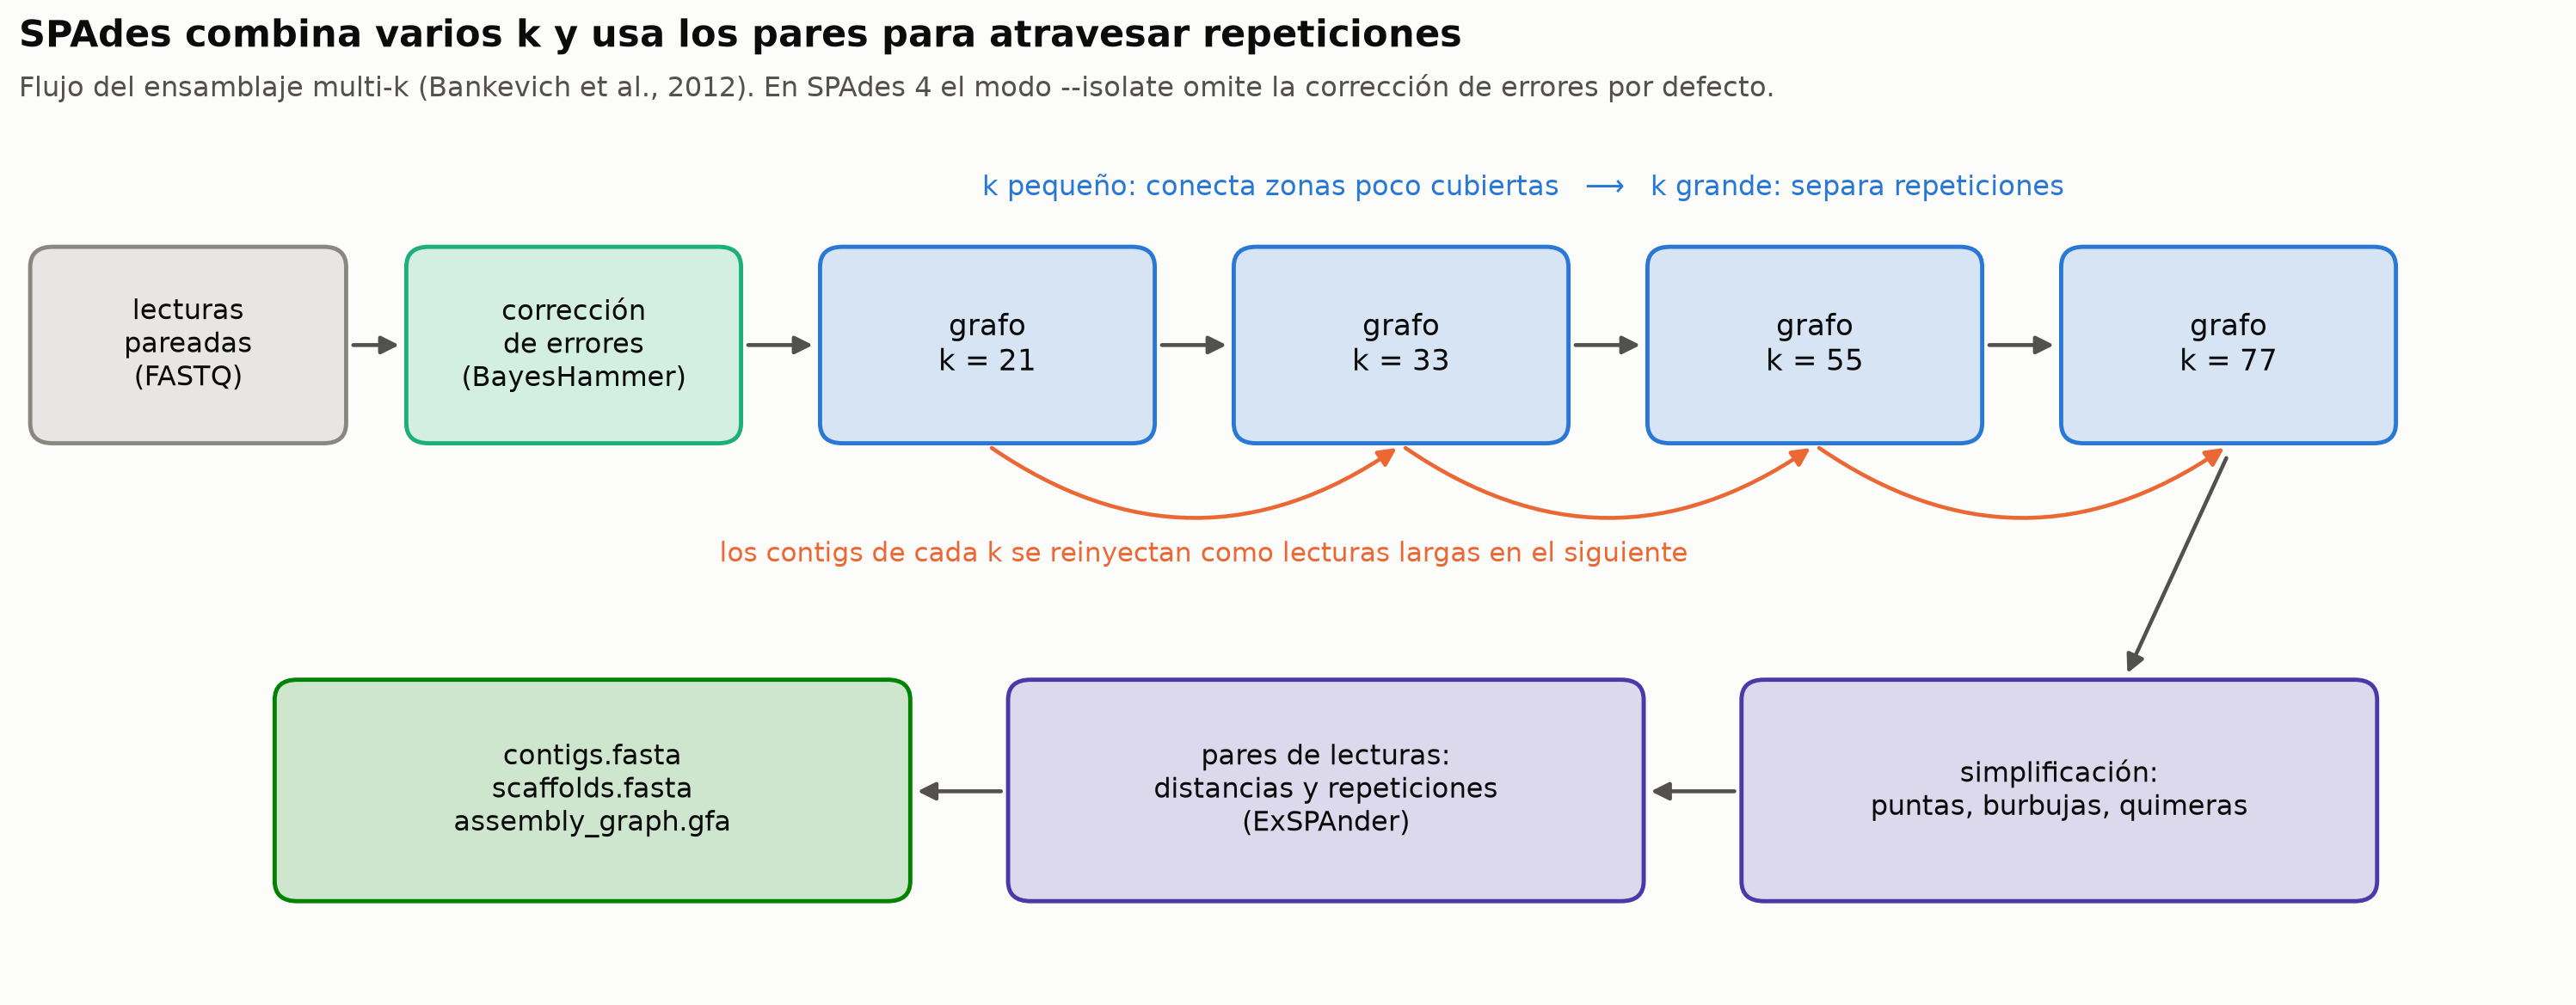

In [7]:
fig, ax = plt.subplots(figsize=(13.5, 5.2))
ax.set_xlim(0, 13.5); ax.set_ylim(0, 5.2); ax.axis("off")

def box(x, y, w, h, text, color, fs=10.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc=color, ec="none", alpha=0.18))
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc="none", ec=color, lw=1.6))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=ec.INK)

def arrow(x0, y0, x1, y1, color=ec.INK_2, style="-|>", rad=0.0, lw=1.5):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle=style, mutation_scale=14, color=color, lw=lw,
                                 connectionstyle=f"arc3,rad={rad}"))

top = 3.3
box(0.1, top, 1.6, 1.1, "lecturas\npareadas\n(FASTQ)", ec.MUTED)
box(2.1, top, 1.7, 1.1, "corrección\nde errores\n(BayesHammer)", ec.AQUA)
xs = [4.3, 6.5, 8.7, 10.9]
for x, k in zip(xs, (21, 33, 55, 77)):
    box(x, top, 1.7, 1.1, f"grafo\nk = {k}", ec.BLUE, fs=11)
arrow(1.75, top + 0.55, 2.05, top + 0.55)
arrow(3.85, top + 0.55, 4.25, top + 0.55)
for a, b in zip(xs[:-1], xs[1:]):
    arrow(a + 1.75, top + 0.55, b - 0.05, top + 0.55)
    arrow(a + 0.85, top - 0.05, b + 0.85, top - 0.05, color=ec.ORANGE, rad=0.35)
ax.text(6.3, 2.55, "los contigs de cada k se reinyectan como lecturas largas en el siguiente",
        color=ec.ORANGE, fontsize=10, ha="center")
ax.text(8.0, 4.75, "k pequeño: conecta zonas poco cubiertas   ⟶   k grande: separa repeticiones",
        ha="center", fontsize=10.5, color=ec.BLUE)
bot = 0.55
box(9.2, bot, 3.3, 1.25, "simplificación:\npuntas, burbujas, quimeras", ec.VIOLET)
box(5.3, bot, 3.3, 1.25, "pares de lecturas:\ndistancias y repeticiones\n(ExSPAnder)", ec.VIOLET)
box(1.4, bot, 3.3, 1.25, "contigs.fasta\nscaffolds.fasta\nassembly_graph.gfa", ec.GREEN)
arrow(11.75, top - 0.1, 11.2, bot + 1.3)
arrow(9.15, bot + 0.62, 8.65, bot + 0.62)
arrow(5.25, bot + 0.62, 4.75, bot + 0.62)
ec.title(ax, "SPAdes combina varios k y usa los pares para atravesar repeticiones",
         "Flujo del ensamblaje multi-k (Bankevich et al., 2012). En SPAdes 4 el modo --isolate omite la corrección de errores por defecto.")
plt.show()

> 🔎 **Qué observamos.** El flujo tiene dos direcciones: hacia la derecha, $k$ crece; por debajo (flechas naranjas),
> los *contigs* de cada paso alimentan al siguiente. El libro describe este flujo general, con la corrección como primer
> paso, y advierte la excepción que muestra el subtítulo: en las versiones recientes
> (SPAdes 4) el modo `--isolate`, el recomendado para aislados bacterianos con buena cobertura, **no** ejecuta
> BayesHammer salvo que se pida; el registro de la corrida lo dice ("*ONLY assembling (without read error
> correction)*"). Con 40× de lecturas Illumina modernas, los $k$-mers erróneos se eliminan igualmente en la
> simplificación del grafo (tienen cobertura 1–2 y forman puntas y burbujas).

### Los nombres de los *contigs*

SPAdes escribe en el nombre de cada *contig* la información más útil para una primera inspección:
`>NODE_1_length_91493_cov_14.928590` significa: el *contig* más largo (NODE_1), de 91 493 pb, con **cobertura de
$k$-mers** 14,9 (medida con el último $k$, por eso es menor que la cobertura de bases, igual que $c_k < c$). Esa
cobertura es un diagnóstico inmediato:

| Cobertura respecto de la mediana | Interpretación probable |
|---|---|
| ≈ 1× | secuencia de copia única del cromosoma |
| ≈ 2×, 3×… | **repetición colapsada**: varias copias casi idénticas ensambladas como una sola |
| ≈ 10× o más | plásmido multicopia, fago, o repetición muy abundante |
| ≪ 1× (p. ej. 0,05×) | contaminante, artefacto o lecturas "arrastradas" desde otra parte |

## 5. 🧪 SPAdes en vivo sobre lecturas reales

La orden profesional para un aislado bacteriano con lecturas pareadas ya limpias es:

```bash
spades.py --isolate -1 cepa_R1.fq.gz -2 cepa_R2.fq.gz -k 21,33,55,77 -t 8 -m 32 -o spades_cepa
seqkit seq -m 500 spades_cepa/contigs.fasta > contigs_500.fasta     # los contigs muy cortos suelen ser basura
```

| Opción | Significado |
|---|---|
| `--isolate` | modo para aislados (cobertura alta y uniforme); el recomendado para bacterias cultivadas |
| `-1`, `-2` | las dos lecturas de cada par |
| `-k 21,33,55,77` | la lista de $k$ del grafo multi-$k$ (impares, para que ningún $k$-mer sea su propio complemento inverso) |
| `-t`, `-m` | hilos y memoria máxima (GB) |
| `-o` | carpeta de salida |

**Presupuesto de tiempo.** En nuestra región, cada valor de $k$ cuesta unos 20–25 s con 2 núcleos (medido en una
computadora compartida). Para no pasar de ~1 minuto en Colab usaremos **dos** valores, `-k 21,55`, con las 34 000
pares (≈ 40×), y compararemos con el ensamblaje **precalculado** del curso (SPAdes 4, `-k 21,33,55`, mismas lecturas).

La celda siguiente descarga el binario oficial de SPAdes para Linux (versión 4.3.0, publicado en GitHub) **sólo en
Colab** y si no está instalado. Fuera de Colab usa `spades.py` si está en el `PATH` (por ejemplo, instalado con
`conda install -c bioconda spades`); si no lo encuentra, o si algo falla, sigue con el resultado precalculado.

In [8]:
SPADES_VER = "4.3.0"
SPADES_URL = f"https://github.com/ablab/spades/releases/download/v{SPADES_VER}/SPAdes-{SPADES_VER}-Linux.tar.gz"

def ensure_spades():
    """Devuelve la ruta de spades.py; en Colab lo descarga (≈ 190 MB) si hace falta."""
    if shutil.which("spades.py"):
        return shutil.which("spades.py")
    if not IN_COLAB:
        return None
    try:
        t0 = time.perf_counter()
        tgz = os.path.join(WORK, "spades.tar.gz")
        urllib.request.urlretrieve(SPADES_URL, tgz)
        with tarfile.open(tgz) as tf:
            tf.extractall(WORK)
        os.remove(tgz)
        os.environ["PATH"] = os.path.join(WORK, f"SPAdes-{SPADES_VER}-Linux", "bin") + ":" + os.environ["PATH"]
        print(f"SPAdes descargado e instalado en {time.perf_counter() - t0:.0f} s")
    except Exception as err:
        print("⚠️ No se pudo instalar SPAdes:", err)
    return shutil.which("spades.py")

def sh(cmd, log=None):
    """Ejecuta una orden de la terminal, muestra la orden y devuelve (salida, segundos)."""
    print("$", cmd.replace(WORK + "/", "").replace(WORK, "."))
    t0 = time.perf_counter()
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if log:
        open(log, "w").write(p.stdout + p.stderr)
    if p.returncode != 0:
        raise RuntimeError((p.stdout + p.stderr)[-1200:])
    return p.stdout, time.perf_counter() - t0

spades_bin = ensure_spades()
print("spades.py:", "disponible" if spades_bin else "— no disponible (se usará el resultado precalculado)")
if spades_bin:
    print(sh("spades.py --version")[0].strip())

spades.py: disponible
$ spades.py --version
SPAdes genome assembler v4.3.0


In [9]:
FQ1, FQ2 = course_file(f"{REG}_reads_1.fastq.gz"), course_file(f"{REG}_reads_2.fastq.gz")
live_dir = os.path.join(WORK, "spades_live")
live_contigs, spades_seconds = None, None
if spades_bin:
    try:
        shutil.rmtree(live_dir, ignore_errors=True)
        _, spades_seconds = sh(f"spades.py --isolate -1 {FQ1} -2 {FQ2} -k 21,55 -t 2 -m 8 -o {live_dir}",
                               log=os.path.join(WORK, "spades_live.out"))
        live_contigs = read_fasta(open(os.path.join(live_dir, "contigs.fasta"), "rb").read())
        print(f"\n✔ SPAdes terminó en {spades_seconds:.0f} s · {len(live_contigs)} contigs")
        slog = open(os.path.join(live_dir, "spades.log")).read()
        for pat in ("Mode:", "Estimated median coverage", "Estimated genome size", "Insert size"):
            hit = [l.strip() for l in slog.splitlines() if pat in l]
            if hit:
                print("  registro →", re.sub(r"^.*?(INFO|Mode)", r"\1", hit[0])[:120])
    except Exception as err:
        print("⚠️ SPAdes falló; seguimos con el resultado precalculado.\n", str(err)[-400:])
        live_contigs = None

pre_contigs = read_fasta(course_bytes(f"{REG}_spades_contigs.fasta.gz"))
print(f"Precalculado (k = 21,33,55): {len(pre_contigs)} contigs")

$ spades.py --isolate -1 ../data/REL606_3950k-4200k_reads_1.fastq.gz -2 ../data/REL606_3950k-4200k_reads_2.fastq.gz -k 21,55 -t 2 -m 8 -o spades_live



✔ SPAdes terminó en 46 s · 71 contigs
  registro → Mode: ONLY assembling (without read error correction)
  registro → INFO    General                 (kmer_coverage_model.cpp   : 238)   Estimated median coverage: 29. Coverage mad: 10.3782
  registro → INFO    General                 (kmer_coverage_model.cpp   : 376)   Estimated genome size (ignoring repeats): 240939
  registro → INFO    General                 (pair_info_count.cpp       : 200)     Insert size = 623.837, deviation = 288.882, left q
Precalculado (k = 21,33,55): 69 contigs


Pasemos los nombres de los *contigs* a una tabla. La celda extrae longitud y cobertura con una expresión regular y
calcula la cobertura **relativa** a la mediana de los *contigs* grandes (≥ 5 kb), que representan el cromosoma de
copia única.

In [10]:
def contig_table(contigs, label):
    rows = []
    for name, seq in contigs.items():
        m_ = re.match(r"NODE_(\d+)_length_(\d+)_cov_([\d.]+)", name)
        rows.append(dict(assembly=label, name=name, node=int(m_.group(1)), length=len(seq),
                         cov=float(m_.group(3)), gc=(seq.count("G") + seq.count("C")) / max(len(seq), 1)))
    df = pd.DataFrame(rows)
    med = df.loc[df.length >= 5000, "cov"].median()
    df["rel_cov"] = df["cov"] / med
    return df

tabs = [contig_table(pre_contigs, "precalculado (k=21,33,55)")]
if live_contigs:
    tabs.append(contig_table(live_contigs, "en vivo (k=21,55)"))
ctg_df = pd.concat(tabs, ignore_index=True)

summary = {}
for lab, d in ctg_df.groupby("assembly"):
    ge = d.length >= 500
    summary[lab] = {"contigs (todos)": len(d), "contigs ≥ 500 pb": int(ge.sum()),
                    "longitud ≥ 500 pb": int(d.length[ge].sum()), "mayor contig": int(d.length.max()),
                    "cobertura mediana (≥ 5 kb)": round(d["cov"][d.length >= 5000].median(), 1)}
print(pd.DataFrame(summary).to_string())
pre_df = ctg_df[ctg_df.assembly.str.startswith("pre")]
print("\nContigs ≥ 500 pb del ensamblaje precalculado:")
print(pre_df[pre_df.length >= 500][["name", "length", "cov", "rel_cov", "gc"]].round(3).to_string(index=False))

                            en vivo (k=21,55)  precalculado (k=21,33,55)
contigs (todos)                          71.0                       69.0
contigs ≥ 500 pb                         18.0                       12.0
longitud ≥ 500 pb                    244342.0                   243919.0
mayor contig                          91476.0                    91493.0
cobertura mediana (≥ 5 kb)               21.2                       15.1

Contigs ≥ 500 pb del ensamblaje precalculado:
                             name  length    cov  rel_cov    gc
NODE_1_length_91493_cov_14.928590   91493 14.929    0.986 0.508
NODE_2_length_57186_cov_15.656131   57186 15.656    1.034 0.515
NODE_3_length_36521_cov_15.173280   36521 15.173    1.002 0.525
NODE_4_length_36077_cov_15.628028   36077 15.628    1.032 0.529
 NODE_5_length_8271_cov_12.736392    8271 12.736    0.841 0.503
 NODE_6_length_7632_cov_15.104831    7632 15.105    0.998 0.539
 NODE_7_length_1444_cov_13.147769    1444 13.148    0.868 0.441
 NO

> 🤔 **Antes de ver la figura, prediga.** La región contiene tres operones *rrn* casi idénticos. ¿Cuántas veces la
> cobertura de copia única esperaría en los *contigs* de rRNA? ¿Y qué esperaría de los *contigs* de pocos cientos de
> pares de bases?

La figura interactiva sitúa cada *contig* por su longitud y su cobertura relativa. Pase el cursor por los puntos:
la etiqueta explica la interpretación más probable de cada uno.

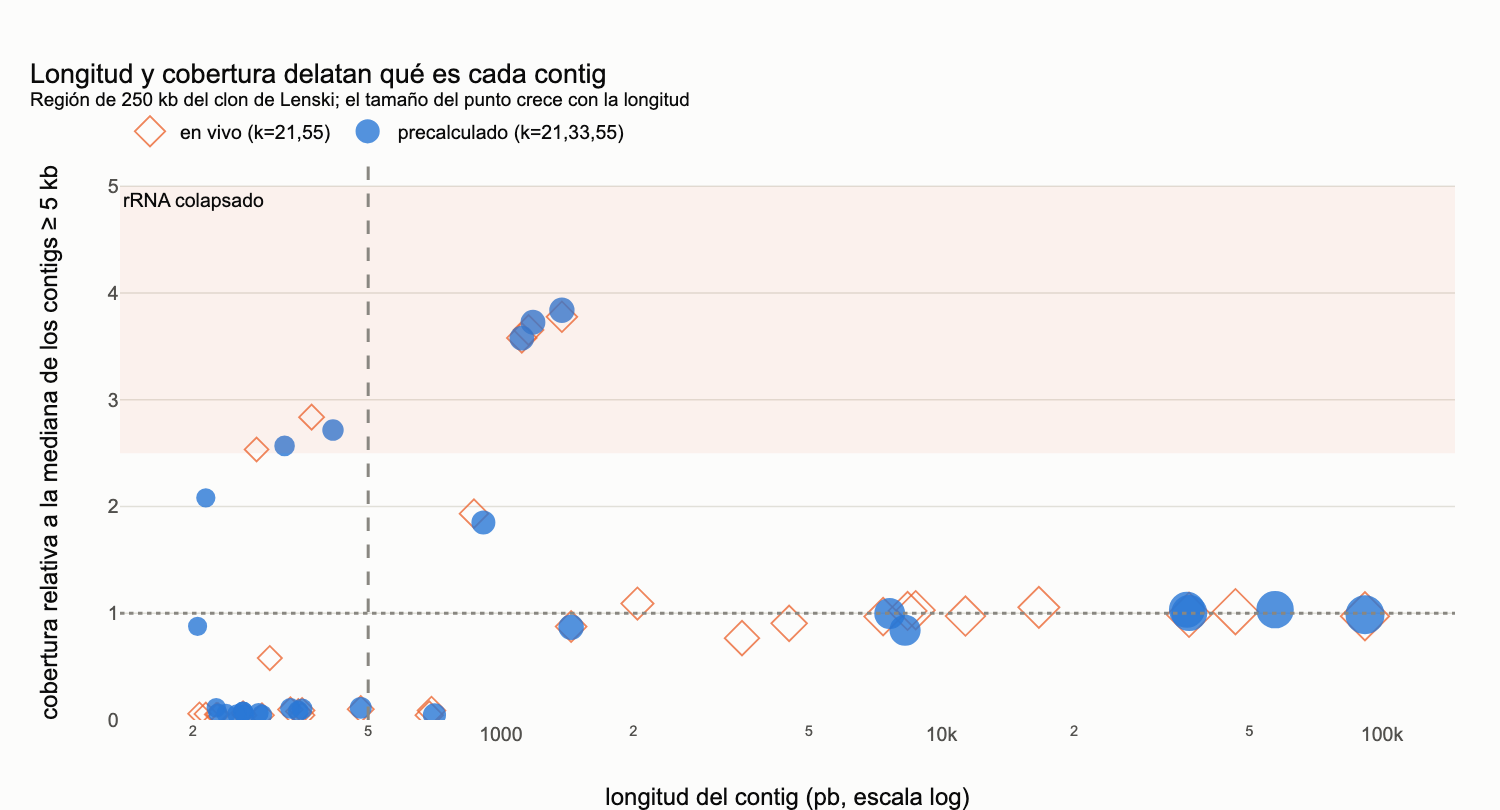

In [11]:
def interpret(row):
    if row.rel_cov >= 1.7:
        return f"≈{row.rel_cov:.1f}× la mediana: repetición colapsada (varias copias en una)"
    if row.rel_cov < 0.25:
        return "cobertura muy baja: artefacto o lecturas arrastradas desde otra parte"
    return "≈1×: secuencia de copia única"

plot_df = ctg_df[ctg_df.length >= 200].copy()
plot_df["interpretación"] = plot_df.apply(interpret, axis=1)
fig = go.Figure()
symbols = {"precalculado (k=21,33,55)": "circle", "en vivo (k=21,55)": "diamond-open"}
colors = {"precalculado (k=21,33,55)": ec.BLUE, "en vivo (k=21,55)": ec.ORANGE}
for lab, d in plot_df.groupby("assembly"):
    fig.add_trace(go.Scatter(
        x=d.length, y=d.rel_cov, mode="markers", name=lab,
        marker=dict(size=np.clip(np.log10(d.length) * 5, 6, 26), symbol=symbols[lab], color=colors[lab],
                    line=dict(width=1.2, color=colors[lab]), opacity=0.8),
        customdata=np.stack([d.name, d["cov"], d.gc * 100, d["interpretación"]], axis=1),
        hovertemplate="<b>%{customdata[0]}</b><br>longitud: %{x:,} pb<br>cobertura k-mer: %{customdata[1]:.1f}"
                      " (%{y:.2f}× la mediana)<br>GC: %{customdata[2]:.1f} %<br><i>%{customdata[3]}</i><extra></extra>"))
fig.add_hline(y=1, line=dict(color=ec.MUTED, dash="dot"))
fig.add_hrect(y0=2.5, y1=5, fillcolor=ec.ORANGE, opacity=0.07, line_width=0,
              annotation_text="rRNA colapsado", annotation_position="top left")
fig.add_vline(x=500, line=dict(color=ec.MUTED, dash="dash"), annotation_text="filtro 500 pb",
              annotation_position="bottom right")
fig.update_xaxes(type="log", title="longitud del contig (pb, escala log)")
fig.update_yaxes(title="cobertura relativa a la mediana de los contigs ≥ 5 kb", range=[0, 5.2])
fig.update_layout(title="Longitud y cobertura delatan qué es cada contig"
                        "<br><sup>Región de 250 kb del clon de Lenski; el tamaño del punto crece con la longitud</sup>",
                  height=540, margin=dict(t=110, l=80, r=30, b=60),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** Tres familias de *contigs*:
>
> * **Los grandes** (decenas de kb) están todos a ≈ 1× la mediana: cromosoma de copia única.
> * **Un grupo de 1–1,4 kb a ≈ 3,5–4×**: son trozos de los operones de rRNA. Las tres copias de la región son casi
>   idénticas, así que el grafo las **colapsa** en un solo camino que recibe las lecturas de las tres (3×) y, además,
>   algunas lecturas de los otros cuatro operones del genoma que el reclutamiento por mapeo arrastró hasta aquí. (Lo
>   medimos de otra forma en la sección 2: los 21-mers del rRNA aparecen ≈ 104 veces frente a ≈ 31 de la copia
>   única, 3,4×.)
> * **Contigs cortos de cobertura bajísima** (< 0,2×): artefactos. Uno de ellos, de 707 pb, reaparecerá en la sección
>   9 como "no alineado".
>
> Si su versión en vivo difiere del precalculado en algún *contig*, no se preocupe: los ensambladores no son
> deterministas entre versiones, sistemas operativos y número de hilos. Por eso un informe de ensamblaje **siempre**
> debe registrar la versión y los parámetros exactos.

## 6. Lecturas largas: el regreso del solapamiento

En la Lección 8.2 vimos por qué el paradigma de **solapamiento** (OLC: *overlap–layout–consensus*, camino
hamiltoniano) se abandonó con las lecturas cortas: con cientos de millones de lecturas, calcular todos los
solapamientos es imposible. Las lecturas largas cambiaron otra vez el equilibrio. Con lecturas de decenas de kilobases
hay **pocas** lecturas y muy largas, y calcular solapamientos vuelve a ser factible; además, **una lectura más larga
que una repetición la atraviesa entera**, algo que ningún $k$ de lecturas cortas consigue. El precio: las primeras
lecturas largas tenían 10–15 % de error, incompatible con $k$-mers exactos.

| Ensamblador | Idea clave | Hito |
|---|---|---|
| **Canu** (Koren *et al.*, 2017) | OLC para lecturas ruidosas; solapamientos con *MinHash* ponderado (menos peso a los $k$-mers repetitivos); corrige y luego ensambla | NG50 > 21 Mb en humano y *Drosophila* con PacBio |
| **Flye** (Kolmogorov *et al.*, 2019) | construye primero un **grafo de repeticiones** a partir de caminos arbitrarios (*disjointigs*) y lo refina | un orden de magnitud más rápido y casi el doble de NGA50 en humano |
| **hifiasm** (Cheng *et al.*, 2021) | lecturas HiFi (> 99 % de exactitud) y un **grafo con fase** que conserva ambos haplotipos | ensambló el genoma hexaploide (~30 Gb) de la secuoya |

La culminación fue el primer genoma humano **de telómero a telómero** (T2T-CHM13; Nurk *et al.*, 2022): 3 055 Mb sin
huecos (salvo el cromosoma Y), combinando HiFi y lecturas ultralargas de Nanopore. Añadió casi 200 Mb (el 8 % que
faltaba): centrómeros, duplicaciones segmentarias y los brazos cortos de los cromosomas acrocéntricos, justo las
regiones que ninguna lectura corta había podido atravesar.

Para nuestra bacteria, la moraleja es concreta: las repeticiones que hoy van a romper el ensamblaje miden 1,4 kb
(IS150) y ~5 kb (operones *rrn*). Una sola lectura de Nanopore de 10 kb las cruza de un lado a otro, y por eso los
genomas bacterianos "cerrados" (un *contig* circular por replicón) se obtienen hoy con lecturas largas, o con
ensamblajes híbridos que las combinan con Illumina.

## 7. Métricas de contigüidad: N50 y sus parientes

### La intuición

Imagine dos bibliotecas que guardan la misma enciclopedia rota en trozos. La primera tiene 10 tomos grandes y 1 000
hojas sueltas; la segunda, 40 cuadernillos medianos. ¿Cuál está "más entera"? Si promedia el tamaño de los trozos, la
primera pierde: las mil hojas sueltas hunden la media, aunque casi todo el texto está en los tomos grandes. La pregunta
útil no es "¿cuánto mide un trozo típico?", sino "**si abro la enciclopedia en una página al azar, ¿en qué tamaño de
trozo suele estar?**". Esa es la idea del N50: una medida **ponderada por longitud**.

### La definición

Un ensamblaje es una lista de longitudes $\ell_1\ge\ell_2\ge\dots\ge\ell_n$ (ordenadas de mayor a menor), con
longitud total $A=\sum_i\ell_i$. Para $0<x\le 100$:

$$
\mathrm{N}x = \ell_{j^\ast},\qquad j^\ast = \min\Bigl\{\, j \;:\; \sum_{i=1}^{j}\ell_i \;\ge\; \tfrac{x}{100}\,A \Bigr\},
\qquad \mathrm{L}x = j^\ast .
\tag{ec. 08-nx}
$$

El **NG$x$** (y el LG$x$) se define igual cambiando $A$ por el tamaño del genoma $G$ (conocido o estimado con el
espectro de $k$-mers, Lección 8.1). Si el ensamblaje no alcanza el $x\,\%$ de $G$, el NG$x$ no está definido.

| Símbolo | Significado |
|---|---|
| $\ell_i$ | longitud del $i$-ésimo *contig* más largo |
| $A$ | longitud total del ensamblaje |
| $j^\ast$ | número mínimo de *contigs* que, tomados de mayor a menor, suman el $x\,\%$ |
| L$x$ | ese número de *contigs* (el L50 es cuántos hacen falta para cubrir la mitad) |

Lectura equivalente: **la mitad de las bases del ensamblaje está en *contigs* de longitud N50 o mayor**. Si se escoge
una base al azar, hay un 50 % de probabilidad de que caiga en un *contig* de al menos N50 bases. Esa interpretación
sugiere una medida sin umbral arbitrario: la **longitud esperada del *contig* que contiene una base elegida al azar**,

$$
\mathrm{auN} = \sum_{i}\frac{\ell_i}{A}\,\ell_i = \frac{\sum_i \ell_i^2}{\sum_i \ell_i},
\tag{ec. 08-aun}
$$

que es además el **área bajo la curva N$x$** (dividida por 100) cuando $x$ recorre de 0 a 100.

| Símbolo | Significado |
|---|---|
| $\ell_i/A$ | probabilidad de que una base elegida al azar pertenezca al *contig* $i$ |
| auN | longitud media del *contig* "visto desde una base"; resume toda la curva N$x$ |

### Un ejemplo a mano

Un ensamblaje tiene diez *contigs* de **320, 250, 180, 120, 90, 60, 40, 25, 10 y 5 kb**; total $A = 1\,100$ kb. El
genoma estimado con el espectro de $k$-mers mide $G = 1\,300$ kb.

* **N50:** la mitad de $A$ es 550 kb. Acumulando: 320, y luego $320+250=570\ge 550$. Por tanto **N50 = 250 kb** y
  **L50 = 2**.
* **NG50:** la mitad de $G$ es 650 kb. Hace falta llegar a $320+250+180 = 750$: **NG50 = 180 kb**, **LG50 = 3**. El
  NG50 es menor porque penaliza los 200 kb del genoma que el ensamblaje no contiene.
* **N90:** el 90 % de $A$ son 990 kb, que se alcanzan en el sexto *contig* ($320+\dots+60 = 1\,020$): **N90 = 60 kb**.
* **auN:** $\sum\ell_i^2 = 320^2+250^2+\dots+5^2 = 225\,750$, y $225\,750/1\,100 = $ **205,2 kb**.

El código es tan corto como la definición (es el mismo del libro):

In [12]:
def nx(lengths, x=50, G=None):
    """Devuelve (Nx, Lx); con G, (NGx, LGx). ec. 08-nx"""
    ls = sorted(lengths, reverse=True)
    goal = x / 100 * (G if G else sum(ls))
    acc = 0
    for i, l in enumerate(ls, start=1):
        acc += l
        if acc >= goal:
            return l, i
    return 0, None              # el ensamblaje no alcanza x % de G

def auN(lengths):
    """ec. 08-aun: longitud esperada del contig que contiene una base al azar."""
    lengths = np.asarray(lengths, dtype=float)
    return (lengths ** 2).sum() / lengths.sum()

book = [320, 250, 180, 120, 90, 60, 40, 25, 10, 5]   # kb
print("N50, L50   =", nx(book))
print("NG50, LG50 =", nx(book, G=1300))
print("N90, L90   =", nx(book, 90))
print("auN        =", round(auN(book), 1), "kb")

N50, L50   = (250, 2)
NG50, LG50 = (180, 3)
N90, L90   = (60, 6)
auN        = 205.2 kb


La animación muestra el cálculo como lo haría a mano: se ordenan los *contigs* de mayor a menor y se van apilando
hasta que la suma cruza cada umbral (50 % de $A$, 50 % de $G$ y 90 % de $A$). El *contig* que hace cruzar el umbral
da el N$x$; su posición en la fila, el L$x$.

![El N50 se lee en el contig que hace cruzar la mitad del ensamblaje](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.3_n50_acumulado.gif)

*El N50 se lee en el contig que hace cruzar la mitad del ensamblaje*

In [13]:
book_sorted = sorted(book, reverse=True)
cum = np.cumsum(book_sorted)
A_book, G_book = sum(book), 1300
thresholds = [(0.5 * A_book, "50 % de A = 550", ec.BLUE, "N50"), (0.5 * G_book, "50 % de G = 650", ec.ORANGE, "NG50"),
              (0.9 * A_book, "90 % de A = 990", ec.GREEN, "N90")]
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw=dict(width_ratios=[1.25, 1]))
steps = [j for j in range(len(book_sorted)) for _ in range(3)] + [len(book_sorted) - 1] * 8

def draw(f):
    j = steps[f]
    axl.clear(); axr.clear()
    cols = [ec.BLUE if i <= j else ec.GRID for i in range(len(book_sorted))]
    axl.bar(range(1, 11), book_sorted, color=cols, width=0.72)
    for i, l in enumerate(book_sorted):
        axl.text(i + 1, l + 6, f"{l}", ha="center", fontsize=10, color=ec.INK if i <= j else ec.MUTED)
    axl.set_xticks(range(1, 11)); axl.set_ylim(0, 370)
    axl.set_xlabel("posición j (de mayor a menor)"); axl.set_ylabel("longitud ℓ_j (kb)")
    axl.set_title("Contigs ordenados", loc="left", fontsize=12)
    bottom = 0
    for i in range(j + 1):
        axr.bar(0, book_sorted[i], bottom=bottom, color=ec.CATEGORICAL[i % 8], width=0.5, edgecolor="white")
        if book_sorted[i] >= 60:
            axr.text(0, bottom + book_sorted[i] / 2, f"{book_sorted[i]}", ha="center", va="center", fontsize=9.5,
                     color="white")
        bottom += book_sorted[i]
    found = []
    for thr, lab, col, name in thresholds:
        axr.axhline(thr, color=col, lw=1.6, ls="--")
        axr.text(0.3, thr + 8, lab, va="bottom", fontsize=9.5, color=col)
        if cum[j] >= thr:
            jj = int(np.argmax(cum >= thr))
            found.append(f"{name} = {book_sorted[jj]} kb (L = {jj + 1})")
    axr.set_xlim(-0.4, 1.3); axr.set_ylim(0, 1350); axr.set_xticks([])
    axr.set_ylabel("suma acumulada (kb)")
    axr.set_title(f"Acumulado = {cum[j]:,} kb", loc="left", fontsize=12)
    axr.text(-0.35, 1300, "\n".join(found) if found else "aún no se cruza ningún umbral", va="top", fontsize=10.5,
             color=ec.INK)
    fig.suptitle("Apilar contigs de mayor a menor hasta cruzar el umbral da el Nx y el Lx", x=0.01, ha="left",
                 fontsize=14, fontweight="bold")

draw(0)
plt.tight_layout(rect=(0, 0, 1, 0.93))
ec.animate(fig, draw, frames=len(steps), interval=350, name="8.3_n50_acumulado")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### La trampa: el N50 mide tamaño, no verdad

Supongamos ahora que el ensamblador **une por error** los dos *contigs* mayores a través de una repetición (uno de los
errores que QUAST llama "recolocación", sección 9). El nuevo *contig* de 570 kb supera por sí solo la mitad del total.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué pasa con el N50, el L50 y el auN? ¿Mejoran o empeoran?

correcto             N50 = 250 kb · L50 = 2 · NG50 = 180 kb · auN =  205.2 kb
con la unión falsa   N50 = 570 kb · L50 = 1 · NG50 = 180 kb · auN =  350.7 kb


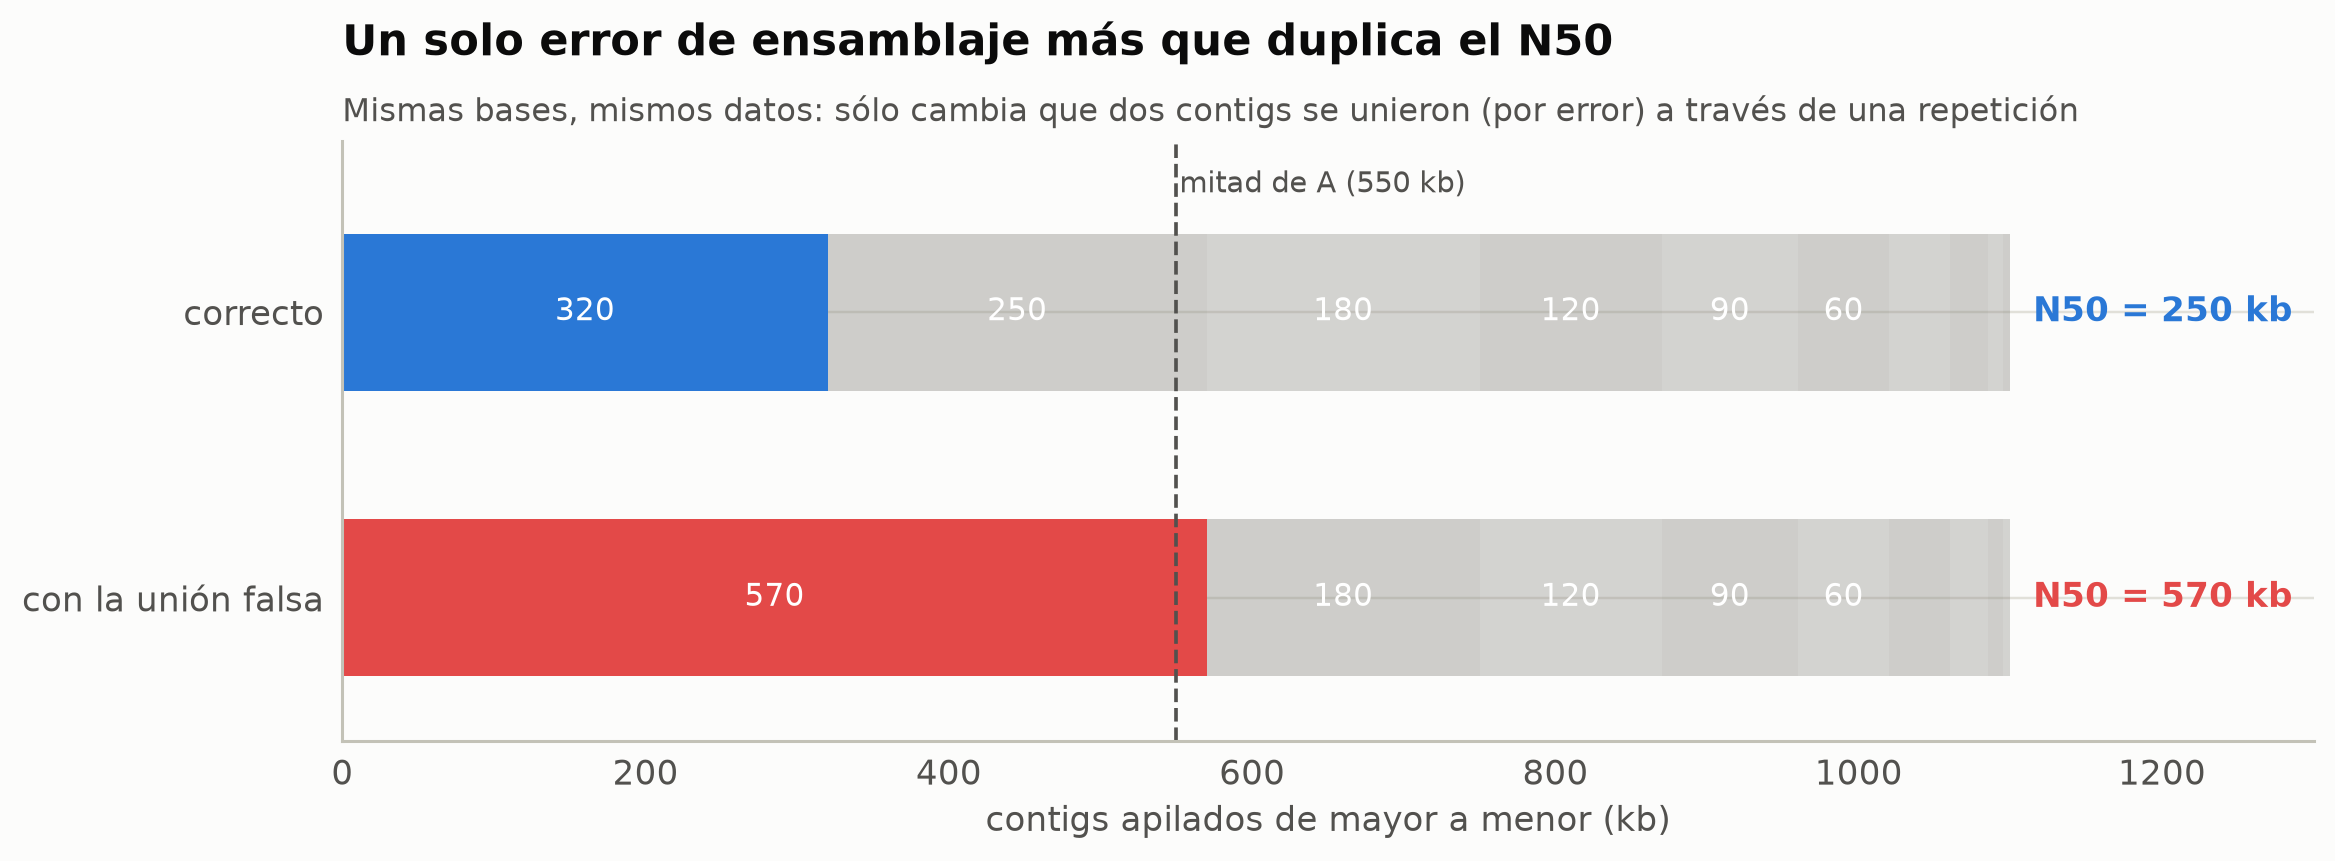

In [14]:
joined = [320 + 250] + book[2:]
for lab, ls in (("correcto", book), ("con la unión falsa", joined)):
    print(f"{lab:20s} N50 = {nx(ls)[0]:>3} kb · L50 = {nx(ls)[1]} · NG50 = {nx(ls, G=1300)[0]:>3} kb · "
          f"auN = {auN(ls):6.1f} kb")

fig, ax = plt.subplots(figsize=(10.5, 3.8))
for yy, (lab, ls, col) in enumerate([("con la unión falsa", joined, ec.RED), ("correcto", book, ec.BLUE)]):
    left = 0
    for i, l in enumerate(sorted(ls, reverse=True)):
        ax.barh(yy, l, left=left, color=col if i == 0 else ec.MUTED, alpha=1 if i == 0 else 0.35 + 0.05 * (i % 2),
                edgecolor="white", height=0.55)
        if l >= 60:
            ax.text(left + l / 2, yy, f"{l}", ha="center", va="center", color="white", fontsize=10)
        left += l
    ax.text(1115, yy, f"N50 = {nx(ls)[0]} kb", va="center", fontsize=11, color=col, fontweight="bold")
ax.axvline(550, color=ec.INK_2, ls="--", lw=1.2)
ax.text(552, 1.42, "mitad de A (550 kb)", fontsize=9.5, color=ec.INK_2)
ax.set_yticks([0, 1], ["con la unión falsa", "correcto"]); ax.set_xlim(0, 1300); ax.set_ylim(-0.5, 1.6)
ax.set_xlabel("contigs apilados de mayor a menor (kb)")
ec.title(ax, "Un solo error de ensamblaje más que duplica el N50",
         "Mismas bases, mismos datos: sólo cambia que dos contigs se unieron (por error) a través de una repetición")
plt.show()

> 🔎 **Qué observamos.** El error **mejora** todas las métricas de contigüidad: el N50 pasa de 250 a **570 kb**, el
> L50 de 2 a 1 y el auN de 205 a 351 kb. Es el defecto fundamental de estas métricas: **premian las uniones,
> correctas o no**. Un ensamblador agresivo que atraviesa repeticiones sin evidencia obtiene mejores N50 que uno
> prudente. La única defensa es medir también la **exactitud** (sección 9).

Hay una segunda trampa, más sutil: el N50 depende del **umbral de longitud mínima**. Eliminar los *contigs* cortos
reduce $A$ y puede **aumentar** el N50 sin cambiar nada del ensamblaje. Probémoslo con el ensamblaje **A** del libro
(un ensamblaje simulado de lecturas cortas de un genoma bacteriano de 5 Mb, con 215 *contigs*).

In [15]:
ab_df = pd.read_csv(io.BytesIO(course_bytes("83_ensambles_AB.tsv")), sep="\t", comment="#")
asmA = ab_df.loc[ab_df.assembly == "A", "length"].to_numpy()
asmB = ab_df.loc[ab_df.assembly == "B", "length"].to_numpy()
G_sim = 5_000_000
for nom, ls in (("A (lecturas cortas)", asmA), ("B (lecturas largas)", asmB)):
    print(f"{nom}: {len(ls)} contigs · total {ls.sum():,} pb · N50 = {nx(ls)[0]:,} (L50 = {nx(ls)[1]}) · "
          f"NG50 = {nx(ls, G=G_sim)[0]:,} · auN = {auN(ls):,.0f}")

rows = []
for thr in (500, 5_000, 20_000, 50_000):
    ls = asmA[asmA >= thr]
    rows.append({"umbral": f"≥ {thr:,} pb", "contigs": len(ls), "total (Mb)": round(ls.sum() / 1e6, 2),
                 "N50": nx(ls)[0], "NG50 (G = 5 Mb)": nx(ls, G=G_sim)[0] or "no definido"})
print("\nEnsamblaje A con distintos umbrales de longitud mínima:")
print(pd.DataFrame(rows).to_string(index=False))

A (lecturas cortas): 215 contigs · total 4,848,179 pb · N50 = 38,945 (L50 = 40) · NG50 = 38,441 · auN = 44,744
B (lecturas largas): 10 contigs · total 4,989,995 pb · N50 = 728,243 (L50 = 3) · NG50 = 728,243 · auN = 827,491

Ensamblaje A con distintos umbrales de longitud mínima:
     umbral  contigs  total (Mb)   N50 NG50 (G = 5 Mb)
   ≥ 500 pb      215        4.85 38945           38441
 ≥ 5,000 pb      169        4.73 40134           38441
≥ 20,000 pb       86        3.75 49135           38441
≥ 50,000 pb       21        1.56 78809     no definido


> 🔎 **Qué observamos.** Sólo **tirando** *contigs* cortos, el N50 del ensamblaje A sube; el ensamblaje es exactamente
> el mismo, pero "parece" mejor. El **NG50** usa un denominador fijo ($G$) y no se deja engañar: se mantiene y, cuando
> se tira demasiado, deja de estar definido porque ya no se cubre la mitad del genoma. Moraleja del libro: compare
> siempre con el mismo umbral (QUAST usa 500 pb por defecto) y prefiera el NG50.

### Curvas N$x$: mirar la distribución completa

Un solo número (el N50) es un punto de una curva. La **curva N$x$** dibuja N$x$ para todo $x$ entre 0 y 100: es una
escalera que baja a medida que se incorporan *contigs* más cortos. Comparar curvas completas es mucho más informativo
que comparar un punto.

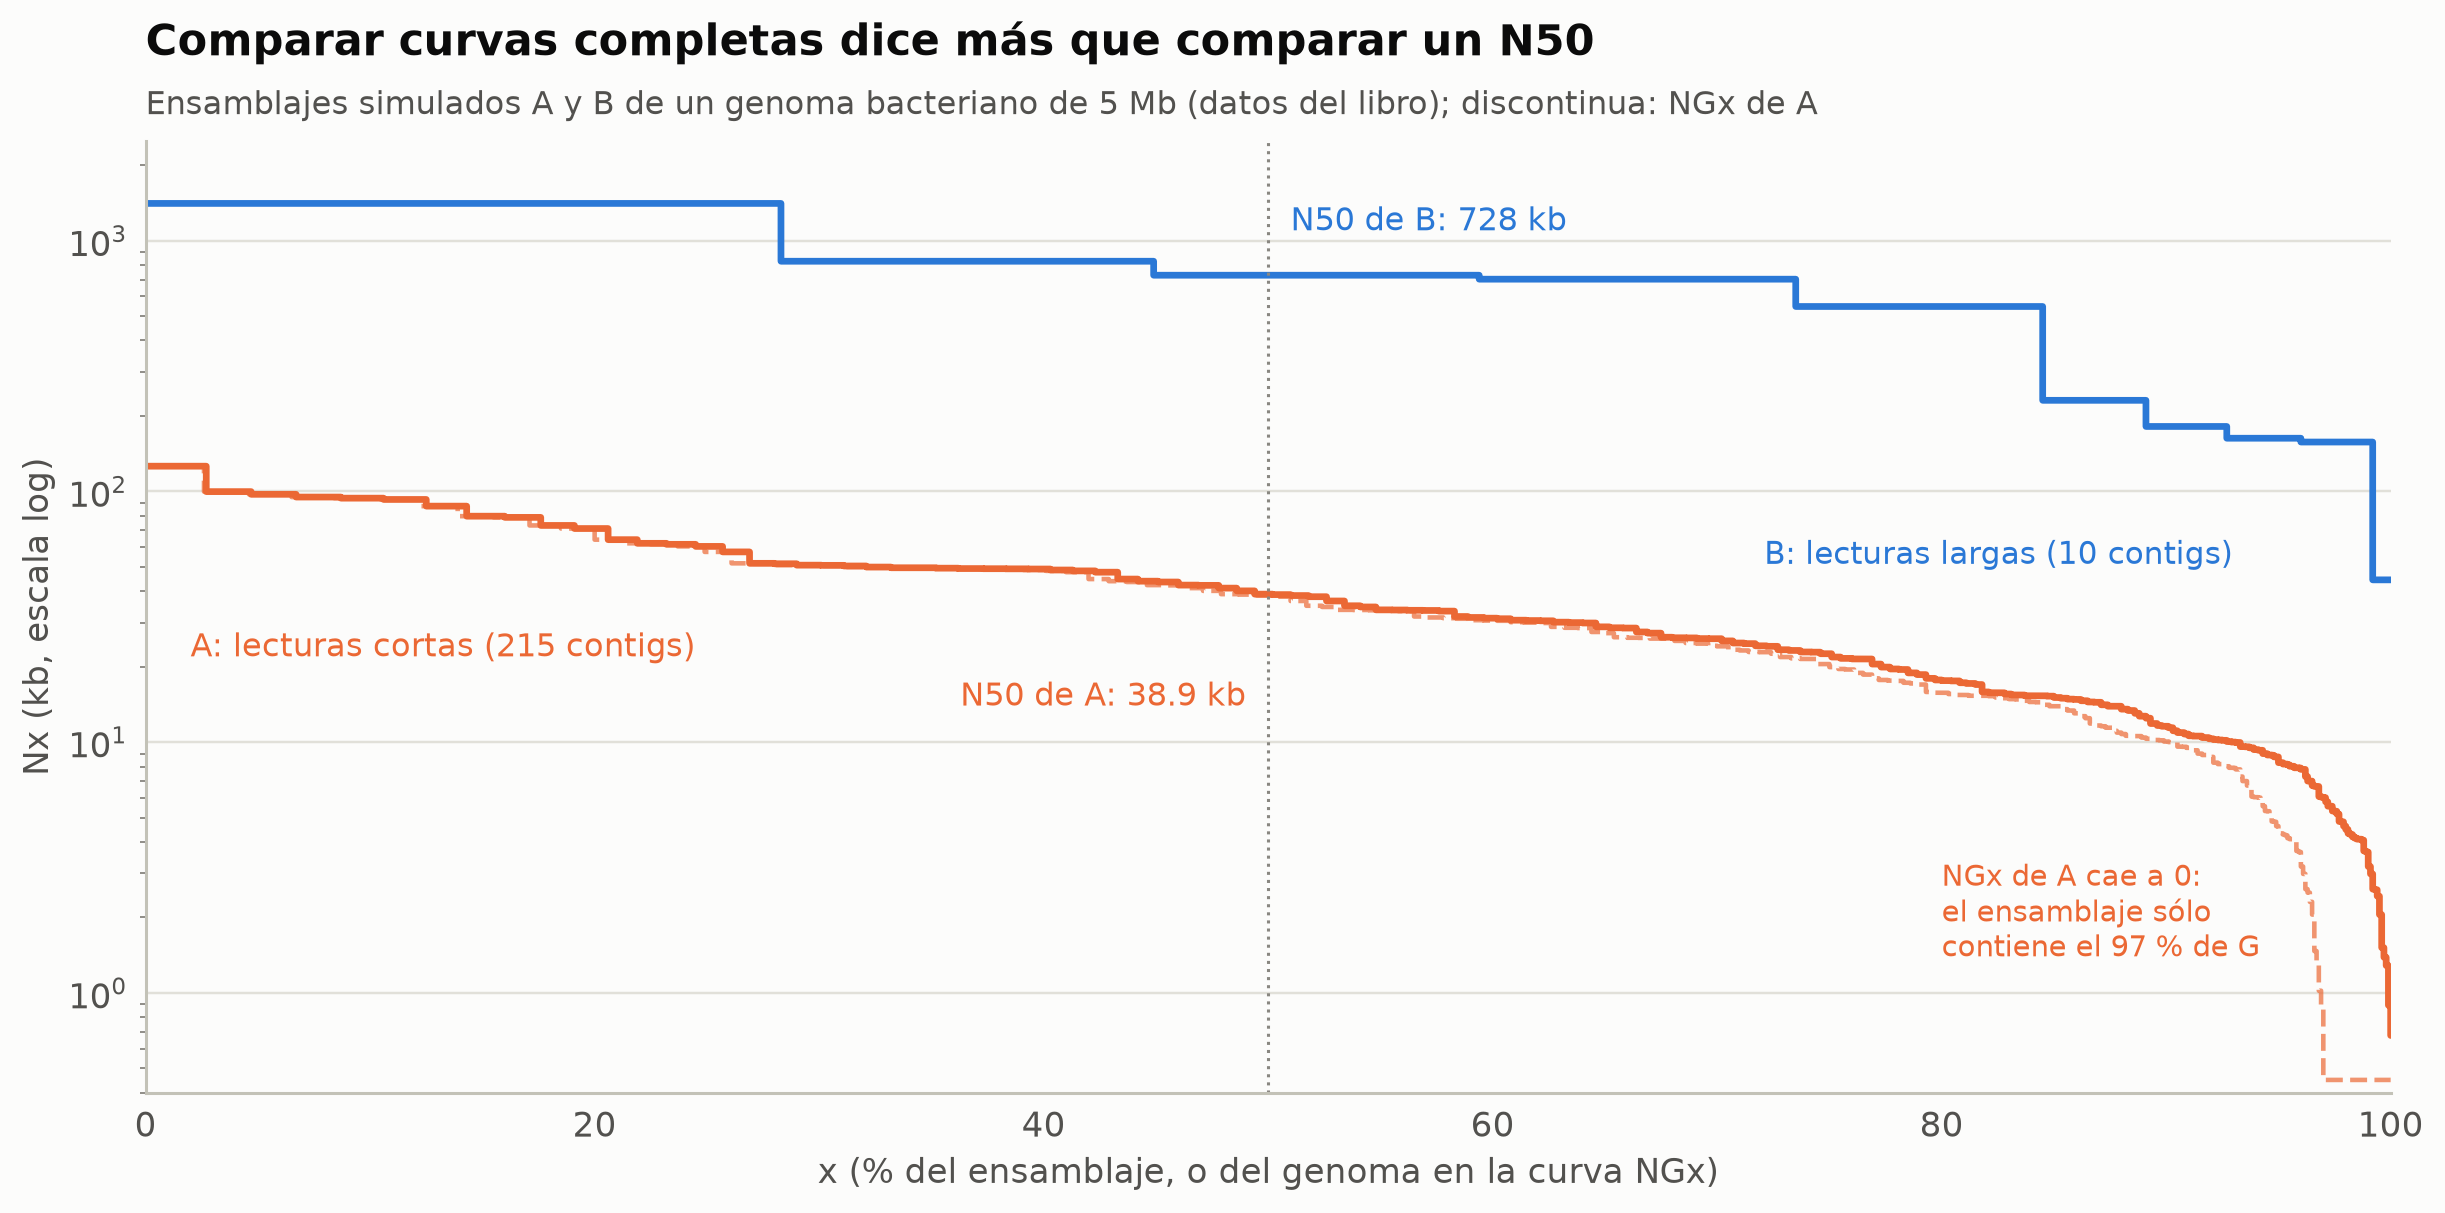

In [16]:
def nx_curve(lengths, total=None, xs=np.linspace(0, 100, 1001)):
    """Curva Nx (o NGx con total = G): para cada x, la longitud del contig que hace cruzar el x %."""
    ls = np.sort(np.asarray(lengths))[::-1]
    total = total or ls.sum()
    csum = np.cumsum(ls)
    idx = np.searchsorted(csum, xs / 100 * total - 1e-9)
    out = np.where(idx < len(ls), ls[np.minimum(idx, len(ls) - 1)], 0)
    return xs, out, np.where(idx < len(ls), idx + 1, 0)

fig, ax = plt.subplots(figsize=(11, 5.4))
xs, yb, _ = nx_curve(asmB)
ax.step(xs, yb / 1e3, where="post", color=ec.BLUE, lw=2.2)
xs, ya, _ = nx_curve(asmA)
ax.step(xs, ya / 1e3, where="post", color=ec.ORANGE, lw=2.2)
xs, yag, _ = nx_curve(asmA, G_sim)
ax.step(xs, np.maximum(yag, 0.45e3) / 1e3, where="post", color=ec.ORANGE, lw=1.5, ls="--", alpha=0.7)
ax.set_yscale("log"); ax.set_ylim(0.4, 2500); ax.set_xlim(0, 100)
ax.axvline(50, color=ec.MUTED, ls=":", lw=1)
ax.text(51, 1100, f"N50 de B: {nx(asmB)[0] / 1e3:,.0f} kb", fontsize=10.5, color=ec.BLUE)
ax.text(49, 14, f"N50 de A: {nx(asmA)[0] / 1e3:.1f} kb", fontsize=10.5, color=ec.ORANGE, ha="right")
ax.text(80, 1.4, "NGx de A cae a 0:\nel ensamblaje sólo\ncontiene el 97 % de G", fontsize=9.5, color=ec.ORANGE)
ec.label_end(ax, 100, yb[-1] / 1e3 * 1.25, "B: lecturas largas (10 contigs)", color=ec.BLUE, dx=-205)
ax.text(2, 22, "A: lecturas cortas (215 contigs)", fontsize=10.5, color=ec.ORANGE)
ax.set_xlabel("x (% del ensamblaje, o del genoma en la curva NGx)"); ax.set_ylabel("Nx (kb, escala log)")
ec.title(ax, "Comparar curvas completas dice más que comparar un N50",
         "Ensamblajes simulados A y B de un genoma bacteriano de 5 Mb (datos del libro); discontinua: NGx de A")
plt.show()

Comprobemos numéricamente que el auN es el área bajo la curva N$x$ dividida por 100 (integrando la escalera con
un paso de 0,01 %):

In [17]:
for nom, ls in (("libro", np.array(book) * 1000), ("A", asmA), ("B", asmB)):
    xs_, ys_, _ = nx_curve(ls, xs=np.linspace(0, 100, 10_001))
    area = np.trapezoid(ys_, xs_) / 100 if hasattr(np, "trapezoid") else np.trapz(ys_, xs_) / 100
    print(f"{nom:6s} auN = {auN(ls):>12,.0f} pb · área bajo Nx / 100 = {area:>12,.0f} pb")

libro  auN =      205,227 pb · área bajo Nx / 100 =      205,231 pb
A      auN =       44,744 pb · área bajo Nx / 100 =       44,745 pb
B      auN =      827,491 pb · área bajo Nx / 100 =      827,513 pb


### 🔍 Curvas interactivas: simulación frente a ensamblajes reales

La figura siguiente reúne cuatro ensamblajes: los dos simulados del libro y los dos reales de hoy (la región de 250 kb
y el genoma completo del clon, precalculado con todas las lecturas). Para que sean comparables usamos la curva **NG$x$**
con el tamaño de genoma correspondiente. Pase el cursor por las curvas: la etiqueta dice cuántos *contigs* hacen falta
para cubrir ese porcentaje del genoma.

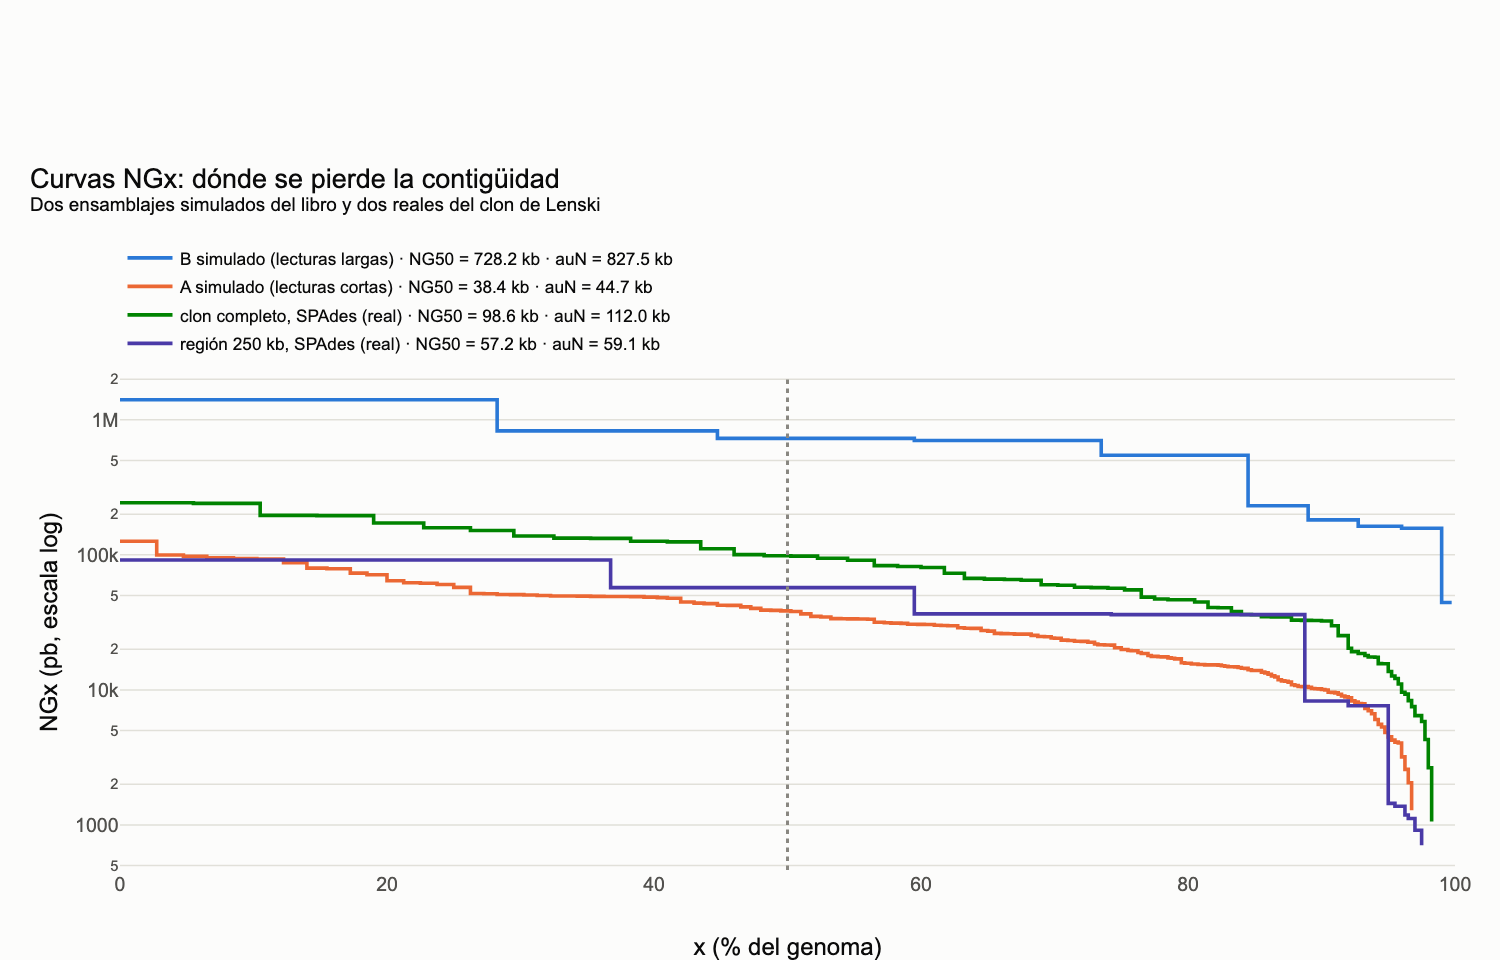

In [18]:
full_contigs = read_fasta(course_bytes("SRR2584863_spades_full_contigs.fasta.gz"))
full_len = np.array([len(s) for s in full_contigs.values()])
G_REL606 = 4_629_812
reg_len = np.array([len(s) for s in pre_contigs.values() if len(s) >= 500])
curves = [("B simulado (lecturas largas)", asmB, G_sim, ec.BLUE),
          ("A simulado (lecturas cortas)", asmA, G_sim, ec.ORANGE),
          ("clon completo, SPAdes (real)", full_len, G_REL606, ec.GREEN),
          ("región 250 kb, SPAdes (real)", reg_len, G_reg, ec.VIOLET)]
fig = go.Figure()
for name, ls, Gx, col in curves:
    xs_, ys_, js_ = nx_curve(ls, Gx, xs=np.linspace(0, 100, 401))
    ok = ys_ > 0
    fig.add_trace(go.Scatter(
        x=xs_[ok], y=ys_[ok], mode="lines", line=dict(color=col, width=2.4, shape="hv"),
        name=f"{name} · NG50 = {nx(ls, G=Gx)[0] / 1e3:,.1f} kb · auN = {auN(ls) / 1e3:,.1f} kb",
        customdata=js_[ok],
        hovertemplate=f"<b>{name}</b><br>el %{{x:.1f}} % del genoma está en contigs ≥ %{{y:,}} pb"
                      "<br>hacen falta %{customdata} contigs (LG) para llegar ahí<extra></extra>"))
fig.add_vline(x=50, line=dict(color=ec.MUTED, dash="dot"))
fig.update_yaxes(type="log", title="NGx (pb, escala log)")
fig.update_xaxes(title="x (% del genoma)", range=[0, 100])
fig.update_layout(title="Curvas NGx: dónde se pierde la contigüidad"
                        "<br><sup>Dos ensamblajes simulados del libro y dos reales del clon de Lenski</sup>",
                  height=640, margin=dict(t=250, l=80, r=30, b=60),
                  legend=dict(yanchor="bottom", y=1.02, x=0, font=dict(size=11.5)))
fig.show()

> 🔎 **Qué observamos.** El ensamblaje real del clon completo (verde) se parece mucho al simulado de lecturas cortas
> (naranja) en la forma, aunque con *contigs* más largos: el real tiene N50 ≈ 100 kb (98 594 pb) y el simulado del
> libro, N50 = 38 945 pb. Ambos muestran una escalera que baja suavemente y una curva que **no llega al 100 %** (cae antes de $x=100$):
> falta ~1,7 % del genoma. En la sección 10 veremos exactamente qué falta y por qué. El de lecturas largas (azul)
> juega en otra liga: con 10 *contigs* el NG50 supera 700 kb. La región de 250 kb (violeta) tiene pocos *contigs* y,
> por su tamaño, un NG50 de ~57 kb: una curva N$x$ sólo se interpreta junto con el tamaño del genoma.

> ✅ **Compruebe su comprensión.** Un colega reporta "N50 = 2 Mb" para un ensamblaje bacteriano de 5 Mb hecho con
> Illumina 2 × 150. ¿Qué dos preguntas le haría antes de celebrar? *(¿Con qué umbral de longitud mínima? ¿Cuántos
> errores de ensamblaje reporta QUAST, y cuál es el NGA50? Con lecturas cortas, *contigs* de 2 Mb exigen atravesar
> los operones rrn y los IS, algo sospechoso sin lecturas largas.)*

## 8. Andamiaje: ordenar *contigs* con pares de lecturas

### La intuición

Los *contigs* terminan donde el grafo es ambiguo, pero a menudo **sabemos qué *contig* sigue a cuál** aunque no
conozcamos la secuencia intermedia. Piense en dos trozos de una cinta métrica rota: si alguien le dice "entre la marca
del 40 en un trozo y la del 10 en el otro hay 50 cm", usted puede colocar los trozos en su sitio y saber cuánto falta
entre ellos, aunque no tenga el pedazo perdido.

Los pares de lecturas son esas medidas: las dos lecturas de un par vienen de los extremos de un mismo fragmento de ADN,
cuyo tamaño (el **inserto**) conocemos en promedio. El **andamiaje** (*scaffolding*) ordena y orienta *contigs* usando
esa información de largo alcance (pares, lecturas largas, mapas ópticos o contactos Hi-C). El resultado, un
***scaffold***, es una secuencia con tramos de `N` que representan huecos de tamaño **estimado**.

### La ecuación

Si una lectura de un par cae a una distancia $a$ del final del *contig* $C_1$, su compañera a una distancia $b$ del
inicio de $C_2$, y el tamaño medio del inserto es $\mu$:

$$
\widehat{g} \;=\; \mu - a - b
\tag{ec. 08-hueco}
$$

| Símbolo | Significado |
|---|---|
| $\mu$ | tamaño medio del inserto de la biblioteca (distancia entre los extremos **externos** del par) |
| $a,\ b$ | distancias de cada lectura del par (desde su extremo externo) al borde correspondiente de su *contig* |
| $\widehat{g}$ | longitud estimada del hueco, que se rellenará con `N` |

**A mano.** Con $\mu = 500$ pb, un par con $a = 180$ y $b = 120$ da $\widehat g = 500-180-120 = 200$ pb de hueco. Otro
par con $a = 330$ y $b = 230$ da $\widehat g = -60$: un hueco **negativo** significa que los *contigs* se **solapan**
(a menudo por una repetición colapsada en sus extremos). Un solo par es ruidoso, porque el inserto varía de fragmento
en fragmento; promediando $n$ pares la incertidumbre baja como $\sigma/\sqrt n$.

### Paso 1: colocar cada lectura sobre los *contigs*

Necesitamos saber en qué *contig*, en qué posición y en qué hebra cae cada lectura. No hace falta un mapeador completo:
basta un 31-mer **único** de la lectura (probamos en las posiciones 0, 30, 60, 90 y 119 de la lectura hasta encontrar
uno que aparezca una sola vez en los *contigs*). Es la idea de "semilla" de la Lección 7.2, sin extensión.

In [19]:
K_ALN = 31

def build_index(seqs, k=K_ALN):
    """Índice de k-mers canónicos de una lista de secuencias: arrays ordenados por código."""
    codes, ids, pos, fws = [], [], [], []
    for i, s in enumerate(seqs):
        c, f, ok = kmer_codes(to_codes(s), k)
        keep = np.nonzero(ok[0])[0]
        codes.append(c[0][keep]); fws.append(f[0][keep])
        ids.append(np.full(len(keep), i, np.int32)); pos.append(keep.astype(np.int64))
    codes = np.concatenate(codes); o = np.argsort(codes, kind="stable")
    return dict(k=k, codes=codes[o], ids=np.concatenate(ids)[o], pos=np.concatenate(pos)[o],
                fw=np.concatenate(fws)[o], lengths=np.array([len(s) for s in seqs]))

def lookup(idx, c):
    """Para cada código: índice de su primera aparición en el índice y número de apariciones."""
    i = np.searchsorted(idx["codes"], c)
    j = np.searchsorted(idx["codes"], c, side="right")
    return np.minimum(i, len(idx["codes"]) - 1), j - i

def place_reads(R, idx, offsets=(0, 30, 60, 90, 119)):
    """Coloca cada lectura con su primer 31-mer único: (contig, inicio más a la izquierda, misma hebra)."""
    k, n = idx["k"], R.shape[0]
    cid = np.full(n, -1); start = np.zeros(n, np.int64); same = np.zeros(n, bool)
    for off in offsets:
        c, f, ok = kmer_codes(R[:, off:off + k], k)
        c, f, ok = c[:, 0], f[:, 0], ok[:, 0]
        i, cnt = lookup(idx, c)
        new = (cnt == 1) & ok & (cid < 0)
        s_ = f == idx["fw"][i]                                    # misma orientación que el contig
        st = np.where(s_, idx["pos"][i] - off, idx["pos"][i] - (R.shape[1] - off - k))
        cid[new], start[new], same[new] = idx["ids"][i][new], st[new], s_[new]
    return cid, start, same

def pair_geometry(cid, start, same, L=150):
    """Separa los pares en 'mismo contig' (para medir el inserto) y 'entre contigs' (para andamiar)."""
    n = len(cid) // 2
    c1, c2, s1, s2, t1, t2 = cid[:n], cid[n:], start[:n], start[n:], same[:n], same[n:]
    both = (c1 >= 0) & (c2 >= 0)
    inner = both & (c1 == c2) & (t1 != t2)
    left, right = np.where(t1, s1, s2), np.where(t1, s2, s1)
    ins = (right + L - left)[inner]
    return ins[(ins > 0) & (ins < 3000)], both & (c1 != c2)

t0 = time.perf_counter()
big = [s for s in pre_contigs.values() if len(s) >= 500]
big_names = [n for n, s in pre_contigs.items() if len(s) >= 500]
idx_ctg = build_index(big)
cid, start, same = place_reads(R, idx_ctg)
inserts, cross = pair_geometry(cid, start, same)
mu, mu_w, sd = inserts.mean(), (inserts.astype(float) ** 2).mean() / inserts.mean(), inserts.std()
print(f"Lecturas colocadas: {(cid >= 0).mean():.1%} · tiempo {time.perf_counter() - t0:.1f} s")
print(f"Pares en el mismo contig: {len(inserts):,} · inserto medio μ = {mu:.0f} pb · mediana {np.median(inserts):.0f}"
      f" · desviación típica σ = {sd:.0f} pb")
print(f"Pares que unen dos contigs distintos: {cross.sum():,}")

Lecturas colocadas: 96.4% · tiempo 0.1 s
Pares en el mismo contig: 29,838 · inserto medio μ = 598 pb · mediana 635 · desviación típica σ = 312 pb
Pares que unen dos contigs distintos: 1,359


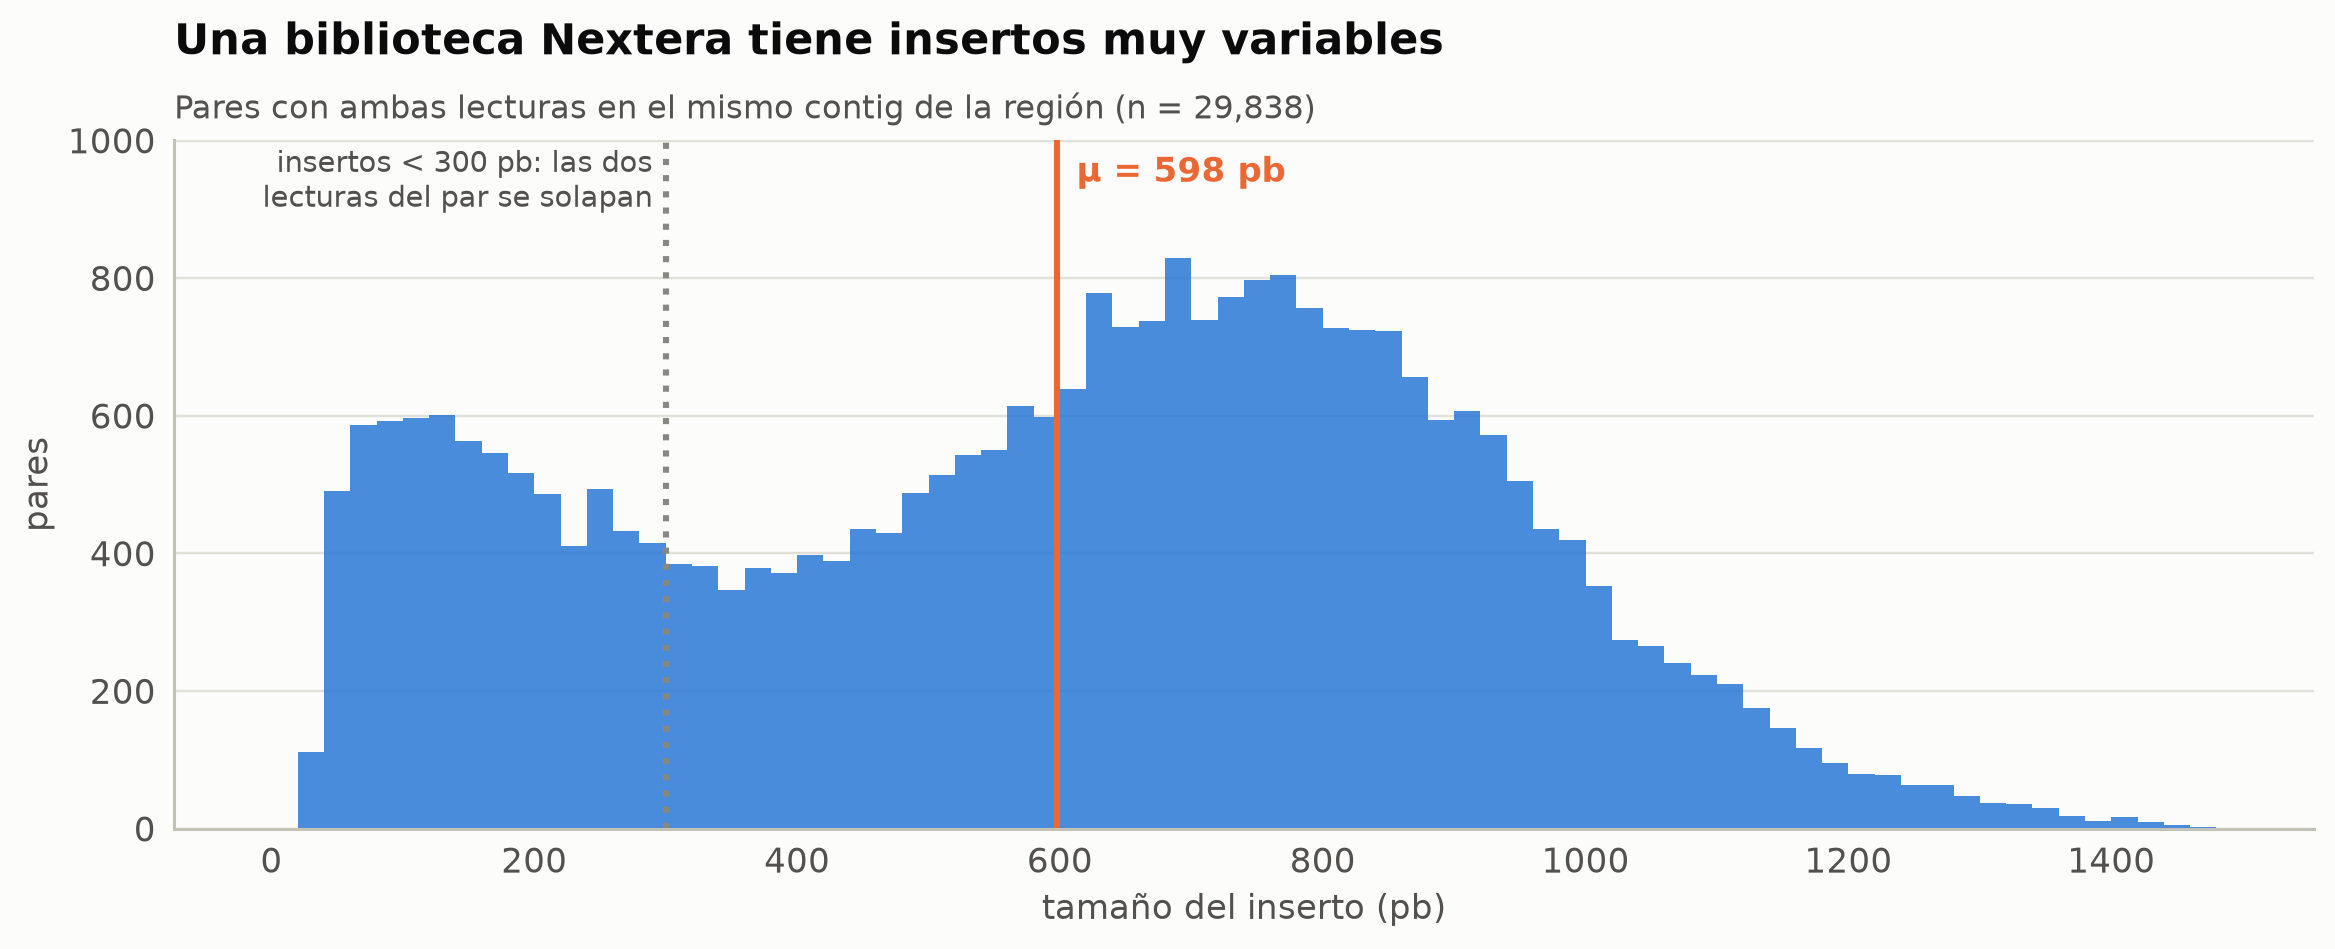

In [20]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.hist(inserts, bins=np.arange(0, 1500, 20), color=ec.BLUE, alpha=0.85)
ytop = ax.get_ylim()[1]; ax.set_ylim(0, ytop * 1.15)
ax.axvline(mu, color=ec.ORANGE, lw=2)
ax.text(mu + 15, ytop * 1.08, f"μ = {mu:.0f} pb", color=ec.ORANGE, fontsize=11, fontweight="bold")
ax.axvline(2 * L, color=ec.MUTED, ls=":")
ax.text(2 * L - 10, ytop * 1.08, "insertos < 300 pb: las dos\nlecturas del par se solapan", fontsize=9.5,
        color=ec.INK_2, ha="right", va="center")
ax.set_xlabel("tamaño del inserto (pb)"); ax.set_ylabel("pares")
ec.title(ax, "Una biblioteca Nextera tiene insertos muy variables",
         f"Pares con ambas lecturas en el mismo contig de la región (n = {len(inserts):,})")
plt.show()

> 🔎 **Qué observamos.** Los insertos van de menos de 150 pb a más de 1 kb, con media ≈ 600 pb: es la biblioteca
> Nextera que ya vimos en las Lecciones 6.2 y 7.2. Una $\sigma$ de ~300 pb anuncia que cada estimación individual
> $\widehat g$ tendrá un error de ese orden. Y hay algo más importante: **ningún par puede saltar un hueco mucho mayor
> que ~1 kb**. Los operones *rrn* miden ~5 kb: estos pares no pueden ordenar los *contigs* que los flanquean.

### Paso 2: un experimento con la verdad conocida

Para comprobar la ecuación necesitamos huecos cuyo tamaño conozcamos. Tomamos el *contig* más largo (91 kb), le
quitamos un tramo de $g$ pb a partir de la posición 40 000 y lo tratamos como dos *contigs* $C_1$ y $C_2$. Luego
colocamos las lecturas reales y estimamos el hueco con los pares que caen uno en cada lado.

In [21]:
node1 = big[0]
def gap_experiment(g, cut=40_000):
    idx_ = build_index([node1[:cut], node1[cut + g:]])
    c_, s_, t_ = place_reads(R, idx_)
    n = len(c_) // 2
    ok = (c_[:n] == 0) & (c_[n:] == 1) | (c_[:n] == 1) & (c_[n:] == 0)
    # la lectura en C1 debe apuntar hacia la derecha (+) y la de C2 hacia la izquierda (−)
    rows_ = np.arange(n)
    r1_, r2_ = np.where(c_[:n] == 0, rows_, rows_ + n), np.where(c_[:n] == 0, rows_ + n, rows_)
    good = ok & t_[r1_] & ~t_[r2_]
    a = idx_["lengths"][0] - s_[r1_][good]                     # extremo externo de la lectura → final de C1
    b = s_[r2_][good] + L                                       # inicio de C2 → extremo externo de la compañera
    return a, b

rows, per_pair = [], {}
for g in (0, 300, 600, 1000):
    a, b = gap_experiment(g)
    est = mu - a - b
    per_pair[g] = (est, mu_w - a - b)
    rows.append({"hueco real g": g, "pares que lo cruzan": len(a),
                 "ĝ = μ − a − b (mediana)": int(np.median(est)) if len(a) else None,
                 "ĝ con μ ponderado (mediana)": int(np.median(mu_w - a - b)) if len(a) else None,
                 "error típico σ/√n": int(sd / np.sqrt(max(len(a), 1)))})
print(f"μ = {mu:.0f} pb · μ ponderado por longitud = E[I²]/E[I] = {mu_w:.0f} pb")
print(pd.DataFrame(rows).to_string(index=False))

μ = 598 pb · μ ponderado por longitud = E[I²]/E[I] = 760 pb
 hueco real g  pares que lo cruzan  ĝ = μ − a − b (mediana)  ĝ con μ ponderado (mediana)  error típico σ/√n
            0                   60                     -142                           19                 40
          300                   27                       50                          213                 59
          600                   15                      228                          391                 80
         1000                    2                      342                          505                220


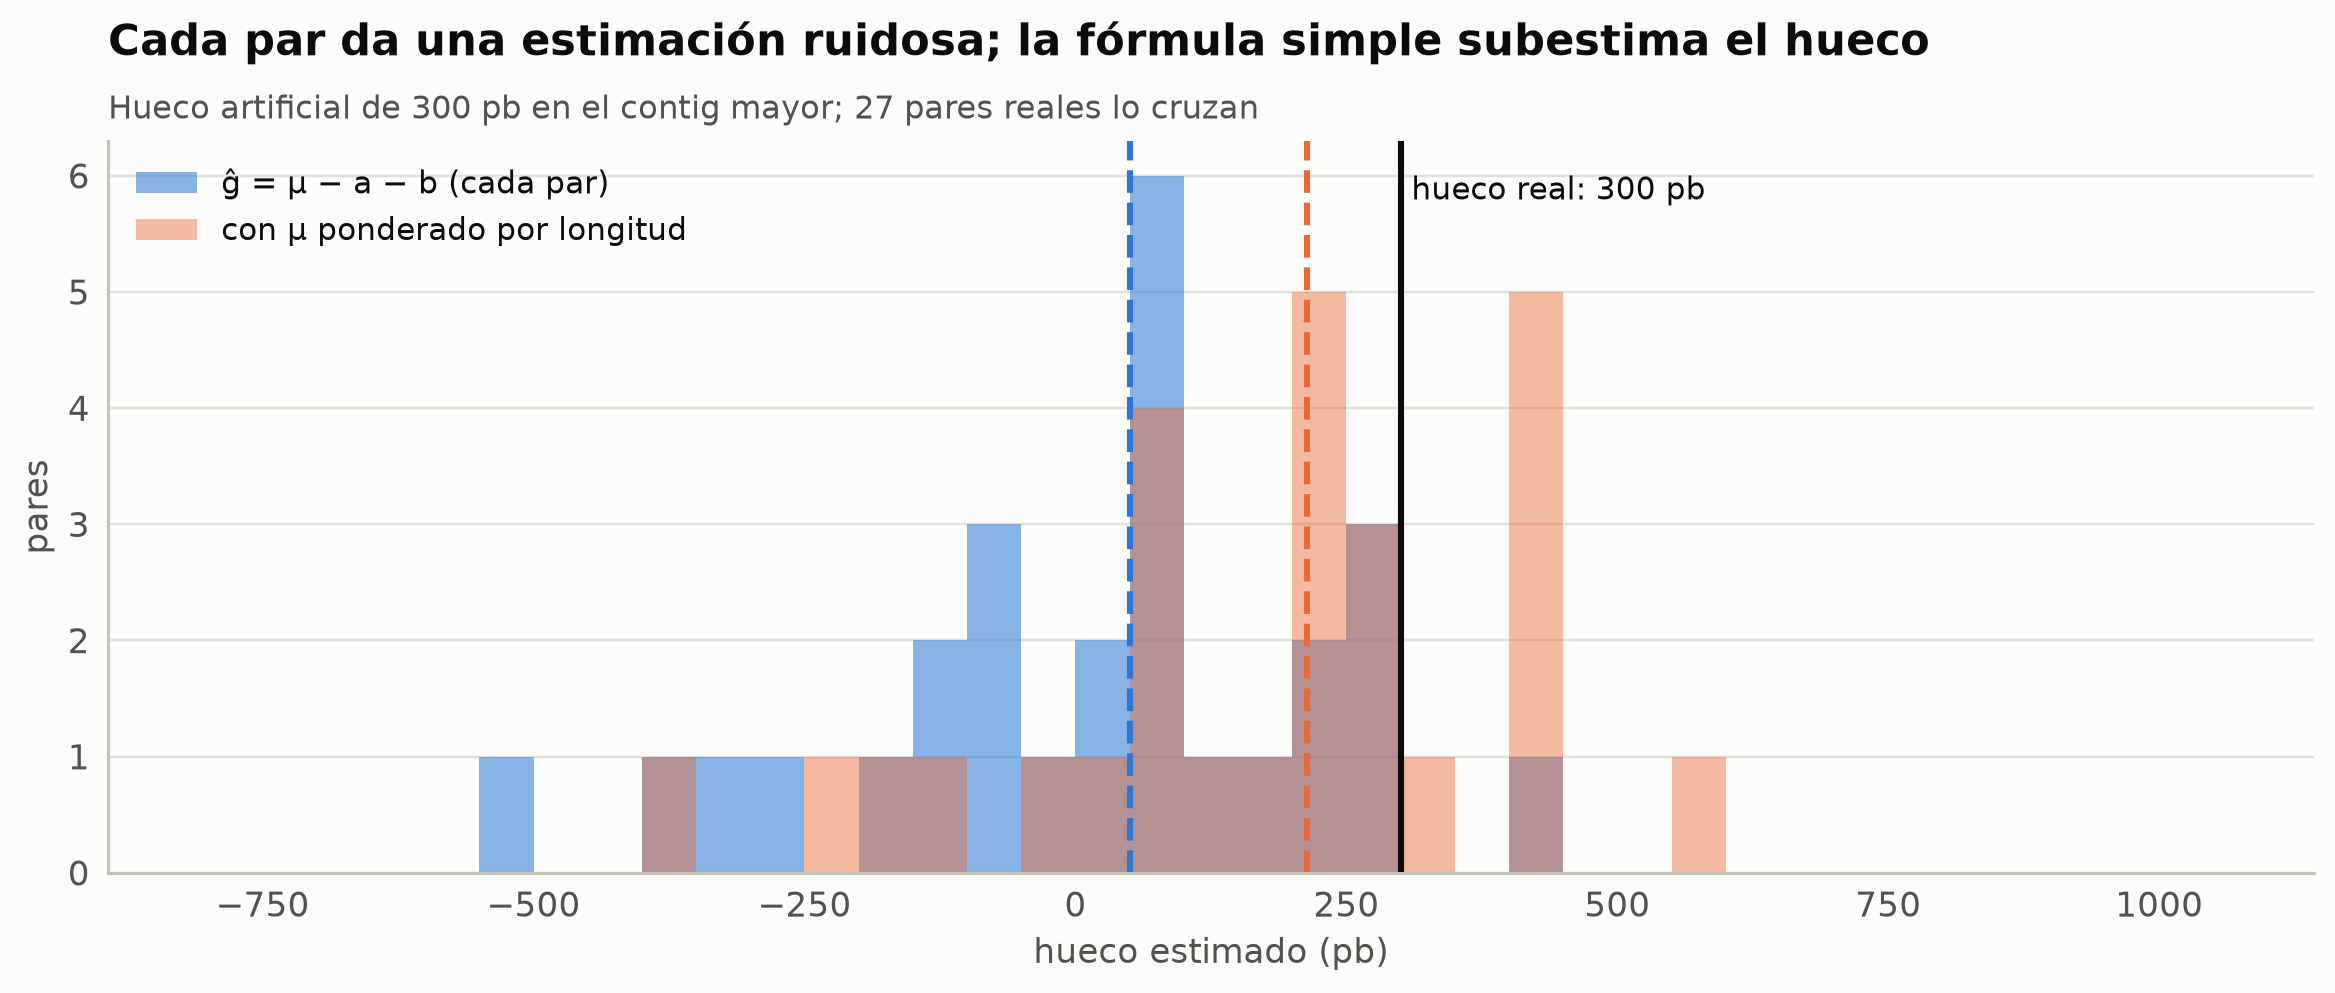

In [22]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
est, est_w = per_pair[300]
bins = np.arange(-800, 1100, 50)
ax.hist(est, bins=bins, color=ec.BLUE, alpha=0.55, label="ĝ = μ − a − b (cada par)")
ax.hist(est_w, bins=bins, color=ec.ORANGE, alpha=0.45, label="con μ ponderado por longitud")
ax.axvline(300, color=ec.INK, lw=2); ax.text(310, ax.get_ylim()[1] * 0.92, "hueco real: 300 pb", fontsize=10)
ax.axvline(np.median(est), color=ec.BLUE, ls="--"); ax.axvline(np.median(est_w), color=ec.ORANGE, ls="--")
ax.set_xlabel("hueco estimado (pb)"); ax.set_ylabel("pares")
ax.legend(loc="upper left", frameon=False)
ec.title(ax, "Cada par da una estimación ruidosa; la fórmula simple subestima el hueco",
         f"Hueco artificial de 300 pb en el contig mayor; {len(est)} pares reales lo cruzan")
plt.show()

> 🔎 **Qué observamos.** Tres lecciones de un experimento sencillo:
>
> 1. **Ruido.** Las estimaciones individuales se dispersan varios cientos de pares de bases (la $\sigma$ del inserto).
>    Promediar decenas de pares reduce el error, pero el tamaño de un tramo de `N` en un *scaffold* es siempre una
>    **estimación**.
> 2. **Sesgo.** La fórmula con $\mu$ simple **subestima** el hueco, y más cuanto mayor es. La razón es sutil: un
>    fragmento largo tiene más formas de "montarse" sobre el hueco que uno corto, así que los pares que lo cruzan están
>    **enriquecidos en insertos largos**, con $a+b$ mayor de lo típico. Usar la media ponderada por longitud,
>    $\mathbb{E}[I^2]/\mathbb{E}[I]$, reduce el sesgo, pero sólo en parte: con huecos pequeños acierta bastante,
>    y con huecos de 600–1 000 pb sigue subestimando, como muestra la tabla. Los programas de andamiaje modelan la distribución
>    completa del inserto por máxima verosimilitud.
> 3. **Alcance.** Cuantos más pares de bases faltan, menos pares cruzan el hueco; con 1 kb ya casi no quedan. Con esta
>    biblioteca, nada que mida más de ~1 kb (un operón *rrn*, un IS150 de 1,4 kb) puede saltarse.

### Paso 3: el grafo de andamiaje real

Volvamos a los *contigs* reales de la región y contemos los pares que unen extremos de *contigs* distintos (sólo
lecturas a menos de 1 kb del extremo, como exige la geometría).

In [23]:
n = len(cid) // 2
links = defaultdict(list)
short = lambda i: "N" + big_names[i].split("_")[1]
for p in np.nonzero(cross)[0]:
    ends, dists = [], []
    for r_ in (p, p + n):
        c_, s_, t_ = cid[r_], start[r_], same[r_]
        d_ = idx_ctg["lengths"][c_] - s_ if t_ else s_ + L            # distancia al extremo hacia el que apunta
        ends.append((short(c_), "fin" if t_ else "inicio")); dists.append(d_)
    if max(dists) < 1000:
        links[tuple(sorted(ends))].append(mu - sum(dists))
link_df = pd.DataFrame([{"extremo 1": f"{e[0][0]} ({e[0][1]})", "extremo 2": f"{e[1][0]} ({e[1][1]})",
                         "pares": len(v), "ĝ mediana (pb)": int(np.median(v))}
                        for e, v in links.items() if len(v) >= 5]).sort_values("pares", ascending=False)
lens_short = {short(i): len(s) for i, s in enumerate(big)}
covs_short = {short(i): float(re.search(r"cov_([\d.]+)", big_names[i]).group(1)) for i in range(len(big))}
print("Contigs:", ", ".join(f"{k} = {v:,} pb (cov {covs_short[k]:.0f})" for k, v in lens_short.items()))
print(link_df.to_string(index=False))

Contigs: N1 = 91,493 pb (cov 15), N2 = 57,186 pb (cov 16), N3 = 36,521 pb (cov 15), N4 = 36,077 pb (cov 16), N5 = 8,271 pb (cov 13), N6 = 7,632 pb (cov 15), N7 = 1,444 pb (cov 13), N8 = 1,376 pb (cov 58), N9 = 1,183 pb (cov 56), N10 = 1,116 pb (cov 54), N11 = 913 pb (cov 28), N12 = 707 pb (cov 1)
   extremo 1    extremo 2  pares  ĝ mediana (pb)
N10 (inicio)     N9 (fin)    185              10
   N10 (fin) N11 (inicio)    182            -251
   N11 (fin)  N8 (inicio)    179            -358
    N3 (fin)     N8 (fin)    114            -230
 N1 (inicio)  N9 (inicio)     89            -178
    N2 (fin)     N7 (fin)     76            -279
    N6 (fin)  N7 (inicio)     74            -263
 N4 (inicio)     N7 (fin)     56            -303
    N1 (fin)  N7 (inicio)     51            -224
 N3 (inicio)  N9 (inicio)     50             -90
 N6 (inicio)     N8 (fin)     37              29
 N5 (inicio)  N9 (inicio)     28             -41
   N10 (fin)  N8 (inicio)     22             209
    N4 (fin)    

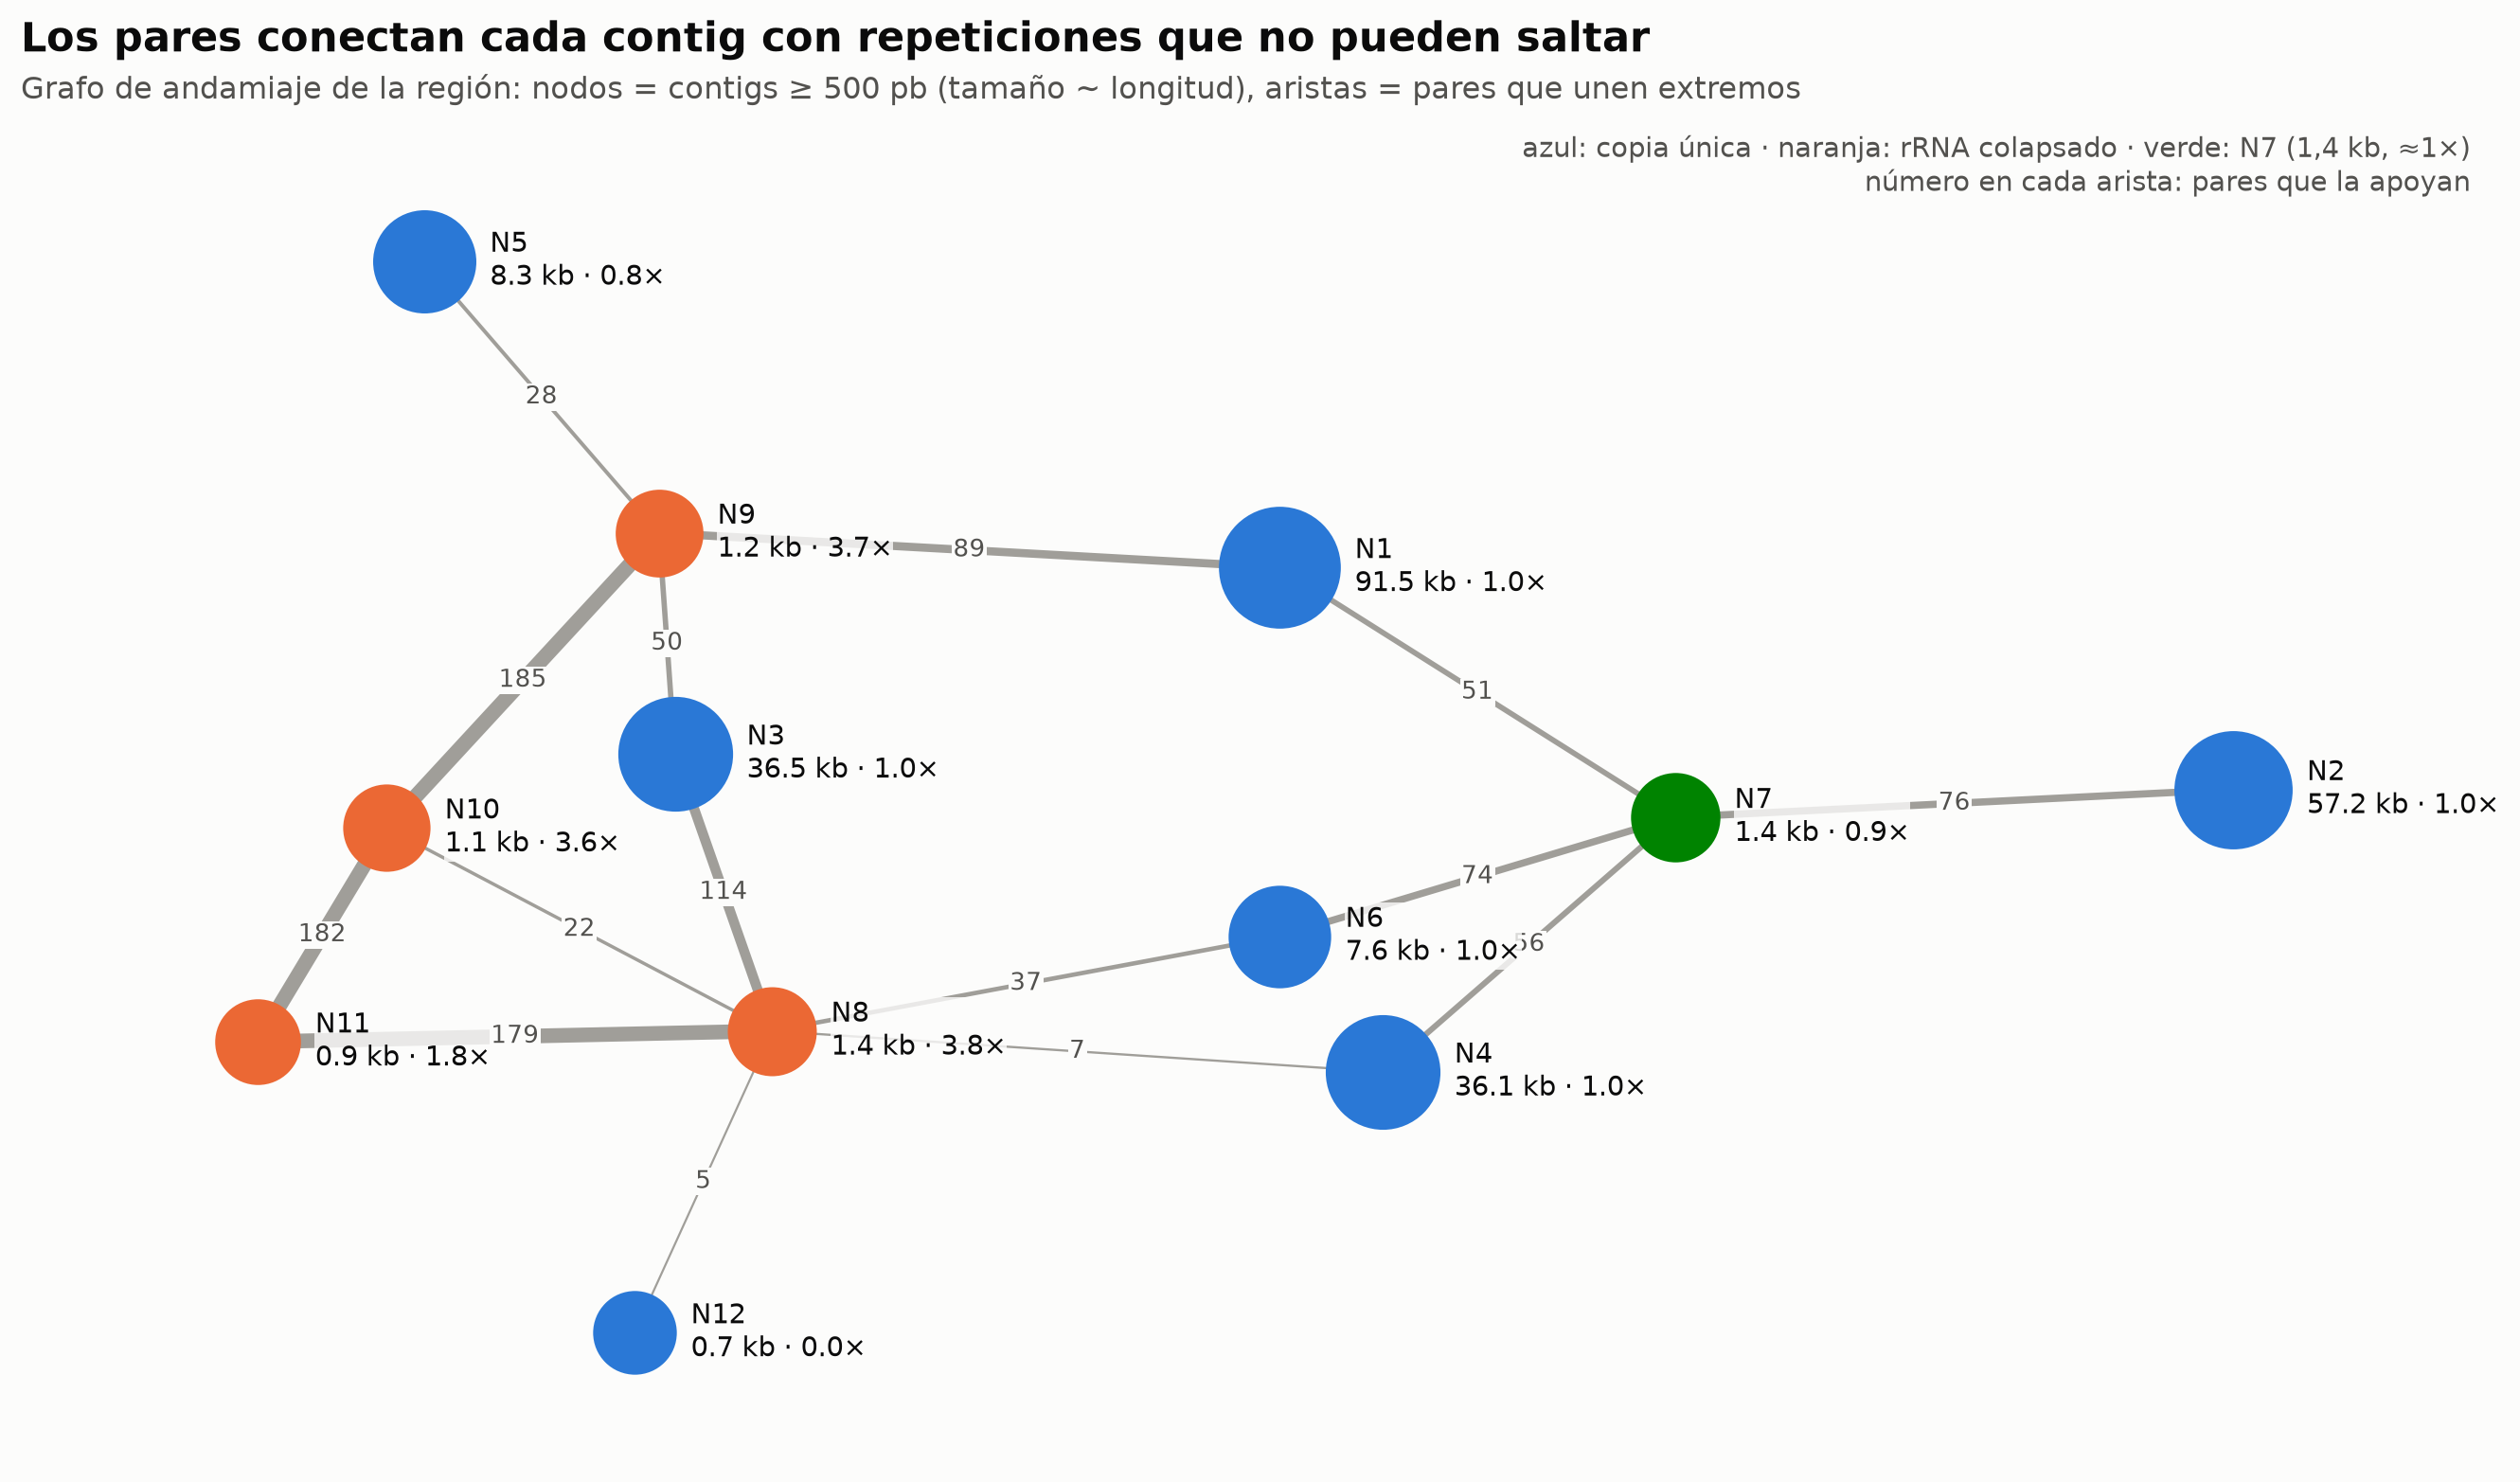

In [24]:
import networkx as nx_graph
Gs = nx_graph.Graph()
for _, r_ in link_df.iterrows():
    a_, b_ = r_["extremo 1"].split()[0], r_["extremo 2"].split()[0]
    if a_ != b_:
        w_ = Gs.get_edge_data(a_, b_, {"w": 0})["w"]
        Gs.add_edge(a_, b_, w=w_ + r_["pares"])
pos_ = nx_graph.spring_layout(Gs, seed=8, k=1.1, weight=None, iterations=300)
fig, ax = plt.subplots(figsize=(12, 7))
for a_, b_, d_ in Gs.edges(data=True):
    ax.plot(*zip(pos_[a_], pos_[b_]), color=ec.MUTED, lw=0.6 + d_["w"] / 40, alpha=0.8, zorder=1)
    mx, my = (pos_[a_] + pos_[b_]) / 2
    ax.text(mx, my, str(d_["w"]), fontsize=8.5, color=ec.INK_2, ha="center", va="center",
            bbox=dict(fc=ec.SURFACE, ec="none", pad=0.5))
for node, (x_, y_) in pos_.items():
    cv = covs_short[node] / np.median([covs_short[k] for k in lens_short if lens_short[k] >= 5000])
    col = ec.ORANGE if cv > 1.7 else (ec.GREEN if node == "N7" else ec.BLUE)
    size_ = 180 + 18 * np.log2(lens_short[node]) ** 1.6
    ax.scatter(x_, y_, s=size_, color=col, zorder=3, edgecolor="white")
    ax.annotate(f"{node}\n{lens_short[node] / 1e3:.1f} kb · {cv:.1f}×", (x_, y_), xytext=(np.sqrt(size_) / 2 + 5, 0),
                textcoords="offset points", ha="left", va="center", fontsize=9.5,
                bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.8, pad=0.3))
ax.text(1.0, 1.0, "azul: copia única · naranja: rRNA colapsado · verde: N7 (1,4 kb, ≈1×)\n"
        "número en cada arista: pares que la apoyan", transform=ax.transAxes, fontsize=9.5, color=ec.INK_2,
        ha="right", va="top")
ax.axis("off"); ax.margins(0.12)
ec.title(ax, "Los pares conectan cada contig con repeticiones que no pueden saltar",
         "Grafo de andamiaje de la región: nodos = contigs ≥ 500 pb (tamaño ~ longitud), aristas = pares que unen extremos")
plt.show()

> 🔎 **Qué observamos.** El grafo tiene dos "cruces de caminos":
>
> * Los *contigs* de rRNA (naranja) forman un grupo muy conectado con los extremos de varios *contigs* grandes: es
>   el operón colapsado. Tres entradas y tres salidas pasan por el mismo nudo, y como el operón (5 kb) es mucho más
>   largo que los insertos (~600 pb), ningún par dice qué entrada va con qué salida.
> * **N7**, un *contig* de 1,4 kb con cobertura **normal** (≈ 1×), se conecta con **cuatro** extremos de *contigs*
>   grandes. Un *contig* con cuatro vecinos es la firma de una **repetición de dos copias**: cada copia tiene su
>   entrada y su salida. Pero su cobertura de ≈1× parece contradecirlo... Guarde este misterio: lo resolveremos en la
>   sección 9 con la referencia en la mano.
>
> La mayoría de los $\widehat g$ de la tabla son negativos (hasta unos −350 pb): los *contigs* vecinos de SPAdes **se solapan** por
> construcción (comparten al menos $k-1$ bases del nodo en el que se ramifica el grafo), y la fórmula simple, como vimos,
> subestima.

## 9. Exactitud con QUAST y con nuestro propio alineador

### ¿Qué es un error de ensamblaje?

Cuando existe un genoma de referencia cercano, podemos medir la exactitud directamente alineando los *contigs* contra
él. **QUAST** (Gurevich *et al.*, 2013; Mikheenko *et al.*, 2018) es el estándar. Además de la contigüidad, calcula la
**fracción del genoma** cubierta, la **razón de duplicación**, los **desajustes** (*mismatches*) e ***indels*** por
cada 100 kb y, sobre todo, los **errores de ensamblaje** (*misassemblies*): puntos de un *contig* en los que el tramo
izquierdo y el derecho se alinean en la referencia

* a más de **1 kb** de distancia en la misma hebra (**recolocación**),
* en **hebras opuestas** (**inversión**), o
* en **cromosomas o replicones distintos** (**translocación**).

Con esos puntos QUAST corta los *contigs* y recalcula la contigüidad: el **NGA50** es el NG50 de los bloques
**alineados correctamente**, una medida que ya no premia las uniones falsas de la sección 7.

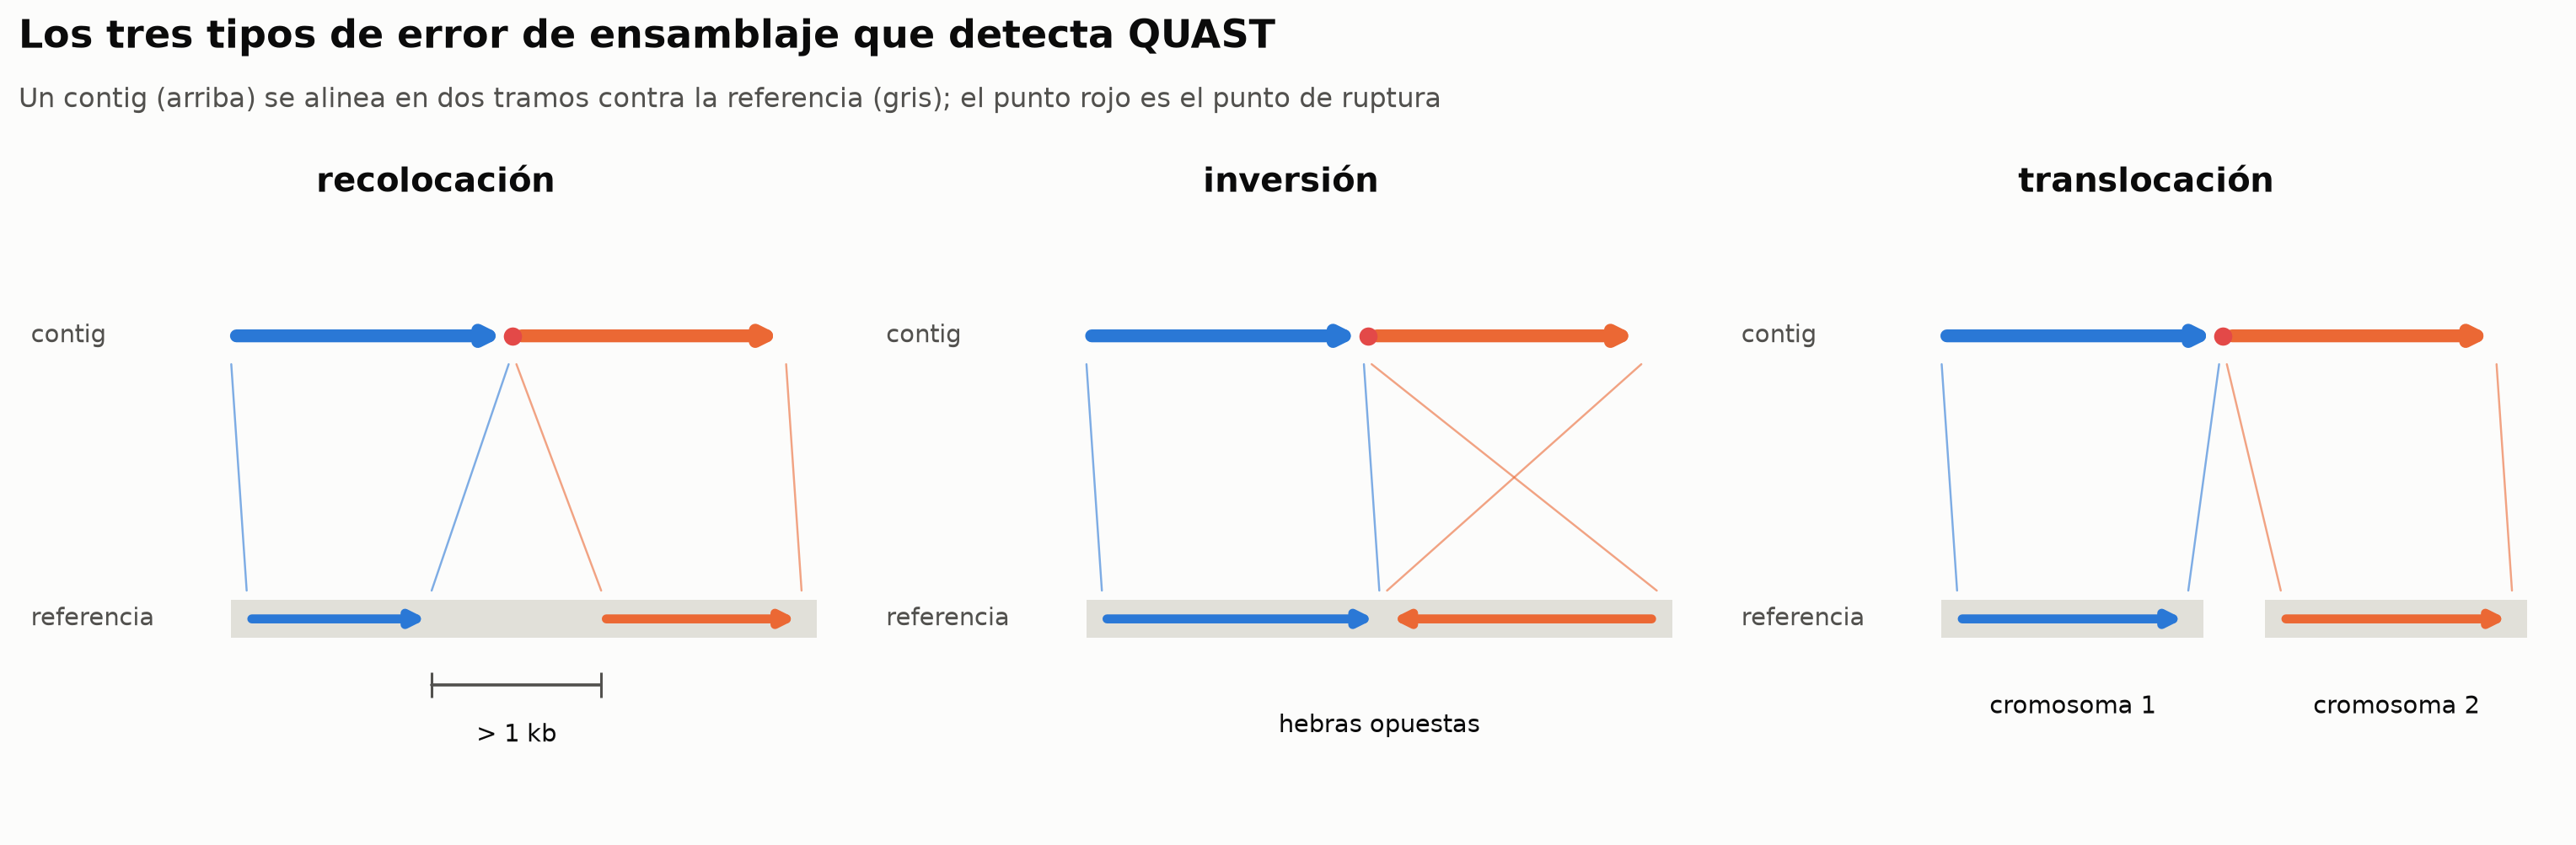

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
kinds = [("recolocación", "misma hebra, a > 1 kb"), ("inversión", "hebras opuestas"),
         ("translocación", "cromosomas distintos")]
for ax, (name, sub) in zip(axes, kinds):
    ax.set_xlim(-1.35, 4.0); ax.set_ylim(-0.9, 2.3); ax.axis("off")
    ax.set_title(name, fontsize=13, fontweight="bold", loc="center")
    ax.annotate("", (1.8, 1.7), (0, 1.7), arrowprops=dict(arrowstyle="-|>", lw=5, color=ec.BLUE))
    ax.annotate("", (3.6, 1.7), (1.85, 1.7), arrowprops=dict(arrowstyle="-|>", lw=5, color=ec.ORANGE))
    ax.scatter([1.825], [1.7], color=ec.RED, s=50, zorder=5)
    ax.text(-1.3, 1.7, "contig", va="center", fontsize=9.5, color=ec.INK_2)
    if name == "translocación":
        ax.add_patch(Rectangle((0, 0.1), 1.7, 0.2, color=ec.GRID)); ax.add_patch(Rectangle((2.1, 0.1), 1.7, 0.2, color=ec.GRID))
        segs = [((0.1, 1.6), ec.BLUE, (0, 1.8)), ((2.2, 3.7), ec.ORANGE, (1.85, 3.6))]
        ax.text(0.85, -0.3, "cromosoma 1", ha="center", fontsize=9.5); ax.text(2.95, -0.3, "cromosoma 2", ha="center", fontsize=9.5)
    else:
        ax.add_patch(Rectangle((0, 0.1), 3.8, 0.2, color=ec.GRID))
        if name == "recolocación":
            segs = [((0.1, 1.3), ec.BLUE, (0, 1.8)), ((2.4, 3.7), ec.ORANGE, (1.85, 3.6))]
            ax.plot([1.3, 2.4], [-0.15, -0.15], color=ec.INK_2, lw=1.2, marker="|", markersize=10)
            ax.text(1.85, -0.45, "> 1 kb", ha="center", fontsize=9.5)
        else:
            segs = [((0.1, 1.9), ec.BLUE, (0, 1.8)), ((3.7, 1.95), ec.ORANGE, (1.85, 3.6))]
            ax.text(1.9, -0.4, "hebras opuestas", ha="center", fontsize=9.5)
    ax.text(-1.3, 0.2, "referencia", va="center", fontsize=9.5, color=ec.INK_2)
    for (x0_, x1_), col, (c0_, c1_) in segs:
        ax.annotate("", (x1_, 0.2), (x0_, 0.2), arrowprops=dict(arrowstyle="-|>", lw=3.5, color=col))
        ax.plot([c0_, x0_], [1.55, 0.35], color=col, lw=0.8, alpha=0.6)
        ax.plot([c1_, x1_], [1.55, 0.35], color=col, lw=0.8, alpha=0.6)
ec.fig_title(fig, "Los tres tipos de error de ensamblaje que detecta QUAST",
             "Un contig (arriba) se alinea en dos tramos contra la referencia (gris); el punto rojo es el punto de ruptura")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Los tres errores tienen el mismo origen casi siempre: una **repetición atravesada por el
> camino equivocado** del grafo (Lección 8.2). El tramo azul llega hasta una copia de la repetición y el naranja sale
> de otra copia. Ojo: algunos "errores" son **variación estructural real** entre la muestra y la referencia (una
> inversión que el clon sí tiene). QUAST no puede distinguir ambos casos: eso le toca a usted.

### QUAST en vivo

```bash
quast.py contigs_500.fasta otro_ensamblaje.fasta -r referencia.fasta -t 2 --fast -o quast_cepa
```

`--fast` omite los gráficos, el informe HTML y el visor Icarus, pero conserva todas las métricas de la tabla. La celda
usa `quast.py` si está en el `PATH`; en Colab descarga QUAST 5.3.0 desde GitHub (29 MB), que la primera vez compila
su propia copia de minimap2 (~30 s). Si nada de esto funciona, carga el informe precalculado del curso.

In [26]:
QUAST_VER = "5.3.0"
QUAST_URL = f"https://github.com/ablab/quast/releases/download/quast_{QUAST_VER}/quast-{QUAST_VER}.tar.gz"

def ensure_quast():
    """Devuelve la orden para ejecutar QUAST (o None)."""
    if shutil.which("quast.py"):
        return "quast.py"
    if not IN_COLAB:
        return None
    try:
        qdir = os.path.join(WORK, f"quast-{QUAST_VER}")
        if not os.path.exists(qdir):
            tgz = os.path.join(WORK, "quast.tar.gz")
            urllib.request.urlretrieve(QUAST_URL, tgz)
            with tarfile.open(tgz) as tf:
                tf.extractall(WORK)
        return f"{sys.executable} {qdir}/quast.py"
    except Exception as err:
        print("⚠️ No se pudo instalar QUAST:", err)
        return None

QUAST = ensure_quast()
REF_REG = course_file(f"{REG}.fasta.gz")
PRE_FA = course_file(f"{REG}_spades_contigs.fasta.gz")
asm_files, asm_labels = [PRE_FA], ["precalculado"]
if live_contigs:
    asm_files.append(os.path.join(live_dir, "contigs.fasta")); asm_labels.append("en_vivo")
quast_df = None
if QUAST:
    try:
        out_q = os.path.join(WORK, "quast_region")
        _, qsec = sh(f"{QUAST} {' '.join(asm_files)} -l {','.join(asm_labels)} -r {REF_REG} -t 2 --fast -o {out_q}",
                     log=os.path.join(WORK, "quast_region.log"))
        quast_df = pd.read_csv(os.path.join(out_q, "report.tsv"), sep="\t", index_col=0)
        print(f"✔ QUAST terminó en {qsec:.0f} s")
    except Exception as err:
        print("⚠️ QUAST falló; uso el informe precalculado.\n", str(err)[-400:])
if quast_df is None:
    quast_df = pd.read_csv(io.BytesIO(course_bytes(f"{REG}_quast_report.tsv")), sep="\t", index_col=0)
    quast_df = quast_df[["contigs"]].rename(columns={"contigs": "precalculado"})
    print("Informe QUAST precalculado del curso (QUAST 5, contigs ≥ 500 pb)")

EXPLAIN = {
    "# contigs": "contigs ≥ 500 pb (umbral por defecto de QUAST)",
    "Largest contig": "longitud del contig más largo",
    "Total length": "suma de longitudes (A)",
    "N50": "sección 7", "NG50": "con G = longitud de la referencia", "L50": "sección 7",
    "auN": "ec. 08-aun",
    "# misassemblies": "recolocaciones + inversiones + translocaciones",
    "# local misassemblies": "rupturas pequeñas (< 1 kb) dentro de un contig",
    "# unaligned contigs": "enteros + parcialmente sin alinear",
    "Unaligned length": "bases de contigs que no alinean con la referencia",
    "Genome fraction (%)": "% de la referencia cubierta por algún contig",
    "Duplication ratio": "bases alineadas / bases de referencia cubiertas (1 = sin duplicaciones)",
    "# mismatches per 100 kbp": "diferencias de una base con la referencia",
    "# indels per 100 kbp": "inserciones y deleciones cortas",
    "NGA50": "NG50 de los bloques correctamente alineados",
}
show = quast_df.loc[[r for r in EXPLAIN if r in quast_df.index]].copy()
show["qué significa"] = [EXPLAIN[r] for r in show.index]
print(show.to_string())

$ quast.py ../data/REL606_3950k-4200k_spades_contigs.fasta.gz spades_live/contigs.fasta -l precalculado,en_vivo -r ../data/REL606_3950k-4200k.fasta.gz -t 2 --fast -o quast_region


✔ QUAST terminó en 1 s
                         precalculado     en_vivo                                                            qué significa
Assembly                                                                                                                  
# contigs                          12          18                           contigs ≥ 500 pb (umbral por defecto de QUAST)
Largest contig                  91493       91476                                            longitud del contig más largo
Total length                   243919      244342                                                   suma de longitudes (A)
N50                             57186       46489                                                                sección 7
NG50                            57186       46489                                        con G = longitud de la referencia
L50                                 2           2                                                                sec

> 🔎 **Qué observamos.** Cero errores de ensamblaje, 0,83 desajustes por 100 kb (dos bases en 240 kb) y ningún *indel*:
> los *contigs* son **exactos**. La fracción del genoma es ~95,7 %: faltan unos 10 kb de la región. Y aparece una cifra
> intrigante: ~4 kb de secuencia **no alineada** ("1 + 3 part": un *contig* entero y tres trozos de otros). ¿Son basura?
> ¿Contaminación? Vamos a responderlo con nuestras propias manos.

### Nuestro propio alineador de *contigs*

QUAST alinea con minimap2. Nosotros usaremos una versión mínima de la misma idea (Lección 7.2), suficiente para
*contigs* casi idénticos a la referencia:

1. **Anclas:** cada 31-mer del *contig* que aparece **una sola vez** en la referencia da un par (posición en el
   *contig* $q$, posición en la referencia $p$, hebra).
2. **Diagonales:** en la hebra directa, las anclas de un tramo colineal comparten $d = p - q$; en la inversa,
   $d = p + q$. Agrupamos anclas consecutivas con la misma diagonal (tolerancia de 30 pb, para admitir *indels*) en
   **bloques**.
3. **Errores de ensamblaje:** dos bloques consecutivos del mismo *contig*, ambos de **al menos 1 kb**, que saltan más de
   1 kb, cambian de hebra o de cromosoma. Exigimos 1 kb a los dos lados para no confundir un error con un tramo corto
   dentro de una repetición, donde las anclas "únicas" son poco fiables.
4. **Desajustes e *indels*:** dentro de cada bloque comparamos base a base el *contig* con la referencia en cada tramo
   de diagonal exacta; un cambio pequeño de diagonal entre tramos es un *indel*.

In [27]:
COMP_CODE = np.array([3, 2, 1, 0, 4], np.uint8)

def align_blocks(seq, idx, ref_arrs, tol=30, min_anchors=20):
    """Bloques colineales de un contig contra un índice de referencia (+ desajustes e indels por bloque)."""
    k = idx["k"]
    sa = to_codes(seq)
    c, f, ok = kmer_codes(sa, k)
    c, f, ok = c[0], f[0], ok[0]
    i, cnt = lookup(idx, c)
    u = np.nonzero((cnt == 1) & ok)[0]
    if len(u) == 0:
        return []
    q, p, rid = u, idx["pos"][i[u]], idx["ids"][i[u]]
    same = f[u] == idx["fw"][i[u]]
    d = np.where(same, p - q, p + q)
    cut = np.nonzero((np.diff(rid) != 0) | (np.diff(same) != 0) | (np.abs(np.diff(d)) > tol))[0] + 1
    blocks = []
    for a, b in zip(np.r_[0, cut], np.r_[cut, len(q)]):
        if b - a < min_anchors:
            continue
        ref = ref_arrs[rid[a]]
        mism = indel = compared = 0
        runs = np.nonzero(np.diff(d[a:b]) != 0)[0] + 1 + a
        for ra, rb in zip(np.r_[a, runs], np.r_[runs, b]):
            x = np.arange(q[ra], q[rb - 1] + k)
            dd = d[ra]
            if same[a]:
                y = ref[x + dd]
            else:
                y = COMP_CODE[ref[dd + k - 1 - x]]
            mism += int(np.sum(sa[x] != y)); compared += len(x)
        indel = len(runs)
        blocks.append(dict(q0=int(q[a]), q1=int(q[b - 1] + k), r0=int(p[a:b].min()), r1=int(p[a:b].max() + k),
                           strand="+" if same[a] else "−", ref=int(rid[a]), anchors=int(b - a),
                           mismatches=mism, indels=indel, compared=compared))
    return blocks

def hit_mask(seq, idx):
    """Posiciones del contig cubiertas por algún 31-mer presente en la referencia (único o repetido)."""
    k = idx["k"]
    c, f, ok = kmer_codes(to_codes(seq), k)
    _, cnt = lookup(idx, c[0])
    hit = np.flatnonzero((cnt > 0) & ok[0])
    mask = np.zeros(len(seq) + 1, int)
    np.add.at(mask, hit, 1); np.add.at(mask, hit + k, -1)
    return np.cumsum(mask)[:len(seq)] > 0

def misassemblies(blocks, min_len=1000, max_jump=1000):
    """Lista de errores de ensamblaje (QUAST-like) entre bloques consecutivos ≥ min_len."""
    bl = sorted([b for b in blocks if b["q1"] - b["q0"] >= min_len], key=lambda b: b["q0"])
    out = []
    for b1, b2 in zip(bl, bl[1:]):
        if b1["ref"] != b2["ref"]:
            out.append("translocación")
        elif b1["strand"] != b2["strand"]:
            out.append("inversión")
        else:
            exp = b1["r1"] + (b2["q0"] - b1["q1"]) if b1["strand"] == "+" else b1["r0"] - (b2["q0"] - b1["q1"])
            obs = b2["r0"] if b1["strand"] == "+" else b2["r1"]
            if abs(obs - exp) > max_jump:
                out.append("recolocación")
    return out

t0 = time.perf_counter()
idx_reg = build_index([region])
aln = {n: align_blocks(s, idx_reg, [ref_arr]) for n, s in pre_contigs.items() if len(s) >= 500}
print(f"Alineamiento de {len(aln)} contigs: {time.perf_counter() - t0:.1f} s\n")
rows, hitmasks = [], {}
for n, bl in aln.items():
    L_ = len(pre_contigs[n])
    hitmasks[n] = hit_mask(pre_contigs[n], idx_reg)
    rows.append(dict(contig=n.split("_cov")[0], longitud=L_, bloques_únicos=len(bl),
                     **{"en referencia (anclas únicas)": ", ".join(f"{b['r0'] + 1:,}–{b['r1']:,} ({b['strand']})"
                                                                   for b in bl) or "— (sólo repetido o ausente)"},
                     **{"sin ningún 31-mer en la región (pb)": int((~hitmasks[n]).sum())}))
aln_df = pd.DataFrame(rows)
print(aln_df.to_string(index=False))

Alineamiento de 12 contigs: 0.0 s

             contig  longitud  bloques_únicos            en referencia (anclas únicas)  sin ningún 31-mer en la región (pb)
NODE_1_length_91493     91493               2  201,306–201,440 (+), 69,113–160,239 (+)                                   79
NODE_2_length_57186     57186               1                             1–56,277 (+)                                  909
NODE_3_length_36521     36521               1                      201,547–237,973 (+)                                    0
NODE_4_length_36077     36077               1                      160,235–196,189 (+)                                   75
 NODE_5_length_8271      8271               2 242,808–250,000 (+), 247,483–247,548 (−)                                  965
 NODE_6_length_7632      7632               1                        56,279–63,666 (−)                                   76
 NODE_7_length_1444      1444               0              — (sólo repetido o ausente)           

In [28]:
cov_ref = np.zeros(G_reg, bool)
mm = ind = comp = 0
mis_all = []
for n, bl in aln.items():
    for b in bl:
        cov_ref[b["r0"]:b["r1"]] = True
        mm += b["mismatches"]; ind += b["indels"]; comp += b["compared"]
    mis_all += misassemblies(bl)
unal = int(aln_df["sin ningún 31-mer en la región (pb)"].sum())
cov_unique = cov_ref.mean()
for n in aln:                                   # contigs repetidos (rRNA): sus 31-mers cubren todas las copias
    c_, _, ok_ = kmer_codes(to_codes(pre_contigs[n]), K_ALN)
    i_, cnt_ = lookup(idx_reg, c_[0][ok_[0]])
    for ii, nn in zip(i_[cnt_ > 1], cnt_[cnt_ > 1]):
        for pp in idx_reg["pos"][ii:ii + nn]:
            cov_ref[pp:pp + K_ALN] = True
ours = {"# misassemblies": len(mis_all), "Unaligned length": unal,
        "Genome fraction (%)": round(100 * cov_ref.mean(), 3),
        "# mismatches per 100 kbp": round(1e5 * mm / comp, 2), "# indels per 100 kbp": round(1e5 * ind / comp, 2)}
cmp_df = pd.DataFrame({"QUAST": [quast_df.loc[k_, "precalculado"] for k_ in ours], "nuestro alineador": list(ours.values())},
                      index=list(ours))
print(cmp_df.to_string())
print(f"\nDesajustes encontrados: {mm} en {comp:,} bases comparadas · indels: {ind}")
print(f"Fracción del genoma sólo con anclas únicas: {cov_unique:.2%} (sin contar los operones rrn colapsados)")

                           QUAST  nuestro alineador
# misassemblies                0              0.000
Unaligned length            4017           4197.000
Genome fraction (%)       95.726             99.336
# mismatches per 100 kbp    0.83              0.430
# indels per 100 kbp        0.00              0.000

Desajustes encontrados: 1 en 235,172 bases comparadas · indels: 0
Fracción del genoma sólo con anclas únicas: 94.04% (sin contar los operones rrn colapsados)


> 🔎 **Qué observamos.** Con unas 60 líneas de NumPy reproducimos lo esencial de QUAST: ningún error de ensamblaje,
> ~4 kb de secuencia sin ningún 31-mer en la región (QUAST: 4 017 pb) y del orden de un desajuste por cada 100–200 kb.
> La **fracción del genoma** enseña algo interesante sobre las repeticiones: con anclas únicas cubrimos ~94 %,
> porque los operones *rrn* no tienen ningún 31-mer único; si dejamos que el *contig* de rRNA colapsado "cubra" las
> **tres** copias que representa, subimos a ~99 %. QUAST queda en medio (95,7 %) porque asigna cada *contig* ambiguo a
> **una** sola de sus copias. Tres respuestas razonables a la pregunta "¿qué parte del genoma está en el ensamblaje?",
> según cómo se cuenten las repeticiones colapsadas. Otras diferencias pequeñas son esperables: QUAST extiende los
> alineamientos base a base con programación dinámica; nosotros sólo usamos anclas exactas.

### El diagrama de puntos (*dot-plot*)

La forma clásica de mirar un ensamblaje contra una referencia: cada ancla es un punto (posición en los *contigs*
concatenados, posición en la referencia). Un *contig* correcto es un segmento diagonal; una inversión, un segmento
con pendiente negativa; un error, un salto.

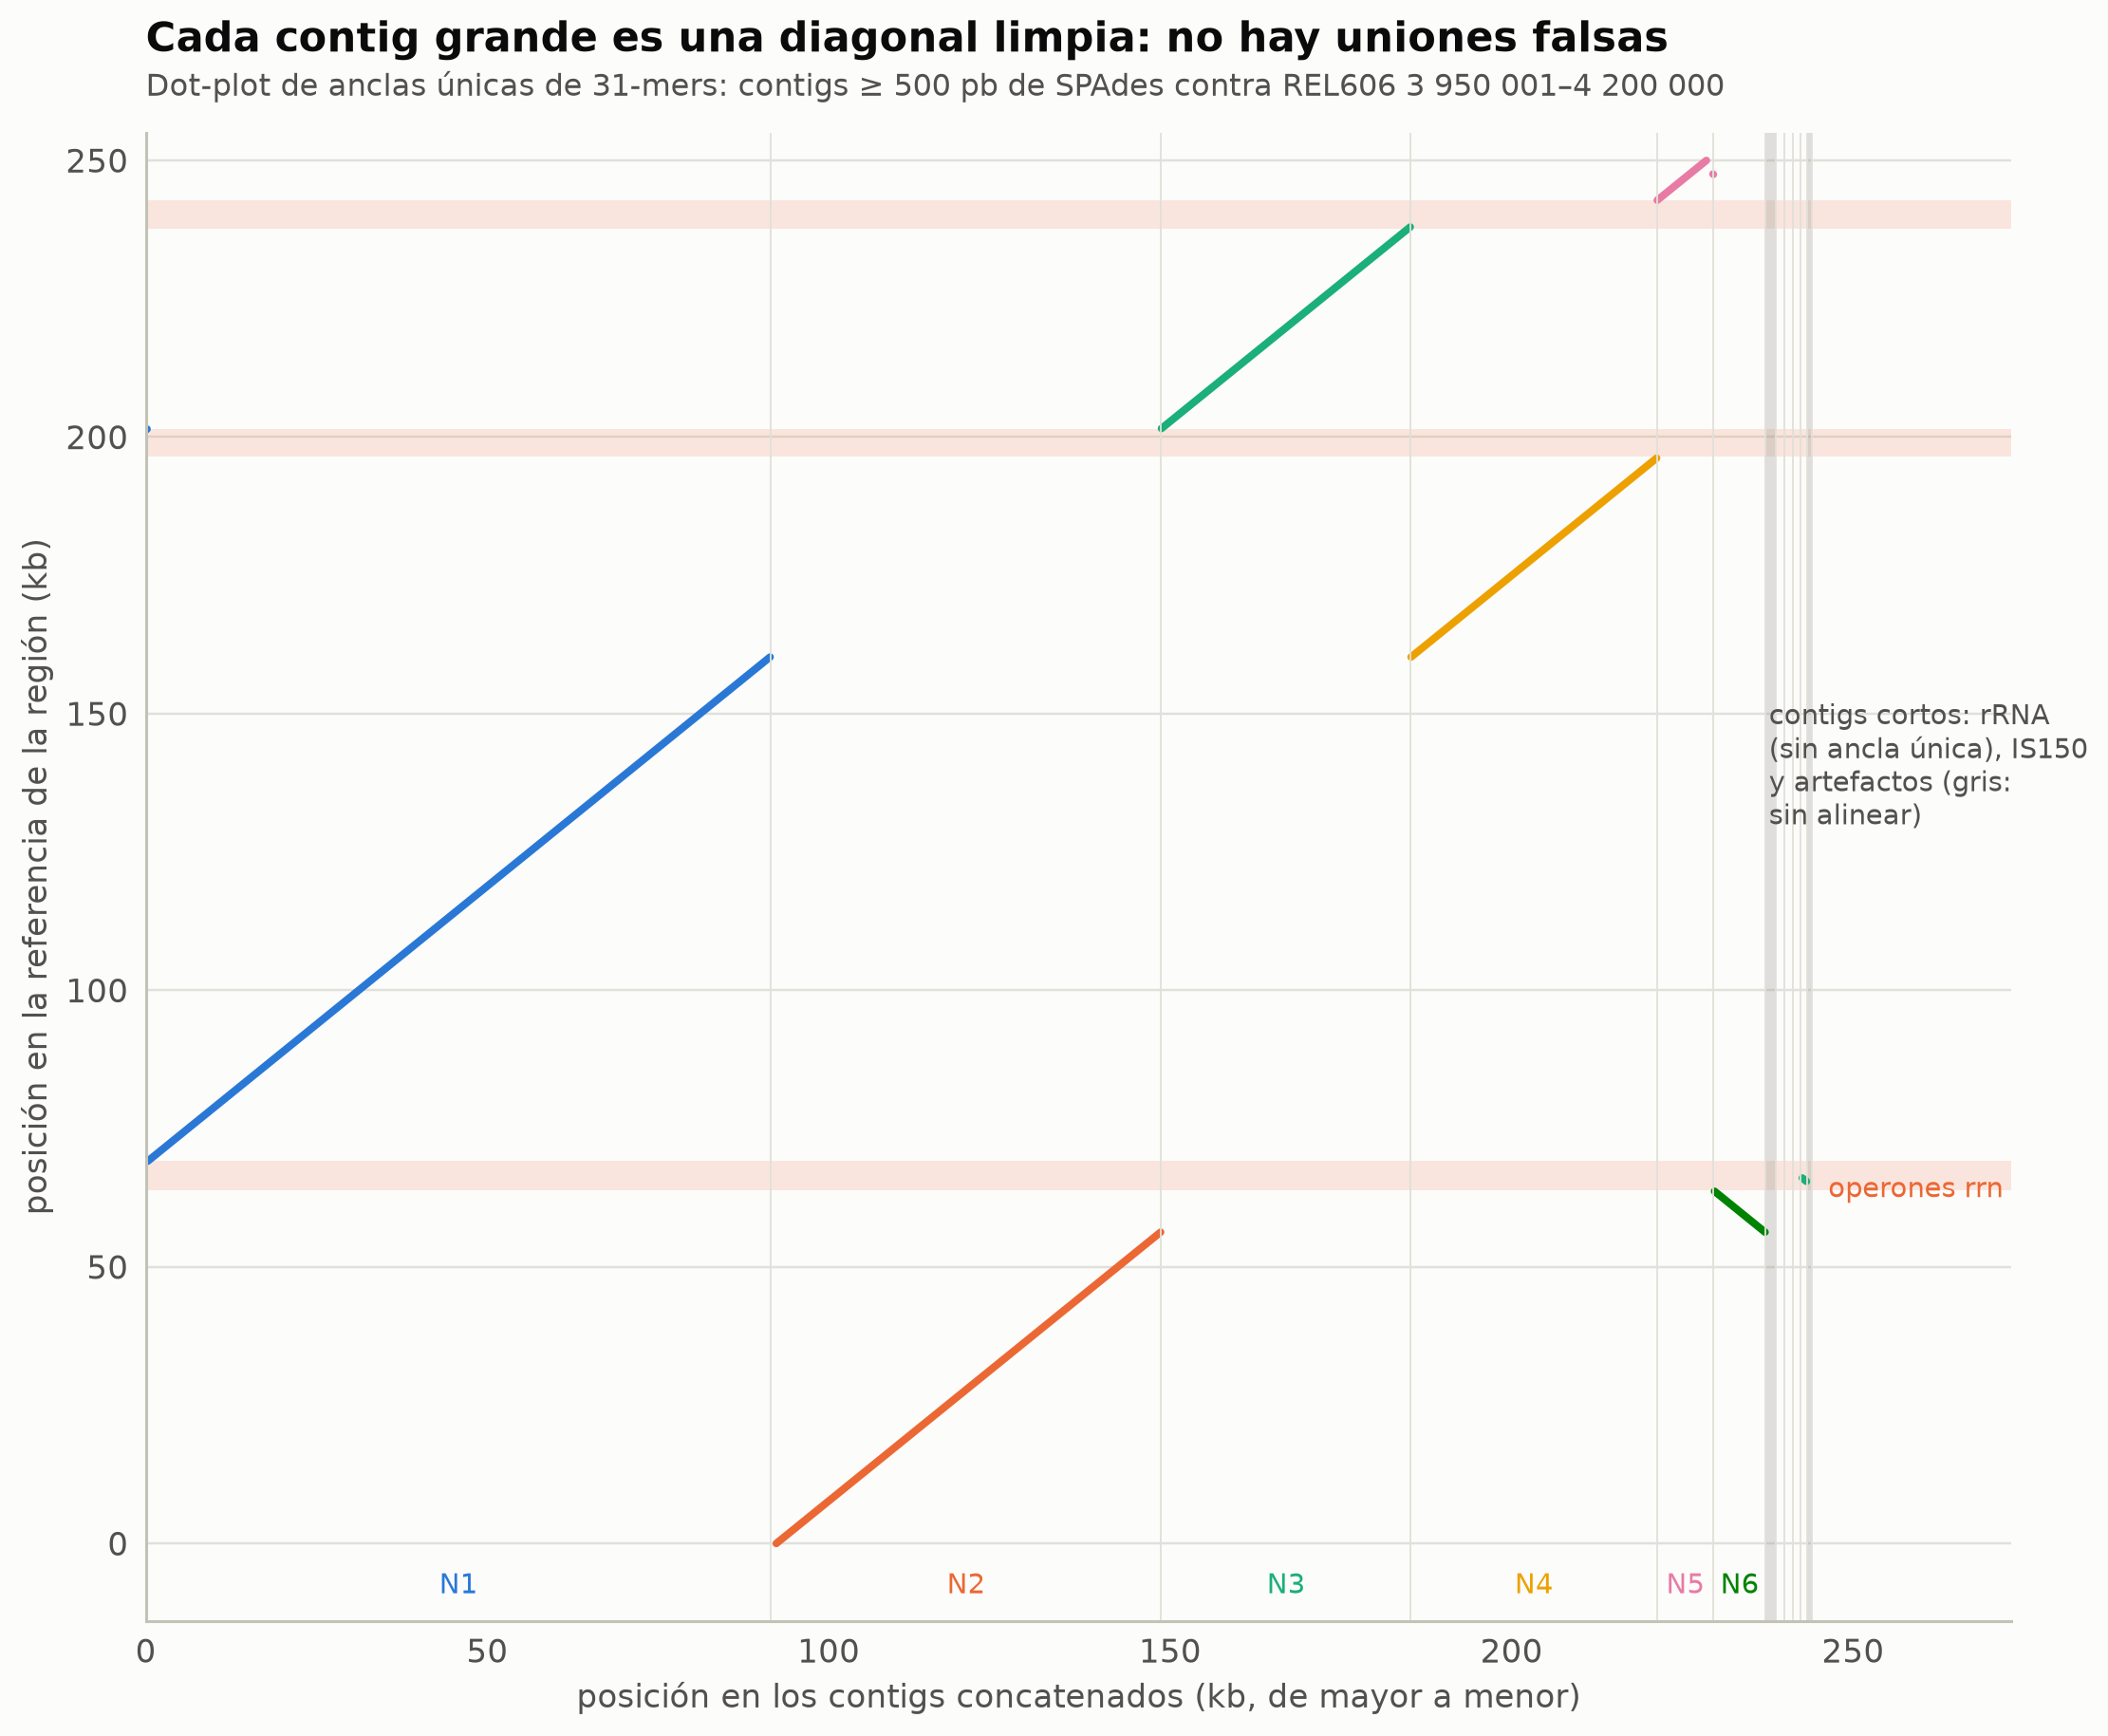

In [29]:
order = [n for n in sorted(aln, key=lambda n: -len(pre_contigs[n]))]
offs = np.cumsum([0] + [len(pre_contigs[n]) for n in order])
rrn = feat[(feat.type == "rRNA") & (feat.start >= REG_START) & (feat.end < REG_START + G_reg)].sort_values("start")
operons = []
for s_, e_ in zip(rrn.start - REG_START, rrn.end - REG_START + 1):
    if operons and s_ - operons[-1][1] < 1000:
        operons[-1][1] = e_
    else:
        operons.append([s_, e_])
fig, ax = plt.subplots(figsize=(10, 8.2))
for (s_, e_) in operons:
    ax.axhspan(s_ / 1e3, e_ / 1e3, color=ec.ORANGE, alpha=0.15, lw=0)
ax.text(offs[-1] / 1e3 * 1.01, operons[0][0] / 1e3, "operones rrn", color=ec.ORANGE, fontsize=9.5, va="center")
for j, n in enumerate(order):
    col = ec.CATEGORICAL[j % 8]
    for b in aln[n]:
        qq = np.array([b["q0"], b["q1"]]); rr = np.array([b["r0"], b["r1"]]) if b["strand"] == "+" else np.array([b["r1"], b["r0"]])
        ax.plot((offs[j] + qq) / 1e3, rr / 1e3, color=col, lw=2.6)
    if not aln[n] and hitmasks[n].mean() < 0.5:
        ax.axvspan(offs[j] / 1e3, offs[j + 1] / 1e3, color=ec.MUTED, alpha=0.25, lw=0)
    if len(pre_contigs[n]) > 7000:
        ax.text((offs[j] + offs[j + 1]) / 2e3, -9, f"N{n.split('_')[1]}", ha="center", fontsize=9.5, color=col)
for x in offs:
    ax.axvline(x / 1e3, color=ec.GRID, lw=0.6)
ax.text(offs[6] / 1e3 + 0.5, 130, "contigs cortos: rRNA\n(sin ancla única), IS150\ny artefactos (gris:\nsin alinear)",
        fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, offs[-1] / 1e3 * 1.12); ax.set_ylim(-14, 255)
ax.set_xlabel("posición en los contigs concatenados (kb, de mayor a menor)")
ax.set_ylabel("posición en la referencia de la región (kb)")
ec.title(ax, "Cada contig grande es una diagonal limpia: no hay uniones falsas",
         "Dot-plot de anclas únicas de 31-mers: contigs ≥ 500 pb de SPAdes contra REL606 3 950 001–4 200 000")
plt.show()

> 🔎 **Qué observamos.** Seis diagonales limpias, cinco en la hebra directa y una inversa (N6: SPAdes elige al azar en
> qué hebra escribe cada *contig*; una hebra inversa **no** es un error). Los huecos entre diagonales, en el eje
> vertical, caen **justo** sobre las bandas naranjas de los operones *rrn*... pero no todos: hay dos cortes lejos de
> cualquier operón. La animación siguiente coloca los *contigs* uno a uno sobre la referencia para verlo mejor.

![Los contigs se colocan sobre la referencia y dejan ver dónde se rompe el ensamblaje](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.3_contigs_mosaico.gif)

*Los contigs se colocan sobre la referencia y dejan ver dónde se rompe el ensamblaje*

In [30]:
placed = []
for n in order:
    bl = [b for b in aln[n] if b["q1"] - b["q0"] >= 1000]
    placed.append((n, bl))
_bl = sorted([b for _, bl in placed for b in bl], key=lambda b: b["r0"])
abut = [b1["r1"] for b1, b2 in zip(_bl, _bl[1:]) if abs(b2["r0"] - b1["r1"]) < 50]   # cortes sin hueco
fig, ax = plt.subplots(figsize=(12.5, 4.8))
frames_ = [j for j in range(len(placed)) for _ in range(3)] + [len(placed) - 1] * 10

def draw_tiling(f):
    j = frames_[f]
    ax.clear()
    ax.add_patch(Rectangle((0, -0.25), G_reg / 1e3, 0.5, color=ec.GRID))
    for (s_, e_) in operons:
        ax.add_patch(Rectangle((s_ / 1e3, -0.25), (e_ - s_) / 1e3, 0.5, color=ec.ORANGE, alpha=0.8))
    ax.text(0, -0.75, "referencia REL606 (región de 250 kb) · naranja: operones rrn", fontsize=9.5, color=ec.INK_2)
    orphans = []
    for jj in range(j + 1):
        n, bl = placed[jj]
        col = ec.CATEGORICAL[jj % 8]
        if not bl:
            kind = "rRNA colapsado" if hitmasks[n].mean() >= 0.5 else "sin sitio"
            orphans.append(f"N{n.split('_')[1]} ({kind})")
            continue
        for b in bl:
            y = 1 + (jj % 2) * 0.8
            x0, x1 = (b["r0"], b["r1"]) if b["strand"] == "+" else (b["r1"], b["r0"])
            ax.annotate("", (x1 / 1e3, y), (x0 / 1e3, y), arrowprops=dict(arrowstyle="-|>", lw=4 if jj == j else 3,
                                                                          color=col, alpha=1 if jj == j else 0.75))
            ax.text((b["r0"] + b["r1"]) / 2e3, y + 0.25, f"N{n.split('_')[1]}", ha="center", fontsize=9.5, color=col)
    if f >= len(frames_) - 8:
        for x_ in abut:
            ax.scatter(x_ / 1e3, 0.45, marker="v", s=90, color=ec.GREEN, zorder=5)
            ax.text(x_ / 1e3, 0.62, "corte sin hueco", ha="center", fontsize=8.5, color=ec.GREEN)
    n, bl = placed[j]
    info = (f"N{n.split('_')[1]}: {len(pre_contigs[n]):,} pb → " +
            (", ".join(f"{b['r0'] + 1:,}–{b['r1']:,} ({b['strand']})" for b in bl) if bl else
             ("repetido: encaja en las 3 copias del rRNA" if hitmasks[n].mean() >= 0.5 else "sin sitio en la región")))
    ax.text(0, 3.05, info, fontsize=11, color=ec.INK)
    ax.text(G_reg / 1e3, 2.62, "sin sitio único: " + (", ".join(orphans) if orphans else "—"), fontsize=9,
            color=ec.INK_2, ha="right")
    ax.set_xlim(-2, G_reg / 1e3 + 2); ax.set_ylim(-1, 3.4); ax.set_yticks([])
    ax.set_xlabel("posición en la región (kb)")
    ax.set_title("Los contigs se colocan sobre la referencia: los huecos delatan las repeticiones",
                 loc="left", fontsize=13, fontweight="bold")

draw_tiling(len(frames_) - 1)
plt.tight_layout()
ec.animate(fig, draw_tiling, frames=len(frames_), interval=300, name="8.3_contigs_mosaico")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### ¿Dónde y por qué se rompe el ensamblaje?

Recorramos la referencia de izquierda a derecha y anotemos cada **corte** entre bloques consecutivos: dónde cae, cuánto
falta y qué hay en la anotación de REL606 en ese punto.

In [31]:
blk = sorted([dict(b, contig=f"N{n.split('_')[1]}") for n, bl in aln.items() for b in bl if b["q1"] - b["q0"] >= 1000],
             key=lambda b: b["r0"])
feat_reg = feat[(feat.end >= REG_START) & (feat.start < REG_START + G_reg)].copy()
feat_reg["s"], feat_reg["e"] = feat_reg.start - REG_START, feat_reg.end - REG_START + 1

def what_is_there(a, b, pad=50):
    hit = feat_reg[(feat_reg.e >= a - pad) & (feat_reg.s <= b + pad)]
    if (hit.type == "rRNA").any():
        return "operón rrn (" + ", ".join(sorted(set(hit[hit.type == "rRNA"]["product"].str.split().str[0]))) + ")"
    return ", ".join(f"{g or lt} ({p[:38]})" for g, lt, p in zip(hit.gene.fillna(""), hit.locus_tag, hit["product"])) or "intergénico"

breaks = []
for b1, b2 in zip(blk, blk[1:]):
    gap = b2["r0"] - b1["r1"]
    breaks.append(dict(entre=f"{b1['contig']} | {b2['contig']}", posición_región=b1["r1"],
                       posición_REL606=b1["r1"] + REG_START - 1, hueco_pb=gap,
                       anotación=what_is_there(b1["r1"], b2["r0"])))
breaks_df = pd.DataFrame(breaks)
print(breaks_df.to_string(index=False))

  entre  posición_región  posición_REL606  hueco_pb                                     anotación
N2 | N6            56277          4006277         1      fadA (acetyl-CoA C-acyltransferase FadA)
N6 | N1            63666          4013666      5446                     operón rrn (16S, 23S, 5S)
N1 | N4           160239          4110239        -5 metL (bifunctional aspartate kinase/homoseri)
N4 | N3           196189          4146189      5357                     operón rrn (16S, 23S, 5S)
N3 | N5           237973          4187973      4834                     operón rrn (16S, 23S, 5S)


Tres cortes dejan un hueco de ~5 kb exactamente sobre un operón *rrn*: el grafo no puede decidir qué entrada del
operón colapsado va con qué salida (sección 8). Pero hay **dos cortes sin hueco** (hueco ≈ 0) en medio de genes de
copia única. En la referencia allí no hay ninguna repetición. ¿Por qué se detuvo SPAdes?

> 🤔 **Antes de ejecutar, prediga.** Si el ensamblador se detiene donde la referencia no tiene nada especial, el
> problema puede no estar en el ensamblador sino en... ¿qué?

Miremos las propias lecturas: buscamos las que contienen los 25 pb de la referencia justo antes de cada corte y
leemos qué viene después.

In [32]:
comp_tbl = str.maketrans("ACGTN", "TGCAN")
rc = lambda s: s.translate(comp_tbl)[::-1]
reads_both = r1 + r2
short_ctgs = {f"N{n.split('_')[1]}": s for n, s in pre_contigs.items() if 500 <= len(s) < 5000}

def junction_reads(pos, flank=25, look=40):
    """Lecturas que contienen los 25 pb de referencia previos al corte: ¿qué secuencia sigue?"""
    left = region[pos - flank:pos]
    after = Counter()
    for s in reads_both:
        for ss in (s, rc(s)):
            i_ = ss.find(left)
            if i_ >= 0 and i_ + flank + look <= len(ss):
                after[ss[i_ + flank:i_ + flank + look]] += 1
    return after

for _, row in breaks_df[breaks_df.hueco_pb.abs() < 100].iterrows():
    pos = int(row.posición_región)
    after = junction_reads(pos)
    ref_next = region[pos:pos + 40]
    print(f"Corte {row.entre} en REL606 {row.posición_REL606:,} ({row.anotación})")
    print(f"   referencia sigue con : {ref_next}")
    for seq_, n_ in after.most_common(3):
        where = [c for c, cs in short_ctgs.items() if seq_[5:35] in cs or seq_[5:35] in rc(cs)]
        tag = "= referencia" if seq_ == ref_next else ("= contig " + ", ".join(where) if where else "otra")
        print(f"   {n_:3d} lecturas siguen: {seq_}  {tag}")

Corte N2 | N6 en REL606 4,006,277 (fadA (acetyl-CoA C-acyltransferase FadA))
   referencia sigue con : GCTTCGAGGCCGGAACCGGGCCGTAACCCATAATCGATGG
    24 lecturas siguen: CTTTGTACTGCACCCATTTTGTTGGACGATGAAATGGAAT  = contig N7
     1 lecturas siguen: CTTTGTAGTGCACCCATTTTGTTGGACGATGTAATGGAAT  otra
Corte N1 | N4 en REL606 4,110,239 (metL (bifunctional aspartate kinase/homoseri))
   referencia sigue con : GCGCTTTTGTCAGCGATCTGGAACGCCTGGCGGCGTTGCT
    34 lecturas siguen: TGTGTACTGACCCCAAAAAGTTGGACAGTTAAACACGAGG  = contig N7
     1 lecturas siguen: TGTGTACTGACCCAAAAAAGTTGGACAGTTAAACACGAGG  otra


> 🔎 **Qué observamos.** En ambos cortes, **ninguna** lectura continúa como la referencia: todas continúan con la
> secuencia de **N7**, el *contig* de 1,4 kb que QUAST declaró "no alineado". El clon de Lenski tiene en esos dos sitios
> un **inserto** que su ancestro REL606 no tiene. En la sección siguiente identificamos qué es N7: es un
> **elemento IS150**, una secuencia de inserción de 1 443 pb que en el experimento de Lenski es una de las principales
> fuentes de mutaciones.
>
> Así se resuelve el misterio de la sección 8: N7 tiene cuatro vecinos porque el clon tiene **dos copias nuevas** del
> IS150 en esta región (una dentro de *fadA* y otra dentro de *metL*, según la anotación de la tabla), y las dos se
> colapsan en un solo *contig*, igual que los operones *rrn*. Su cobertura parece de copia única por un artefacto del
> reclutamiento: las lecturas que caen enteramente dentro de un IS150 se mapearon a las copias de IS150 de otras partes
> del genoma, fuera de la región, y sólo entraron aquí las que tienen a su compañera en la secuencia vecina.
>
> **Moraleja:** un ensamblaje *de novo* no "hereda" los prejuicios de la referencia. Lo que QUAST cuenta como
> "no alineado" puede ser **biología nueva**.

### ¿De dónde vienen los ~4 kb "no alineados"?

Si esos trozos existen en el genoma del ancestro, deberían aparecer en **otras partes** de REL606. Construimos el
índice de 31-mers del cromosoma completo (4,6 Mb; tarda unos segundos) y alineamos contra él cada tramo sin alinear.

In [33]:
t0 = time.perf_counter()
genome = next(iter(read_fasta(course_bytes("NC_012967.1.fasta.gz")).values()))
genome_arr = to_codes(genome)
assert len(genome) == G_REL606
idx_gen = build_index([genome])
print(f"Índice de REL606: {len(idx_gen['codes']):,} 31-mers · {time.perf_counter() - t0:.1f} s")

def all_hits(seq, idx, k=K_ALN, step=25):
    """Todas las posiciones (también repetidas) de los 31-mers de seq, muestreados cada `step` pb."""
    c, f, ok = kmer_codes(to_codes(seq), k)
    c = c[0][ok[0]][::step]
    i, cnt = lookup(idx, c)
    pos = [idx["pos"][ii:ii + nn] for ii, nn in zip(i, cnt)]
    return np.concatenate(pos) if pos else np.array([], int), float(np.mean(cnt > 0)), float(np.mean(cnt))

def feature_near(p, window=300):
    hit = feat[(feat.end >= p - window) & (feat.start <= p + window)]
    return "; ".join(sorted(set(f"{g or t} ({pr[:34]})" for g, t, pr in zip(hit.gene.fillna(""), hit.type, hit["product"]))))[:90] or "—"

rows = []
for n, bl in aln.items():
    s = pre_contigs[n]
    covered = hitmasks[n]
    # tramos sin ningún 31-mer de la región, de más de 50 pb
    edges = np.flatnonzero(np.diff(np.r_[0, (~covered).astype(int), 0]))
    for a, b_ in zip(edges[::2], edges[1::2]):
        if b_ - a < 50:
            continue
        pos, frac, mult = all_hits(s[a:b_], idx_gen)
        centers = np.unique((pos // 5000) * 5000)
        rows.append({"contig": f"N{n.split('_')[1]}", "tramo": f"{a + 1}–{b_}", "pb": b_ - a,
                     "31-mers hallados en REL606": f"{frac:.0%}", "copias": round(mult, 1),
                     "dónde en REL606": ", ".join(f"{int(c_ + 1):,}" for c_ in centers[:5]) + ("…" if len(centers) > 5 else ""),
                     "anotación (1er sitio)": feature_near(int(np.median(pos))) if len(pos) else "—"})
unal_df = pd.DataFrame(rows)
print(unal_df.to_string(index=False))
print(f"\nTotal sin alinear en la región: {unal_df.pb.sum():,} pb · región = REL606 {REG_START:,}–{REG_START + G_reg - 1:,}")

Índice de REL606: 4,629,782 31-mers · 1.1 s
contig       tramo   pb 31-mers hallados en REL606  copias                                   dónde en REL606                                                                anotación (1er sitio)
    N1 91416–91493   78                        50%     2.5 590,001, 665,001, 2,770,001, 3,650,001, 3,890,001               CDS (Hok/Gef family protein); CDS (IS3-like element IS150 family tran)
    N2       1–829  829                       100%     1.0                                         3,945,001 hemX (uroporphyrinogen-III C-methyltrans); hemY (protoheme IX biogenesis protein He)
    N2 57107–57186   80                        50%     2.5 585,001, 660,001, 2,775,001, 3,650,001, 3,890,001  CDS (IS3-like element IS150 family tran); cysH (phosphoadenosine phosphosulfate re)
    N4        1–75   75                       100%     5.0 585,001, 660,001, 2,775,001, 3,650,001, 3,890,001  CDS (IS3-like element IS150 family tran); cysH (phosphoadenosine phosp

> 🔎 **Qué observamos.** Todo lo "no alineado" existe en el genoma del ancestro; simplemente **no está en la región**
> que dimos como referencia. Hay tres historias distintas:
>
> 1. **Bordes de la región.** Los extremos de N2 y N5 caen justo antes de 3 950 001 y justo después de 4 200 000. Los
>    pares reclutados en el borde traen consigo a su compañera, que está fuera, y el ensamblador extiende el *contig*
>    unos cientos de pares de bases más allá de la región. No es un error: es que la "referencia" que usamos es un
>    recorte artificial.
> 2. **N7 = IS150.** Sus 31-mers aparecen en **varias** posiciones del cromosoma (las copias de IS150 de REL606, con
>    su transposasa anotada). En esta región del clon hay dos copias **nuevas**.
> 3. **N12**, 707 pb con cobertura 0,05×, viene de junto a un operón *rrn* (≈ 2,65 Mb, al lado del gen *clpB*): son
>    compañeras de lecturas de rRNA que el reclutamiento "arrastró" desde otro operón. Es el único **artefacto**
>    genuino, y su cobertura bajísima ya lo delataba en la sección 5.
>
> **Lección sobre la referencia de QUAST:** los números de QUAST dependen de **qué** referencia se le da. Si se
> evalúa contra un recorte (o contra una cepa emparentada pero distinta), lo que no está en la referencia aparece como
> "no alineado" o como error, aunque sea correcto. Lo razonable es evaluar contra el **genoma completo** más cercano
> disponible y luego interpretar cada discrepancia con la biología en la mano.

In [34]:
if QUAST:
    try:
        out_f = os.path.join(WORK, "quast_full")
        _, qsec = sh(f"{QUAST} {PRE_FA} -l precalculado -r {course_file('NC_012967.1.fasta.gz')} -t 2 --fast -o {out_f}",
                     log=os.path.join(WORK, "quast_full.log"))
        qf = pd.read_csv(os.path.join(out_f, "report.tsv"), sep="\t", index_col=0)
        rows_ = ["# misassemblies", "# unaligned contigs", "Unaligned length", "Genome fraction (%)",
                 "# mismatches per 100 kbp"]
        print(f"QUAST contra REL606 completo ({qsec:.0f} s):")
        print(pd.DataFrame({"referencia = región 250 kb": quast_df.loc[rows_, "precalculado"],
                            "referencia = REL606 completo": qf.loc[rows_, "precalculado"]}).to_string())
    except Exception as err:
        print("⚠️ QUAST falló:", str(err)[-300:])
else:
    print("Sin QUAST: nuestra tabla anterior ya muestra que todo lo 'no alineado' está en REL606.")

$ quast.py ../data/REL606_3950k-4200k_spades_contigs.fasta.gz -l precalculado -r ../data/NC_012967.1.fasta.gz -t 2 --fast -o quast_full


QUAST contra REL606 completo (1 s):
                         referencia = región 250 kb referencia = REL606 completo
Assembly                                                                        
# misassemblies                                   0                            0
# unaligned contigs                      1 + 3 part                   0 + 0 part
Unaligned length                               4017                            0
Genome fraction (%)                          95.726                        5.255
# mismatches per 100 kbp                       0.83                         2.47


> 🔎 **Qué observamos.** Contra el genoma completo, **nada** queda sin alinear y siguen sin aparecer errores de
> ensamblaje. Pero la "fracción del genoma" se desploma a ~5 %: ahora el denominador son 4,6 Mb y sólo ensamblamos
> 250 kb. Ninguna referencia es "la correcta" para todas las métricas; cada cifra hay que leerla sabiendo contra qué se
> midió.

> ✅ **Compruebe su comprensión.** Usted ensambla un aislado de *Klebsiella* de un brote y QUAST, contra la referencia
> de la especie, informa 12 errores de ensamblaje y 180 kb no alineados. Dé dos explicaciones biológicas que no
> impliquen un mal ensamblaje. *(Plásmidos o islas genómicas que la referencia no tiene —"no alineados"— y
> variación estructural real entre cepas —inversiones o transposiciones mediadas por IS—, que QUAST cuenta como
> errores.)*

## 10. 🧪 El genoma completo del clon: dónde se rompe un ensamblaje real

Ahora miramos el ensamblaje **precalculado** del clon completo: SPAdes 4 (`--isolate`, $k$ = 21, 33, 55, 77) con
**todas** las lecturas reales (1,55 millones de pares, ~100×), 8 minutos con 8 núcleos. El curso guarda los 93
*contigs* ≥ 500 pb y el informe de QUAST contra REL606.

In [35]:
qfull = pd.read_csv(io.BytesIO(course_bytes("SRR2584863_spades_full_quast_report.tsv")), sep="\t", index_col=0)
keep = ["# contigs", "Largest contig", "Total length", "Reference length", "N50", "NG50", "L50", "auN",
        "# misassemblies", "Misassembled contigs length", "Genome fraction (%)", "Duplication ratio",
        "# mismatches per 100 kbp", "# indels per 100 kbp", "NGA50", "LGA50"]
print(qfull.loc[keep].to_string())
full_df = contig_table(full_contigs, "clon completo")
print(f"\nContigs: {len(full_df)} · cobertura k-mer mediana (≥ 5 kb): {full_df['cov'][full_df.length >= 5000].median():.1f}")
print("Contigs con cobertura ≥ 1,7× la mediana (repeticiones colapsadas):",
      ", ".join(f"N{r.node} ({r.length:,} pb, {r.rel_cov:.1f}×)" for r in full_df[full_df.rel_cov >= 1.7].itertuples()))

                              contigs
Assembly                             
# contigs                          93
Largest contig                 243412
Total length                  4554639
Reference length              4629812
N50                             98594
NG50                            98594
L50                                15
auN                          112031.7
# misassemblies                     1
Misassembled contigs length       891
Genome fraction (%)            98.306
Duplication ratio               1.000
# mismatches per 100 kbp         1.12
# indels per 100 kbp             0.37
NGA50                           98594
LGA50                              15

Contigs: 93 · cobertura k-mer mediana (≥ 5 kb): 38.8
Contigs con cobertura ≥ 1,7× la mediana (repeticiones colapsadas): N32 (55,047 pb, 1.7×), N54 (18,582 pb, 2.3×), N76 (3,460 pb, 1.8×), N80 (2,086 pb, 7.5×), N83 (1,343 pb, 6.4×), N84 (1,317 pb, 2.1×), N86 (1,061 pb, 18.3×), N87 (1,013 pb, 4.9×), N88 (929 pb, 7.6

> 🔎 **Qué observamos.** 93 *contigs*, N50 ≈ 99 kb, **un** error de ensamblaje en un *contig* de 891 pb (inofensivo),
> 1,1 desajustes por 100 kb y 98,3 % del genoma. Es un ensamblaje de lecturas cortas **excelente**, y aun así el
> cromosoma circular de 4,6 Mb quedó en 93 trozos. Los *contigs* con cobertura de 2× a 7× la mediana son,
> otra vez, repeticiones colapsadas. ¿Dónde están los cortes? Alineamos los 93 *contigs* contra REL606 con nuestro
> alineador de la sección 9.

In [36]:
t0 = time.perf_counter()
full_aln = {n: align_blocks(s, idx_gen, [genome_arr]) for n, s in full_contigs.items()}
print(f"Alineamiento de {len(full_aln)} contigs contra 4,6 Mb: {time.perf_counter() - t0:.1f} s")
rows = []
for n, bl in full_aln.items():
    r_ = full_df.set_index("name").loc[n]
    for b in bl:
        if b["q1"] - b["q0"] >= 1000:
            rows.append(dict(contig=f"N{r_.node}", length=int(r_.length), cov=r_["cov"], rel_cov=r_.rel_cov,
                             r0=b["r0"], r1=b["r1"], strand=b["strand"]))
fb = pd.DataFrame(rows).sort_values("r0").reset_index(drop=True)
no_block = [n for n, bl in full_aln.items() if not any(b["q1"] - b["q0"] >= 1000 for b in bl)]
print(f"Bloques ≥ 1 kb: {len(fb)} · contigs sin bloque único ≥ 1 kb (repeticiones): {len(no_block)}")
print(f"Errores de ensamblaje según nuestro alineador: "
      f"{sum(len(misassemblies(bl)) for bl in full_aln.values())}")

# operones rrn y elementos IS de todo el genoma
rr_all = feat[feat.type == "rRNA"].sort_values("start")
operons_g = []
for s_, e_ in zip(rr_all.start, rr_all.end):
    if operons_g and s_ - operons_g[-1][1] < 1000:
        operons_g[-1][1] = e_
    else:
        operons_g.append([s_, e_])
is_mask = (feat.type == "CDS") & feat["product"].str.contains(r"\bIS\d|IS\w+ family|transposase", regex=True)
is_g = feat[is_mask]
print(f"REL606: {len(operons_g)} operones rrn · {len(is_g)} CDS de transposasas de elementos IS")

Alineamiento de 93 contigs contra 4,6 Mb: 0.6 s
Bloques ≥ 1 kb: 94 · contigs sin bloque único ≥ 1 kb (repeticiones): 13
Errores de ensamblaje según nuestro alineador: 1
REL606: 7 operones rrn · 71 CDS de transposasas de elementos IS


In [37]:
def max_multiplicity(p, w=150):
    """Mayor número de copias en REL606 de los 31-mers que rodean la posición p."""
    c, f, ok = kmer_codes(to_codes(genome[max(0, p - w):p + w]), K_ALN)
    return int(lookup(idx_gen, c[0][ok[0]])[1].max())

def classify_gap(a, b, gap, pad=300):
    """Causa probable de un corte entre las posiciones a y b de REL606."""
    lo, hi = min(a, b) - pad, max(a, b) + pad
    if any(s_ <= hi and e_ >= lo for s_, e_ in operons_g):
        return "operón rrn"
    hit = is_g[(is_g.end >= lo) & (is_g.start <= hi)]
    if len(hit):
        fam = hit["product"].str.extract(r"(IS\d+\w*) family")[0].dropna()
        return "elemento IS" + (f" ({fam.iloc[0]})" if len(fam) else "")
    if max_multiplicity(a) > 1:
        return "repetición corta no anotada"
    if abs(gap + 77) <= 2:
        return "nodo ramificado sin repetición"
    return "otro"

gaps, internal = [], 0
for i in range(len(fb)):
    b1, b2 = fb.iloc[i], fb.iloc[(i + 1) % len(fb)]
    a, b = b1.r1, b2.r0 + (G_REL606 if i == len(fb) - 1 else 0)          # el cromosoma es circular
    if b - a < -2000:                                                      # bloques solapados: no es un corte
        continue
    if b1.contig == b2.contig:                  # dos bloques del MISMO contig: una diferencia del clon, no un corte
        internal += 1
        continue
    cause = classify_gap(a % G_REL606, b % G_REL606 if b % G_REL606 else G_REL606, b - a)
    gaps.append(dict(entre=f"{b1.contig} | {b2.contig}", pos=int(a % G_REL606), hueco=int(b - a), causa=cause,
                     familia=cause.split("(")[-1].rstrip(")") if "(" in cause else cause))
gaps_df = pd.DataFrame(gaps)
gaps_df["causa_simple"] = gaps_df.causa.str.replace(r" \(.*\)", "", regex=True)
print(f"Cortes entre contigs distintos: {len(gaps_df)} · saltos de diagonal dentro de un mismo contig: {internal} "
      "(pequeñas diferencias clon–ancestro o anclas perdidas en repeticiones cortas; no son cortes)")
print(gaps_df.causa_simple.value_counts().to_string())
print("\nFamilias de IS en los cortes:", gaps_df[gaps_df.causa_simple == "elemento IS"].familia.value_counts().to_dict())
print("Solapamiento entre contigs vecinos en los nodos ramificados:",
      gaps_df[gaps_df.causa_simple == "nodo ramificado sin repetición"].hueco.value_counts().to_dict())

Cortes entre contigs distintos: 80 · saltos de diagonal dentro de un mismo contig: 14 (pequeñas diferencias clon–ancestro o anclas perdidas en repeticiones cortas; no son cortes)
causa_simple
elemento IS                       24
repetición corta no anotada       23
nodo ramificado sin repetición    18
otro                               8
operón rrn                         7

Familias de IS en los cortes: {'IS1A': 9, 'IS3': 5, 'IS421': 4, 'IS150': 4, 'elemento IS': 1, 'IS1': 1}
Solapamiento entre contigs vecinos en los nodos ramificados: {-77: 18}


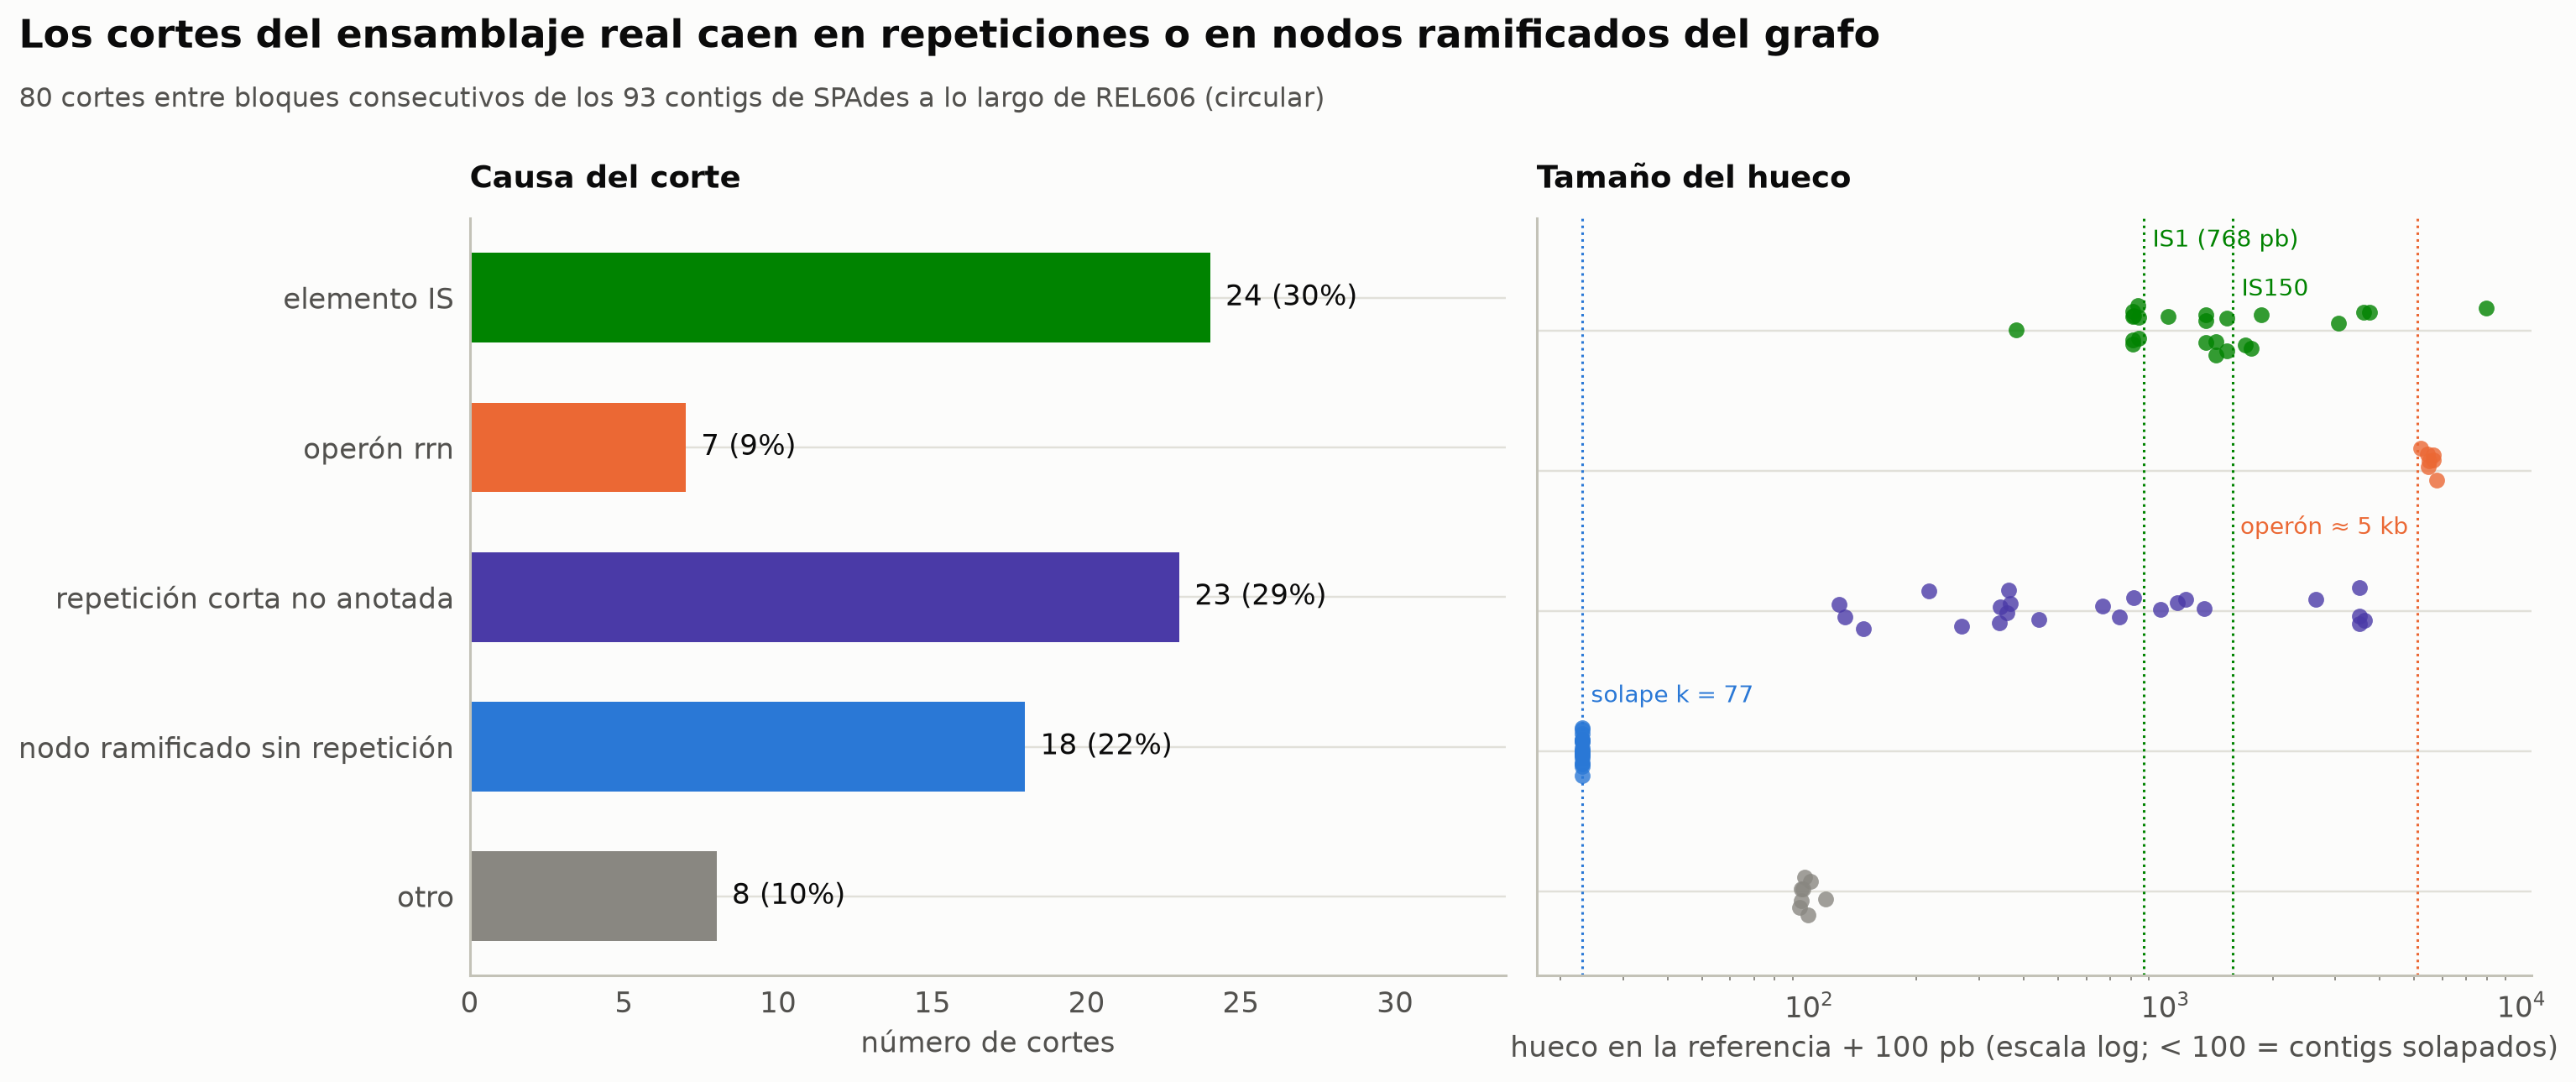

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw=dict(width_ratios=[1.25, 1.2]))
order_c = ["elemento IS", "operón rrn", "repetición corta no anotada", "nodo ramificado sin repetición", "otro"]
colors_c = {"elemento IS": ec.GREEN, "operón rrn": ec.ORANGE, "repetición corta no anotada": ec.VIOLET,
            "nodo ramificado sin repetición": ec.BLUE, "otro": ec.MUTED}
nc_ = len(order_c)
vc = gaps_df.causa_simple.value_counts().reindex(order_c).fillna(0).astype(int)
ax1.barh(range(nc_)[::-1], vc.values, color=[colors_c[c] for c in order_c], height=0.6)
for y_, v_ in zip(range(nc_)[::-1], vc.values):
    ax1.text(v_ + 0.5, y_, f"{v_} ({v_ / len(gaps_df):.0%})", va="center", fontsize=11)
ax1.set_yticks(range(nc_)[::-1], order_c); ax1.set_xlim(0, vc.max() * 1.4)
ax1.set_xlabel("número de cortes")
ax1.set_title("Causa del corte", loc="left", fontsize=12)
for j, c in enumerate(order_c):
    d = gaps_df[gaps_df.causa_simple == c]
    yy = (nc_ - 1 - j) + rng.uniform(-0.18, 0.18, len(d))
    ax2.scatter(np.clip(d.hueco + 100, 1, None), yy, color=colors_c[c], s=38, alpha=0.8, edgecolor="white")
ax2.set_xscale("log"); ax2.set_yticks(range(nc_), [""] * nc_)
for xv, lab, col, yl in ((768 + 100, "IS1 (768 pb)", ec.GREEN, nc_ - 0.4), (1443 + 100, "IS150", ec.GREEN, nc_ - 0.75),
                         (5000 + 100, "operón ≈ 5 kb", ec.ORANGE, nc_ - 2.45), (23, "solape k = 77", ec.BLUE, 1.35)):
    ax2.axvline(xv, color=col, ls=":", lw=1)
    ax2.text(xv / 1.06 if col == ec.ORANGE else xv * 1.06, yl, lab, color=col, fontsize=9,
             ha="right" if col == ec.ORANGE else "left")
ax2.set_xlabel("hueco en la referencia + 100 pb (escala log; < 100 = contigs solapados)")
ax2.set_ylim(-0.6, nc_ - 0.2)
ax2.set_title("Tamaño del hueco", loc="left", fontsize=12)
ec.fig_title(fig, "Los cortes del ensamblaje real caen en repeticiones o en nodos ramificados del grafo",
             f"{len(gaps_df)} cortes entre bloques consecutivos de los 93 contigs de SPAdes a lo largo de REL606 (circular)")
plt.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Los 80 cortes no caen al azar:
>
> * **Repeticiones anotadas (~40 %)**: elementos IS (sobre todo IS1 e IS150, las familias más abundantes de REL606) y
>   los siete operones *rrn*. El tamaño del hueco coincide con el de la repetición (768 pb para IS1, 1,4 kb para
>   IS150, ~5 kb para los operones): la repetición se ensambla **una vez**, como un *contig* aparte de cobertura alta,
>   y los *contigs* de copia única terminan justo en sus bordes.
> * **Repeticiones cortas no anotadas (~30 %)**: junto al corte hay 31-mers presentes varias veces en el genoma
>   (secuencias REP, genes duplicados, fragmentos de IS): basta una repetición algo más larga que $k = 77$ para
>   ramificar el grafo.
> * **Nodos ramificados sin repetición (~20 %)**: el entorno es único en REL606, y los dos *contigs* vecinos se solapan
>   **exactamente 77 pb**, la firma de un nodo compartido del grafo con $k = 77$. Alguna arista de baja cobertura
>   (errores sistemáticos, lecturas quiméricas, una variante presente en parte de las células) se ramificaba allí y
>   SPAdes prefirió no continuar. Sin las lecturas completas no podemos decir cuál; es un recordatorio de que un
>   ensamblador **conservador** corta ante cualquier duda.
> * **Otros (~10 %)**, entre ellos las dos inserciones nuevas de IS150 que descubrimos en la región (4 006 277 y
>   4 110 239): el mismo diagnóstico, ahora en el genoma completo.
>
> Esto explica también el 1,7 % del genoma "que falta" según QUAST: no son regiones que no se secuenciaron, sino
> sobre todo **copias** de repeticiones que el ensamblaje representa una sola vez.

### 🔍 Mapa interactivo de los *contigs* sobre el genoma

Cada barra es un bloque ≥ 1 kb de un *contig*, colocado en su posición de REL606 y coloreado por su cobertura
relativa. Las marcas naranjas son los operones *rrn* y las verdes, las transposasas de elementos IS. Acerque el zoom a
cualquier corte y pase el cursor por las barras.

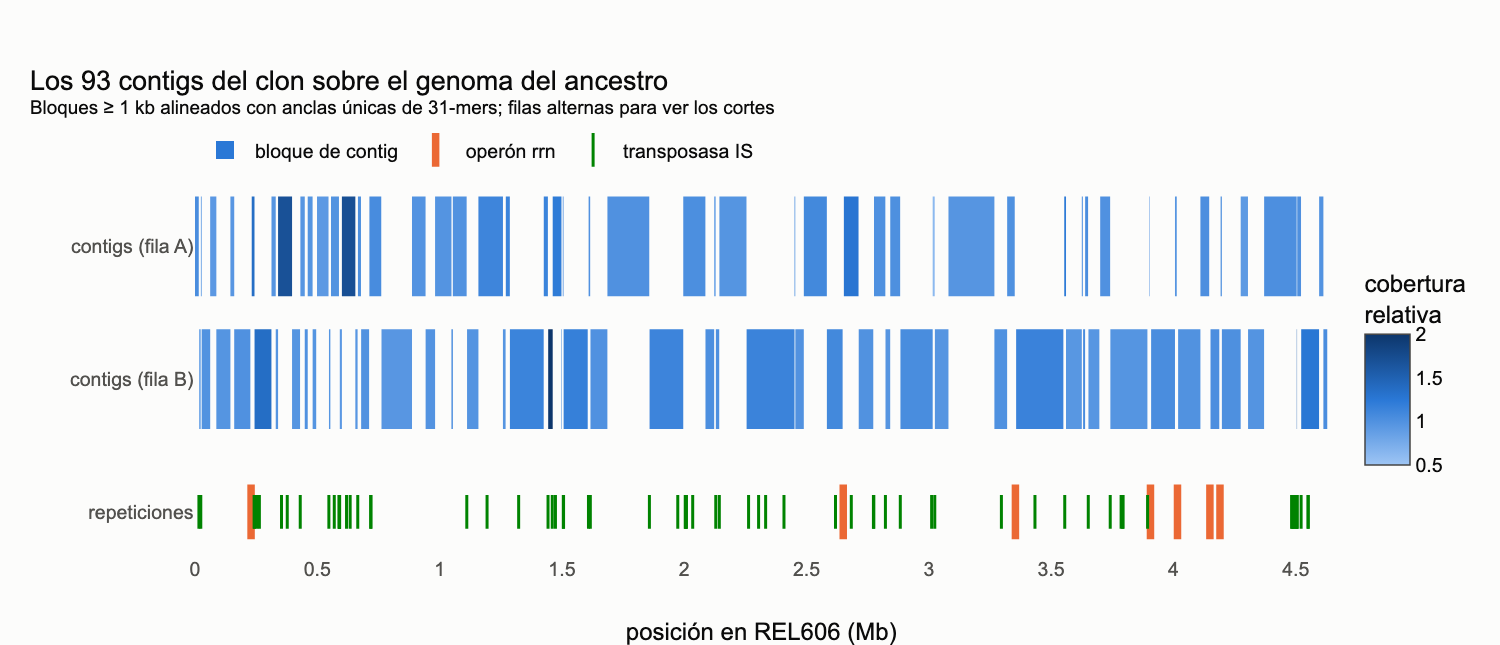

In [39]:
fb["tier"] = np.arange(len(fb)) % 2
fb["label"] = np.where(fb.tier == 0, "contigs (fila A)", "contigs (fila B)")
fig = go.Figure()
fig.add_trace(go.Bar(
    y=fb.label, x=(fb.r1 - fb.r0) / 1e6, base=fb.r0 / 1e6, orientation="h", name="bloque de contig",
    marker=dict(color=np.minimum(fb.rel_cov, 2), colorscale=[[0, "#9ec5f4"], [0.5, ec.BLUE], [1, "#0d366b"]],
                cmin=0.5, cmax=2, colorbar=dict(title="cobertura<br>relativa", len=0.6)),
    customdata=np.stack([fb.contig, fb.length, fb.rel_cov, fb.r0 + 1, fb.r1, fb.strand], axis=1),
    hovertemplate="<b>%{customdata[0]}</b> · %{customdata[1]:,} pb · cobertura %{customdata[2]:.2f}×"
                  "<br>REL606 %{customdata[3]:,}–%{customdata[4]:,} (hebra %{customdata[5]})<extra></extra>"))
fig.add_trace(go.Scatter(
    x=[(s_ + e_) / 2e6 for s_, e_ in operons_g], y=["repeticiones"] * len(operons_g), mode="markers", name="operón rrn",
    marker=dict(symbol="line-ns", size=26, line=dict(width=5, color=ec.ORANGE)),
    customdata=[f"{s_:,}–{e_:,}" for s_, e_ in operons_g],
    hovertemplate="<b>operón rrn</b> %{customdata}<br>~5 kb, 7 copias: el ensamblaje se corta aquí<extra></extra>"))
fig.add_trace(go.Scatter(
    x=(is_g.start + is_g.end) / 2e6, y=["repeticiones"] * len(is_g), mode="markers", name="transposasa IS",
    marker=dict(symbol="line-ns", size=16, line=dict(width=2, color=ec.GREEN)),
    customdata=np.stack([is_g["product"].str[:45], is_g.start], axis=1),
    hovertemplate="<b>%{customdata[0]}</b><br>posición %{customdata[1]:,}<extra></extra>"))
fig.update_xaxes(title="posición en REL606 (Mb)", range=[0, G_REL606 / 1e6])
fig.update_yaxes(categoryorder="array", categoryarray=["repeticiones", "contigs (fila B)", "contigs (fila A)"])
fig.update_layout(title="Los 93 contigs del clon sobre el genoma del ancestro"
                        "<br><sup>Bloques ≥ 1 kb alineados con anclas únicas de 31-mers; filas alternas para ver los cortes</sup>",
                  height=430, bargap=0.25, margin=dict(t=120, l=130, r=30, b=60),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> ✅ **Compruebe su comprensión.** Si secuenciara este clon con Nanopore (lecturas de ~15 kb) y ensamblara con Flye,
> ¿cuántos *contigs* esperaría? ¿Qué repetición sería la más difícil? *(Uno solo, circular, de ~4,6 Mb: todas las
> repeticiones del genoma —IS de 0,8–1,4 kb y operones de ~5 kb— son más cortas que una lectura típica. Las más
> difíciles serían las más largas, los operones rrn, pero incluso esos quedan atravesados por muchas lecturas.)*

## 11. Completitud y exactitud sin referencia: BUSCO y Merqury

Para la mayoría de los organismos **no existe** una referencia (¡por eso se ensamblan!). Dos familias de métodos
cubren ese hueco.

### Genes que no pueden faltar: la idea de BUSCO

Piense en revisar si un manual de instrucciones fotocopiado está completo sin tener el original: usted sabe que todo
manual tiene índice, advertencias de seguridad y garantía, **una vez cada una**. Si falta la garantía, falta algo; si
aparece dos veces, alguien fotocopió una hoja de más.

**BUSCO** (Simão *et al.*, 2015; Manni *et al.*, 2021) aplica esa lógica con genes: en cada linaje hay genes presentes
en casi todas las especies y casi siempre en **una sola copia** (*benchmarking universal single-copy orthologs*). El
conjunto `bacteria_odb10` tiene 124. Cada uno se busca en el ensamblaje (con perfiles HMM, no con la secuencia exacta)
y se clasifica como:

| Clase | Significado | Qué sugiere si abunda |
|---|---|---|
| **S** | completo, copia única | lo esperado |
| **D** | completo, duplicado | haplotipos separados sin querer, o contaminación con un organismo emparentado |
| **F** | fragmentado | *contigs* cortos o errores de consenso |
| **M** | ausente | ensamblaje incompleto |

Un buen ensamblaje bacteriano supera el 95 % de completos. BUSCO real necesita descargar la base de datos y tarda
varios minutos; aquí hacemos una **versión de juguete** con la misma lógica: tomamos las proteínas ribosómicas de
REL606 (genes universales y de copia única en bacterias) y buscamos sus 31-mers en los 93 *contigs*. Ojo con la
trampa: nosotros usamos la secuencia de la **misma cepa**, algo que en un organismo nuevo no tendríamos; BUSCO usa
perfiles construidos con cientos de especies.

In [40]:
t0 = time.perf_counter()
full_names = list(full_contigs)
idx_asm = build_index([full_contigs[n] for n in full_names])
rp = feat[(feat.type == "CDS") & feat["product"].str.match(r"^(30S|50S) ribosomal protein")].copy()
res = []
for g_, st_, s_, e_, pr_ in zip(rp.gene.fillna(rp.locus_tag), rp.strand, rp.start, rp.end, rp["product"]):
    gseq = genome[s_ - 1:e_]
    c, f, ok = kmer_codes(to_codes(gseq), K_ALN)
    c = c[0][ok[0]]
    i, cnt = lookup(idx_asm, c)
    found = cnt > 0
    hosts = Counter(idx_asm["ids"][i[found]])
    frac = found.mean()
    main_frac = max(hosts.values()) / len(c) if hosts else 0
    dup = np.median(cnt[found]) >= 2 if found.any() else False
    cls = ("M" if frac < 0.2 else "D" if (dup and frac >= 0.95) else
           "S" if main_frac >= 0.95 else "F")
    res.append(dict(gen=g_, producto=pr_, longitud=e_ - s_ + 1, kmers_hallados=round(frac, 3),
                    contigs=len(hosts), clase=cls))
busco_df = pd.DataFrame(res)
counts = busco_df.clase.value_counts().reindex(list("SDFM")).fillna(0).astype(int)
n_g = len(busco_df)
print(f"{n_g} proteínas ribosómicas · {time.perf_counter() - t0:.1f} s")
print(f"C: {(counts.S + counts.D) / n_g:.1%} [S: {counts.S / n_g:.1%}, D: {counts.D / n_g:.1%}], "
      f"F: {counts.F / n_g:.1%}, M: {counts.M / n_g:.1%}, n: {n_g}      ← el formato de resumen de BUSCO")
print("\nGenes que no son S:")
print(busco_df[busco_df.clase != "S"].to_string(index=False) if (busco_df.clase != "S").any() else "  ninguno")

60 proteínas ribosómicas · 1.0 s
C: 96.7% [S: 96.7%, D: 0.0%], F: 3.3%, M: 0.0%, n: 60      ← el formato de resumen de BUSCO

Genes que no son S:
 gen                  producto  longitud  kmers_hallados  contigs clase
rplS 50S ribosomal protein L19       348           0.903        1     F
rpsG  30S ribosomal protein S7       471           0.930        1     F


> 🔎 **Qué observamos.** Casi todas las proteínas ribosómicas aparecen completas y en una sola copia, como corresponde
> a un buen ensamblaje bacteriano. Si alguna sale "fragmentada" con un 90 % de sus 31-mers en un solo *contig*, hay
> dos explicaciones posibles: el *contig* termina dentro del gen (el defecto que BUSCO quiere detectar) o el clon tiene
> una mutación en él (cada SNP borra hasta 31 $k$-mers). Nuestra regla de juguete no distingue ambos casos; BUSCO, que
> compara proteínas con perfiles HMM de cientos de especies, tolera sin problema unas pocas diferencias.

### $k$-mers como testigos: la QV de Merqury

**Merqury** (Rhie *et al.*, 2020) compara los $k$-mers del ensamblaje con los de las **lecturas**. La idea: si el
ensamblaje tiene una base equivocada, los $k$ $k$-mers que la contienen **no aparecen en ninguna lectura** (las lecturas
tienen la base correcta). Sea $K_{\text{asm}}$ el número de $k$-mers del ensamblaje y $K_{\text{solo}}$ los que no
aparecen en las lecturas. Si los errores son independientes y afectan a una base con probabilidad $\varepsilon$, un
$k$-mer es correcto con probabilidad $(1-\varepsilon)^k$, así que

$$
(1-\varepsilon)^k \approx 1-\frac{K_{\text{solo}}}{K_{\text{asm}}}
\quad\Longrightarrow\quad
\widehat{\varepsilon} = 1-\left(1-\frac{K_{\text{solo}}}{K_{\text{asm}}}\right)^{1/k},
\qquad
\mathrm{QV} = -10\log_{10}\widehat{\varepsilon}.
\tag{ec. 08-qv}
$$

| Símbolo | Significado |
|---|---|
| $K_{\text{asm}}$ | número de $k$-mers del ensamblaje |
| $K_{\text{solo}}$ | $k$-mers del ensamblaje ausentes de las lecturas |
| $\widehat\varepsilon$ | tasa de error por base estimada del ensamblaje |
| QV | calidad de consenso en escala Phred (la misma de la Lección 6.2) |

**A mano (ejemplo del libro).** Con $k = 21$, un ensamblaje bacteriano de 5 millones de $k$-mers con 250 exclusivos:
$K_{\text{solo}}/K_{\text{asm}} = 5\times10^{-5}$; $\widehat\varepsilon = 1-(1-5\times10^{-5})^{1/21} \approx
5\times10^{-5}/21 = 2{,}4\times10^{-6}$ y QV $= -10\log_{10}(2{,}4\times10^{-6}) = 56$: un error cada ~420 000 bases.
Con 5 000 $k$-mers exclusivos, QV $= 43$.

In [41]:
def merqury_qv(k_solo, k_asm, k=21):
    """ec. 08-qv: tasa de error por base y QV a partir de los k-mers exclusivos del ensamblaje."""
    eps = 1 - (1 - k_solo / k_asm) ** (1 / k)
    return eps, -10 * np.log10(eps) if eps > 0 else np.inf

for ks in (250, 5000):
    eps, qv = merqury_qv(ks, 5_000_000)
    print(f"K_asm = 5,000,000 · K_solo = {ks:>5}: ε = {eps:.3e} · QV = {qv:.1f} · un error cada {1 / eps:,.0f} pb")

K_asm = 5,000,000 · K_solo =   250: ε = 2.381e-06 · QV = 56.2 · un error cada 419,990 pb
K_asm = 5,000,000 · K_solo =  5000: ε = 4.764e-05 · QV = 43.2 · un error cada 20,990 pb


Ahora con datos reales: los 21-mers del ensamblaje de la región contra los 21-mers de las 34 000 pares de lecturas
(los que contamos en la sección 2). Merqury mide además la **completitud**: la fracción de los $k$-mers "fiables" de
las lecturas (los que superan el valle del espectro, es decir, que no son errores de secuenciación) que aparecen en el
ensamblaje.

In [42]:
def asm_kmers(contigs, k=K_SPEC, min_len=500):
    cs = [kmer_codes(to_codes(s), k) for s in contigs.values() if len(s) >= min_len]
    return np.concatenate([c[0][ok[0]] for c, f, ok in cs])

qv_rows = []
asm_sets = {"precalculado": pre_contigs}
if live_contigs:
    asm_sets["en vivo"] = live_contigs
reliable = read_kmers[read_counts >= valley]
for lab, cset in asm_sets.items():
    ak = asm_kmers(cset)
    ak_u, ak_n = np.unique(ak, return_counts=True)
    i_ = np.minimum(np.searchsorted(read_kmers, ak_u), len(read_kmers) - 1)
    solo = read_kmers[i_] != ak_u
    k_solo, k_asm = int(ak_n[solo].sum()), len(ak)
    eps, qv = merqury_qv(max(k_solo, 1), k_asm)
    j_ = np.minimum(np.searchsorted(ak_u, reliable), len(ak_u) - 1)
    compl = np.mean(ak_u[j_] == reliable)
    qv_rows.append({"ensamblaje": lab, "K_asm": k_asm, "K_solo": k_solo, "ε": f"{eps:.2e}",
                    "QV": (f"{qv:.1f}" if k_solo else f"> {qv:.1f} (K_solo = 0)"),
                    "completitud k-mers": f"{compl:.2%}"})
    if lab == "precalculado":
        asm_copy_u, asm_copy_n = ak_u, ak_n
print(f"21-mers fiables de las lecturas (m ≥ {valley}): {len(reliable):,}")
print(pd.DataFrame(qv_rows).to_string(index=False))

21-mers fiables de las lecturas (m ≥ 8): 243,495
  ensamblaje  K_asm  K_solo        ε                  QV completitud k-mers
precalculado 243679       0 1.95e-07 > 67.1 (K_solo = 0)             98.89%
     en vivo 243982       0 1.95e-07 > 67.1 (K_solo = 0)             98.81%


> 🔎 **Qué observamos.** Casi ningún 21-mer del ensamblaje está ausente de las lecturas: la QV supera ampliamente 40
> (menos de un error cada 10 000 bases), en línea con los ~1 desajustes por 100 kb de QUAST. Hay una advertencia
> importante: el ensamblaje se construyó **con estas mismas lecturas**, así que la QV de Merqury mide la coherencia
> entre ensamblaje y datos, no la verdad absoluta. Un error sistemático de la secuenciación (repetido en todas las
> lecturas) pasaría inadvertido. Por eso Merqury recomienda contar los $k$-mers de una tecnología **independiente**
> (por ejemplo, lecturas Illumina para evaluar un ensamblaje de Nanopore).
>
> La completitud por $k$-mers no llega al 100 % por las mismas razones que ya conocemos: los $k$-mers "fiables" de las
> lecturas incluyen las secuencias **fuera** de la región que el reclutamiento trajo (bordes, otros operones *rrn*) y
> los $k$-mers que cruzan las variantes entre copias de las repeticiones colapsadas.

### El espectro coloreado por número de copias

La figura más característica de Merqury: el espectro de $k$-mers de las lecturas (Lección 8.1), coloreado según
**cuántas veces** aparece cada $k$-mer en el ensamblaje.

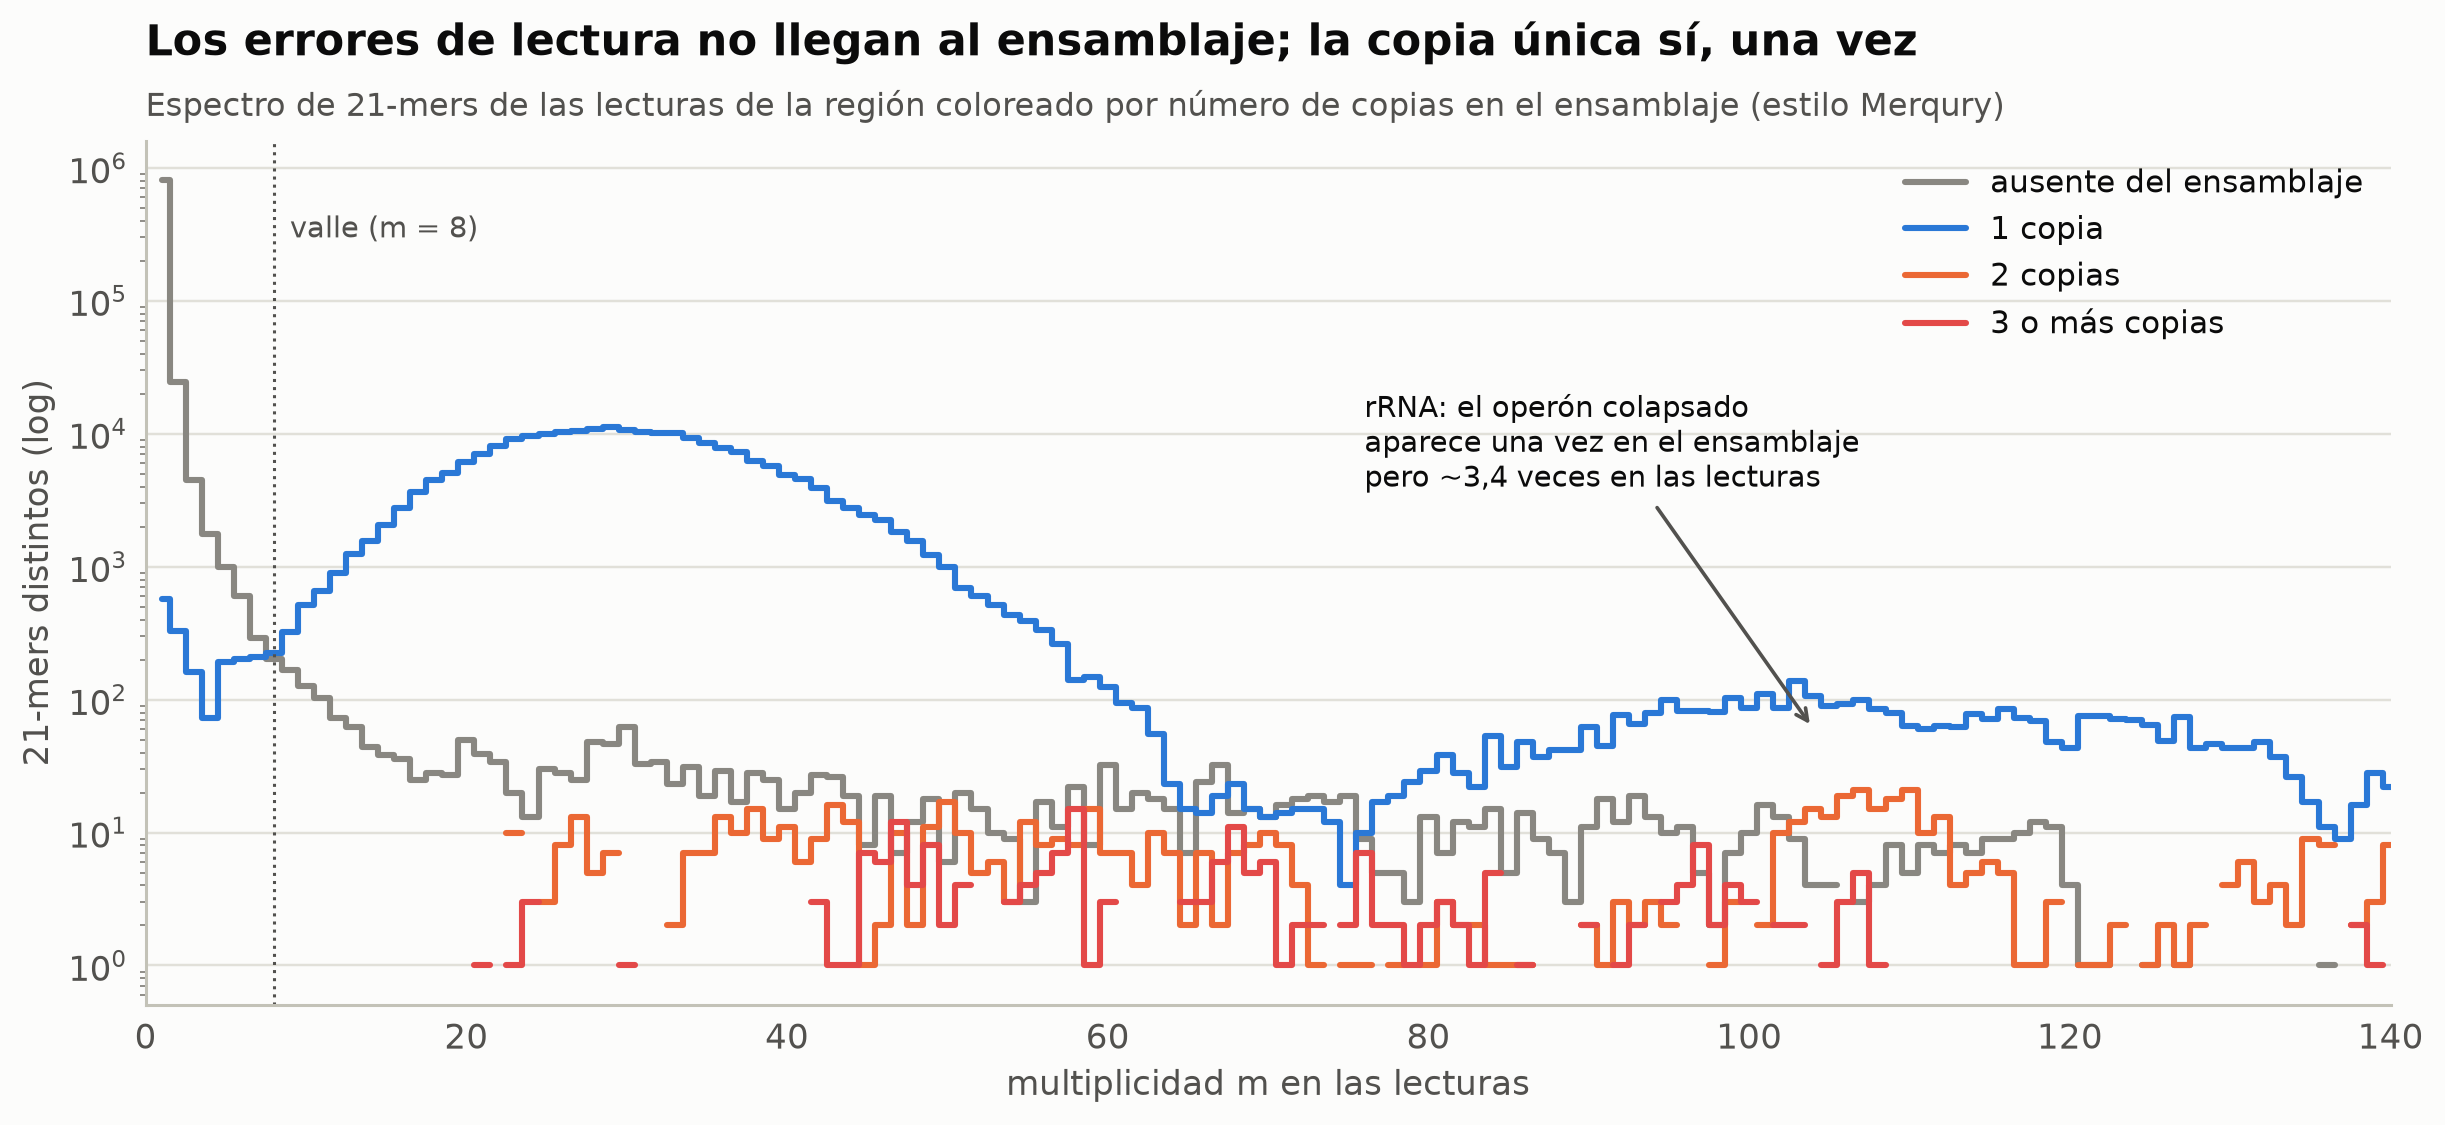

In [43]:
i_ = np.minimum(np.searchsorted(asm_copy_u, read_kmers), len(asm_copy_u) - 1)
copies = np.where(asm_copy_u[i_] == read_kmers, asm_copy_n[i_], 0)
fig, ax = plt.subplots(figsize=(11, 5))
m_max = 140
labels_cn = {0: ("ausente del ensamblaje", ec.MUTED), 1: ("1 copia", ec.BLUE), 2: ("2 copias", ec.ORANGE),
             3: ("3 o más copias", ec.RED)}
for cn, (lab, col) in labels_cn.items():
    sel = copies == cn if cn < 3 else copies >= 3
    h_ = np.bincount(read_counts[sel], minlength=m_max + 1)[1:m_max + 1]
    ax.step(np.arange(1, m_max + 1), np.where(h_ > 0, h_, np.nan), where="mid", color=col, lw=2, label=lab)
ax.set_yscale("log"); ax.set_xlim(0, m_max)
ax.axvline(valley, color=ec.INK_2, ls=":", lw=1)
ax.text(valley + 1, 3e5, f"valle (m = {valley})", fontsize=9.5, color=ec.INK_2)
ax.annotate("rRNA: el operón colapsado\naparece una vez en el ensamblaje\npero ~3,4 veces en las lecturas",
            (104, 60), xytext=(76, 4e3), fontsize=9.5, arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
ax.set_xlabel("multiplicidad m en las lecturas"); ax.set_ylabel("21-mers distintos (log)")
ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Los errores de lectura no llegan al ensamblaje; la copia única sí, una vez",
         "Espectro de 21-mers de las lecturas de la región coloreado por número de copias en el ensamblaje (estilo Merqury)")
plt.show()

> 🔎 **Qué observamos.** La montaña de errores ($m \le$ valle) es gris: **ninguno** de esos $k$-mers entró en el
> ensamblaje, como debe ser. El pico de copia única ($m \approx 30$) es azul: esos $k$-mers están una vez. Y la cola
> derecha de los operones *rrn* también es azul: aparecen **una** vez en el ensamblaje aunque las lecturas digan que
> hay varias copias. En un ensamblaje perfecto esa cola sería naranja o roja (dos, tres copias). Merqury nos está
> diciendo, sin ninguna referencia, lo mismo que QUAST y nuestro alineador: las repeticiones están **colapsadas**.

> 💡 **Idea clave.** Un ensamblaje se juzga en tres ejes: **contigüidad** (N50, NG50, auN), **exactitud** (errores de
> QUAST, NGA50, QV de Merqury) y **completitud** (fracción del genoma, BUSCO, $k$-mers). Mejorar uno a costa de otro
> es fácil; mejorar los tres a la vez es lo que distingue un buen ensamblaje.

## ✍️ Ejercicios

**Ejercicio 1 — N50 a mano.** Un ensamblaje tiene *contigs* de 500, 300, 300, 100, 50 y 50 kb, y el genoma estimado
mide 1 500 kb. Calcule a mano N50, L50, NG50, LG50, N90 y auN. Luego compruébelo con `nx` y `auN`. ¿Qué pasa con el
N50 si se descartan los *contigs* de 50 kb?

**Ejercicio 2 — Elegir $k$.** Con la ecuación de los $k$-mers ausentes, encuentre el mayor $k$ (impar) que mantiene la
fracción de $k$-mers ausentes por debajo del 1 % en una región a 8×, con lecturas de 150 pb y $e = 0{,}5\,\%$. ¿Y si las
lecturas midieran 250 pb?

**Ejercicio 3 — QV objetivo.** Un ensamblaje bacteriano tiene $K_{\text{asm}} = 4{,}5$ millones de 21-mers. ¿Cuántos
$k$-mers exclusivos puede tener como máximo para alcanzar QV 40? ¿Y QV 50?

**Ejercicio 4 — Umbrales y NG50 real.** Con los 93 *contigs* del clon completo (`full_len`), calcule N50 y NG50
($G$ = 4 629 812) con umbrales de 500, 5 000 y 50 000 pb. ¿Cuál de las dos métricas es estable?

**Ejercicio 5 — Otra unión.** Aplique `junction_reads` al final del bloque de N6 (posición de la región 63 666), un
corte junto a un operón *rrn*. ¿Qué continúan las lecturas? ¿Por qué aquí no aparece un inserto nuevo?

In [44]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
ej = [500, 300, 300, 100, 50, 50]
print("A =", sum(ej), "· mitad = 650 → 500 + 300 = 800 ≥ 650 → N50 = 300, L50 = 2")
print("G/2 = 750 → 500 + 300 = 800 ≥ 750 → NG50 = 300, LG50 = 2")
print("90 % de A = 1170 → 500+300+300+100 = 1200 → N90 = 100")
print("auN = (500² + 2·300² + 100² + 2·50²)/1300 =", round(auN(ej), 1))
print("Comprobación:", nx(ej), nx(ej, G=1500), nx(ej, 90))
print("Sin los de 50 kb:", nx([l for l in ej if l > 50]), "(A = 1200, mitad 600 → sigue 300, pero L50 igual)")

A = 1300 · mitad = 650 → 500 + 300 = 800 ≥ 650 → N50 = 300, L50 = 2
G/2 = 750 → 500 + 300 = 800 ≥ 750 → NG50 = 300, LG50 = 2
90 % de A = 1170 → 500+300+300+100 = 1200 → N90 = 100
auN = (500² + 2·300² + 100² + 2·50²)/1300 = 342.3
Comprobación: (300, 2) (300, 2) (100, 4)
Sin los de 50 kb: (300, 2) (A = 1200, mitad 600 → sigue 300, pero L50 igual)


In [45]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for Lr in (150, 250):
    ks_ = np.arange(15, Lr, 2)
    ok_k = ks_[frac_missing(8, ks_, L=Lr) < 0.01]
    print(f"L = {Lr}: mayor k con < 1 % de k-mers ausentes a 8× = {ok_k.max()} "
          f"(ausentes = {frac_missing(8, ok_k.max(), L=Lr):.3%})")
print("Lecturas más largas permiten k mayores: por eso SPAdes añade k = 99 y 127 con lecturas de 250 pb.")

L = 150: mayor k con < 1 % de k-mers ausentes a 8× = 43 (ausentes = 0.963%)
L = 250: mayor k con < 1 % de k-mers ausentes a 8× = 57 (ausentes = 0.942%)
Lecturas más largas permiten k mayores: por eso SPAdes añade k = 99 y 127 con lecturas de 250 pb.


In [46]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
K_asm_ = 4_500_000
for qv_ in (40, 50):
    eps_ = 10 ** (-qv_ / 10)
    k_solo_ = K_asm_ * (1 - (1 - eps_) ** 21)
    print(f"QV {qv_}: ε = {eps_:.0e} → K_solo ≤ {k_solo_:,.0f}  (≈ K_asm·k·ε = {K_asm_ * 21 * eps_:,.0f})")

QV 40: ε = 1e-04 → K_solo ≤ 9,441  (≈ K_asm·k·ε = 9,450)
QV 50: ε = 1e-05 → K_solo ≤ 945  (≈ K_asm·k·ε = 945)


In [47]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for thr in (500, 5_000, 50_000):
    ls_ = full_len[full_len >= thr]
    print(f"≥ {thr:>6,} pb: {len(ls_):3d} contigs · N50 = {nx(ls_)[0]:>7,} · NG50 = {nx(ls_, G=G_REL606)[0] or 'no definido'}")
print("El N50 sube al tirar contigs; el NG50 se mantiene hasta que deja de estar definido.")

≥    500 pb:  93 contigs · N50 =  98,594 · NG50 = 98594
≥  5,000 pb:  74 contigs · N50 =  98,594 · NG50 = 98594
≥ 50,000 pb:  32 contigs · N50 = 126,170 · NG50 = 98594
El N50 sube al tirar contigs; el NG50 se mantiene hasta que deja de estar definido.


In [48]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
after_ = junction_reads(63666)
print("referencia:", region[63666:63706])
for s_, n_ in after_.most_common(3):
    print(f"{n_:3d} lecturas: {s_}", "= referencia" if s_ == region[63666:63706] else "")
print("Las lecturas siguen como la referencia: el genoma está intacto. SPAdes corta aquí porque empieza el operón rrn,")
print("una repetición de ~5 kb que el grafo colapsa; no hay nada nuevo que descubrir en este corte.")

referencia: CTCCGGCAGAGAAAGCAAAAATAAATGCTTGACTCTGTAG
 27 lecturas: CTCCGGCAGAGAAAGCAAAAATAAATGCTTGACTCTGTAG = referencia
  5 lecturas: TTCCGGCAGAGAAAGCAAAAATAAATGCTTGACTCTGTAG 
  1 lecturas: CCTGTCTCTTATACACATCTGACGCTGCCGACGAAGAGGA 
Las lecturas siguen como la referencia: el genoma está intacto. SPAdes corta aquí porque empieza el operón rrn,
una repetición de ~5 kb que el grafo colapsa; no hay nada nuevo que descubrir en este corte.


## 📌 Resumen

* **Un solo $k$ no basta:** la fracción de $k$-mers del genoma ausentes es $e^{-\lambda_k}$ con
  $\lambda_k = c\,\frac{L-k+1}{L}(1-e)^k$; un $k$ grande resuelve repeticiones pero fragmenta las regiones poco
  cubiertas. Lo comprobamos con lecturas reales submuestreadas.
* **SPAdes** construye grafos con varios $k$, reinyectando los *contigs* de cada paso; simplifica puntas, burbujas y
  quimeras, y usa los pares para resolver repeticiones. La cobertura en el nombre de cada *contig* delata repeticiones
  colapsadas (rRNA a ~3,5×) y artefactos (0,05×). En SPAdes 4, `--isolate` no corrige errores por defecto.
* **N50/L50/NG50/auN** miden tamaño, no verdad: un error de ensamblaje llevó el N50 del ejemplo de 250 a 570 kb, y
  tirar *contigs* cortos lo infla. Prefiera el NG50 y las curvas N$x$ completas; el auN es el área bajo la curva.
* **Andamiaje:** $\widehat g = \mu - a - b$. Con una biblioteca Nextera ($\sigma \approx 300$ pb) cada par es ruidoso,
  la media simple subestima el hueco y nada mayor que ~1 kb puede saltarse.
* **QUAST** mide exactitud contra una referencia: 0 errores de ensamblaje, < 1 desajuste por 100 kb en la región.
  Nuestro alineador de 31-mers reprodujo sus cifras. Los "no alineados" eran bordes de la región, un artefacto de
  reclutamiento y, sobre todo, **dos inserciones nuevas de IS150** del clon (en *fadA* y *metL*) que el ancestro no
  tiene: la referencia condiciona lo que QUAST llama error.
* En el **genoma completo** (93 *contigs*, N50 ≈ 99 kb, 98,3 % del genoma), la mayoría de los cortes caen en
  repeticiones (elementos IS, operones *rrn*, repeticiones cortas no anotadas) y el resto en nodos ramificados del
  grafo: las repeticiones más largas que $k-1$ y que el inserto rompen los ensamblajes de lecturas cortas.
* **Sin referencia:** BUSCO busca genes universales de copia única (S/D/F/M) y Merqury estima la QV con
  $\widehat\varepsilon = 1-(1-K_{\text{solo}}/K_{\text{asm}})^{1/k}$ y dibuja el espectro por número de copias, que
  delata las repeticiones colapsadas.

## 📚 Para profundizar

* Bankevich, A., Nurk, S., Antipov, D., Gurevich, A. A., Dvorkin, M., Kulikov, A. S., *et al.* (2012). SPAdes: a new
  genome assembly algorithm and its applications to single-cell sequencing. *Journal of Computational Biology* 19(5):
  455–477.
* Prjibelski, A., Antipov, D., Meleshko, D., Lapidus, A. & Korobeynikov, A. (2020). Using SPAdes de novo assembler.
  *Current Protocols in Bioinformatics* 70(1): e102.
* Gurevich, A., Saveliev, V., Vyahhi, N. & Tesler, G. (2013). QUAST: quality assessment tool for genome assemblies.
  *Bioinformatics* 29(8): 1072–1075.
* Mikheenko, A., Prjibelski, A., Saveliev, V., Antipov, D. & Gurevich, A. (2018). Versatile genome assembly evaluation
  with QUAST-LG. *Bioinformatics* 34(13): i142–i150.
* Simão, F. A., Waterhouse, R. M., Ioannidis, P., Kriventseva, E. V. & Zdobnov, E. M. (2015). BUSCO: assessing genome
  assembly and annotation completeness with single-copy orthologs. *Bioinformatics* 31(19): 3210–3212.
* Manni, M., Berkeley, M. R., Seppey, M., Simão, F. A. & Zdobnov, E. M. (2021). BUSCO update: novel and streamlined
  workflows along with broader and deeper phylogenetic coverage for scoring of eukaryotic, prokaryotic, and viral
  genomes. *Molecular Biology and Evolution* 38(10): 4647–4654.
* Rhie, A., Walenz, B. P., Koren, S. & Phillippy, A. M. (2020). Merqury: reference-free quality, completeness, and
  phasing assessment for genome assemblies. *Genome Biology* 21: 245.
* Koren, S., Walenz, B. P., Berlin, K., Miller, J. R., Bergman, N. H. & Phillippy, A. M. (2017). Canu: scalable and
  accurate long-read assembly via adaptive k-mer weighting and repeat separation. *Genome Research* 27(5): 722–736.
* Kolmogorov, M., Yuan, J., Lin, Y. & Pevzner, P. A. (2019). Assembly of long, error-prone reads using repeat graphs.
  *Nature Biotechnology* 37(5): 540–546.
* Cheng, H., Concepcion, G. T., Feng, X., Zhang, H. & Li, H. (2021). Haplotype-resolved de novo assembly using phased
  assembly graphs with hifiasm. *Nature Methods* 18(2): 170–175.
* Nurk, S., Koren, S., Rhie, A., Rautiainen, M., Bzikadze, A. V., Mikheenko, A., *et al.* (2022). The complete sequence
  of a human genome. *Science* 376(6588): 44–53.
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*
  536(7615): 165–170. (Origen de las lecturas SRR2584863.)
* Documentación: manual de SPAdes (https://ablab.github.io/spades/) y de QUAST (https://quast.sourceforge.net/docs/manual.html).

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)